In [6]:
import os
import matplotlib
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import pandas as pd
import importlib

from src import eda_process as eda


In [8]:
importlib.reload(eda)

<module 'src.eda_process' from 'c:\\Users\\ASUS\\Desktop\\proyecto_usfq\\Proyecto_usfq\\src\\eda_process.py'>

In [3]:
base_final = pd.read_excel(
    "../data_processed/base_final.xlsx"
)

In [4]:
base_final = base_final.copy()

In [5]:
base_final

,MES,AÑO,ENTIDAD,( PATRIMONIO + RESULTADOS ) / ACTIVOS INMOVILIZADOS NETOS (3) (6),INDICE DE CAPITALIZACION NETO: FK / FI,ACTIVOS IMPRODUCTIVOS NETOS / TOTAL ACTIVOS,ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS,ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO,MOROSIDAD DE LA CARTERA DE CREDITOS CONSUMO,MOROSIDAD DE LA CARTERA DE CRÉDITOS INMOBILIARIO,...,CARTERA QUE NO DEVENGA INTERESES / CARTERA BRUTA,CARTERA REFINANCIADA / CARTERA BRUTA,CARTERA REESTRUCTURADA / CARTERA BRUTA,VAR_FONDOS DISPONIBLES,VAR_INVERSIONES,VAR_CARTERA DE CRÉDITOS,VAR_TOTAL ACTIVO,VAR_Depósitos a la vista,VAR_Depósitos a plazo,VAR_TOTAL PATRIMONIO
0,Mayo,2022,BP GUAYAQUIL,410.634510,8.120787,13.346535,86.653465,120.426351,1.549652,1.820555,...,0.704908,1.710131,0.527229,-15.357506,-3.105869,21.963595,10.850009,14.419397,16.334925,8.087612
1,Mayo,2022,BP PACIFICO,276.006994,9.549144,21.715553,78.284447,111.274525,3.261802,4.401917,...,1.798705,9.543764,4.166759,-16.102362,15.214273,-0.671445,-0.215742,-3.749551,7.616585,2.003489
2,Mayo,2022,BP PICHINCHA,-1288.206946,8.728095,8.727610,91.272390,142.387866,2.101977,4.277935,...,1.743190,2.169764,4.722154,-34.596167,0.889363,34.189556,10.684144,9.095698,17.660489,4.376836
3,Mayo,2022,BP PRODUBANCO,345.788698,7.046035,11.941164,88.058836,146.171009,2.909608,2.891999,...,1.062750,0.607335,2.484534,-4.501507,-3.521776,24.150188,13.806515,9.297570,11.956282,7.797315
4,Mayo,2022,BP AUSTRO,129.543127,7.715342,16.033362,83.966638,104.258095,7.746817,1.672858,...,2.521220,7.008823,2.783564,-15.937829,6.911905,21.409839,11.400689,7.823076,4.820617,12.813348
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1202,Julio,2026,BP CAPITAL,74.360823,8.877858,20.311775,79.688225,97.499072,3.526914,0.000000,...,4.118464,1.431514,0.247529,-1.764260,54.532954,43.405379,32.243631,4.628479,44.564605,4.072887
1203,Julio,2026,BP DELBANK,743.520441,28.876492,15.797866,84.202134,176.981056,10.591267,0.000152,...,2.017141,6.891239,0.384947,9.622450,-37.925514,-11.897364,-10.244491,-12.542475,-22.706797,5.183978
1204,Julio,2026,BP D-MIRO S.A./BANCO ATLÁNTIDA S.A.,78.836924,5.519091,12.819096,87.180904,96.598989,0.035790,0.000000,...,1.235770,2.883851,0.751003,139.889649,50.905153,78.103791,71.293760,27.512148,109.688042,-5.648516
1205,Julio,2026,"BP BANCO DESARROLLO DE LOS PUEBLOS S.A., COD...",299.062134,10.365757,10.524893,89.475107,106.919132,7.961921,0.608309,...,5.890426,4.113364,0.662222,-58.597055,24.865624,3.694559,-5.187257,-13.838419,8.657541,6.703112


In [9]:
columnas_numericas = eda.obtener_columnas_numericas(base_final)

print("Cantidad de variables:", len(columnas_numericas))

Cantidad de variables: 31


In [10]:
def estadistica_descriptiva(df, columnas=None):

    if columnas is None:
        columnas = eda.obtener_columnas_numericas(df)

    estadisticas = df[columnas].describe().T

    return estadisticas

In [11]:
estadisticas = estadistica_descriptiva(base_final)

estadisticas

,count,mean,std,min,25%,50%,75%,max
( PATRIMONIO + RESULTADOS ) / ACTIVOS INMOVILIZADOS NETOS (3) (6),1207.0,1.658899e+03,5.089832e+04,-1.123052e+05,88.612576,263.732414,560.701261,1.760600e+06
INDICE DE CAPITALIZACION NETO: FK / FI,1207.0,1.156563e+01,5.666945e+00,1.187201e+00,8.002036,9.214697,14.264147,3.419627e+01
ACTIVOS IMPRODUCTIVOS NETOS / TOTAL ACTIVOS,1207.0,1.295588e+01,6.748879e+00,-2.645011e-01,8.568459,11.566513,15.811653,4.168214e+01
ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS,1207.0,8.704412e+01,6.748879e+00,5.831786e+01,84.188347,88.433487,91.431541,1.002645e+02
ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO,1207.0,1.453209e+02,1.548467e+02,7.577065e+01,105.953463,114.007009,130.657443,2.350921e+03
MOROSIDAD DE LA CARTERA DE CREDITOS CONSUMO,1207.0,4.991896e+00,3.925119e+00,0.000000e+00,2.855020,4.616980,6.293520,4.307627e+01
MOROSIDAD DE LA CARTERA DE CRÉDITOS INMOBILIARIO,1207.0,6.660967e+00,2.074016e+01,0.000000e+00,0.000000,1.471075,2.841429,1.000000e+02
MOROSIDAD DE LA CARTERA DE CRÉDITOS MICROCRÉDITO,1207.0,8.963708e+00,1.256036e+01,0.000000e+00,2.444629,5.273033,11.296066,1.000000e+02
MOROSIDAD DE LA CARTERA TOTAL,1207.0,4.705642e+00,4.699040e+00,2.700000e-07,2.355656,3.455657,5.440044,3.130732e+01
COBERTURA DE LA CARTERA REFINANCIADA,1207.0,1.041595e+02,1.290943e+02,0.000000e+00,58.529918,81.595116,105.919855,1.465732e+03


In [12]:
base_final.rename(
    columns={"( PATRIMONIO + RESULTADOS ) / ACTIVOS INMOVILIZADOS NETOS (3) (6)":"SUFICIENCIA PATRIMONIAL"}, inplace=True)

## Interpretación de indicadores financieros y sus límites regulatorios

## Indicadores Financieros



La siguiente tabla presenta el significado, las principales referencias de interpretación y la dirección deseable de los indicadores financieros utilizados en el análisis. Es importante distinguir entre los límites establecidos por la normativa y las referencias financieras o matemáticas. Cuando no existe un límite regulatorio general, se utiliza la dirección deseable del indicador para facilitar su interpretación durante el EDA.

| Variable | Significado | Límite / referencia | Interpretación | Dirección deseable |
|:---|:---|:---|:---|:---|
| **Suficiencia patrimonial** | Mide la capacidad del patrimonio técnico para respaldar los activos y contingentes ponderados por riesgo y absorber pérdidas. | **≥ 9%** | Valores inferiores al 9% representan un incumplimiento del mínimo regulatorio. | **Mayor es mejor** |
| **Índice de capitalización neto** | Mide la relación del patrimonio frente al total de activos y contingentes, reflejando el nivel de capitalización de la entidad. | **Referencia: ≥ 4%** para la relación de patrimonio técnico frente a activos totales y contingentes. | Un mayor nivel de capitalización implica una mayor capacidad para absorber pérdidas. | **Mayor es mejor** |
| **Activos improductivos netos / Total activos** | Mide qué proporción de los activos no genera rendimientos, neta de provisiones. | Sin límite regulatorio general identificado. | Una proporción elevada representa una mayor cantidad de recursos comprometidos en activos que no generan rentabilidad. | **Menor es mejor** |
| **Activos productivos / Total activos** | Mide la proporción de los activos de la entidad que genera ingresos o rendimiento. | **Rango matemático: 0--100%**. | Una mayor proporción indica una mayor utilización productiva de los activos. | **Mayor es mejor** |
| **Activos productivos / Pasivos con costo** | Mide la capacidad de los activos productivos para cubrir los pasivos que generan costo financiero. | **100% = cobertura 1 a 1**. Puede superar el 100%. | Valores superiores al 100% indican que los activos productivos superan a los pasivos con costo. | **Mayor es mejor** |
| **Morosidad de la cartera total** | Mide el porcentaje de la cartera que presenta problemas de pago respecto de la cartera bruta. | **0%** es el mínimo matemático. Sin máximo regulatorio general identificado. | Una menor tasa de morosidad indica una mejor calidad de la cartera. | **Menor es mejor** |
| **Morosidad de la cartera de consumo** | Mide el porcentaje de la cartera de consumo que se encuentra en situación de morosidad. | **0%** es el mínimo matemático. Sin máximo regulatorio general identificado. | Una menor tasa indica un menor deterioro de la cartera de consumo. | **Menor es mejor** |
| **Morosidad de la cartera de microcrédito** | Mide el porcentaje de la cartera de microcrédito que presenta morosidad. | **0%** es el mínimo matemático. Sin máximo regulatorio general identificado. | Una menor tasa indica una mejor calidad de la cartera de microcrédito. | **Menor es mejor** |
| **Morosidad de la cartera inmobiliaria** | Mide el porcentaje de la cartera inmobiliaria que presenta morosidad. | **0%** es el mínimo matemático. Sin máximo regulatorio general identificado. | Una menor tasa representa un menor deterioro de la cartera inmobiliaria. | **Menor es mejor** |
| **Cobertura de la cartera problemática** | Mide cuánto de la cartera problemática se encuentra respaldado por provisiones. | **100% = cobertura completa**. Puede superar el 100%. | Valores superiores al 100% indican que las provisiones superan la cartera problemática. | **Mayor es mejor** |
| **Cobertura de la cartera refinanciada** | Mide el nivel de provisiones respecto de la cartera refinanciada. | **100% = cobertura completa**. | Una mayor cobertura implica un mayor respaldo mediante provisiones. | **Mayor es mejor** |
| **Cobertura de la cartera reestructurada** | Mide el nivel de provisiones respecto de la cartera reestructurada. | **100% = cobertura completa**. Puede superar el 100%. | Una mayor cobertura representa una mayor protección frente al riesgo de esta cartera. | **Mayor es mejor** |
| **Gastos de operación estimados / Total activo promedio** | Mide el peso de los gastos operativos respecto de los activos promedio. | Sin límite regulatorio general identificado. | Un porcentaje elevado indica un mayor consumo de recursos para la operación de la entidad. | **Menor es mejor** |
| **Gastos de operación / Margen financiero** | Mide cuánto del margen financiero es absorbido por los gastos de operación. | **100% = los gastos absorben todo el margen financiero**. | Valores superiores al 100% indican que los gastos operativos superan al margen financiero. | **Menor es mejor** |
| **Gastos de personal estimados / Activo promedio** | Mide el peso de los gastos de personal respecto de los activos promedio. | Sin límite regulatorio general identificado. | Un porcentaje elevado indica un mayor peso relativo de los gastos de personal. | **Menor es mejor** |
| **ROE (Resultados del ejercicio / Patrimonio promedio)** | Mide la rentabilidad obtenida sobre el patrimonio promedio. | Sin máximo regulatorio general identificado. **0% = ausencia de rentabilidad; <0% = pérdida.** | Un ROE positivo indica generación de rentabilidad sobre el patrimonio. | **Mayor es mejor** |
| **ROA (Resultados del ejercicio / Activo promedio)** | Mide la rentabilidad obtenida sobre el activo promedio. | Sin máximo regulatorio general identificado. **0% = ausencia de rentabilidad; <0% = pérdida.** | Un ROA positivo indica capacidad de generar resultados a partir de los activos. | **Mayor es mejor** |
| **Cartera bruta / (Depósitos a la vista + Depósitos a plazo)** | Mide la relación entre la cartera de crédito y los depósitos considerados como fuente de fondeo. | **100% = cartera equivalente a los depósitos considerados**. No constituye un máximo regulatorio general. | Valores elevados indican mayor intermediación crediticia, aunque niveles excesivos deben analizarse conjuntamente con la liquidez. | **Mayor es generalmente mejor** |
| **Fondos disponibles / Total depósitos a corto plazo** | Mide la capacidad de cubrir los depósitos de corto plazo mediante fondos disponibles. | **100% = fondos disponibles equivalentes a los depósitos de corto plazo**. No constituye un máximo regulatorio general. | Un mayor porcentaje representa un mayor colchón de liquidez inmediata, aunque niveles excesivamente altos pueden reflejar recursos poco utilizados. | **Mayor generalmente es mejor** |

### Indicadores donde valores más altos representan un mejor desempeño

In [13]:
indicadores_mayor=['SUFICIENCIA PATRIMONIAL',
                   'INDICE DE CAPITALIZACION NETO: FK / FI',
                    'ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS',
                    'ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO',
                    'COBERTURA DE LA CARTERA REFINANCIADA',
                    'COBERTURA DE LA CARTERA REESTRUCTURADA',
                    'COBERTURA DE LA CARTERA PROBLEMÁTICA',
                    'RESULTADOS DEL EJERCICIO / PATRIMONIO PROMEDIO',
                    'RESULTADOS DEL EJERCICIO / ACTIVO PROMEDIO',
                    'CARTERA BRUTA / (DEPOSITOS A LA VISTA + DEPOSITOS A PLAZO)',
                    'FONDOS DISPONIBLES / TOTAL DEPOSITOS A CORTO PLAZO']

In [14]:
indicadores_notebook = [
    # Solvencia
    'SUFICIENCIA PATRIMONIAL',
    # Calidad de activos
    'INDICE DE CAPITALIZACION NETO: FK / FI',
    # Cobertura
    'COBERTURA DE LA CARTERA PROBLEMÁTICA',
    # Rentabilidad
    'RESULTADOS DEL EJERCICIO / PATRIMONIO PROMEDIO',
    # Liquidez
    'FONDOS DISPONIBLES / TOTAL DEPOSITOS A CORTO PLAZO'
]

In [15]:
# Diccionario de meses
meses = {
    "enero": 1,
    "febrero": 2,
    "marzo": 3,
    "abril": 4,
    "mayo": 5,
    "junio": 6,
    "julio": 7,
    "agosto": 8,
    "septiembre": 9,
    "octubre": 10,
    "noviembre": 11,
    "diciembre": 12
}

# Crear número de mes
base_final["MES_NUM"] = base_final["MES"].str.lower().map(meses)

# Crear fecha
base_final["FECHA"] = pd.to_datetime(
    base_final["AÑO"].astype(str) + "-" +
    base_final["MES_NUM"].astype(str) + "-01"
)

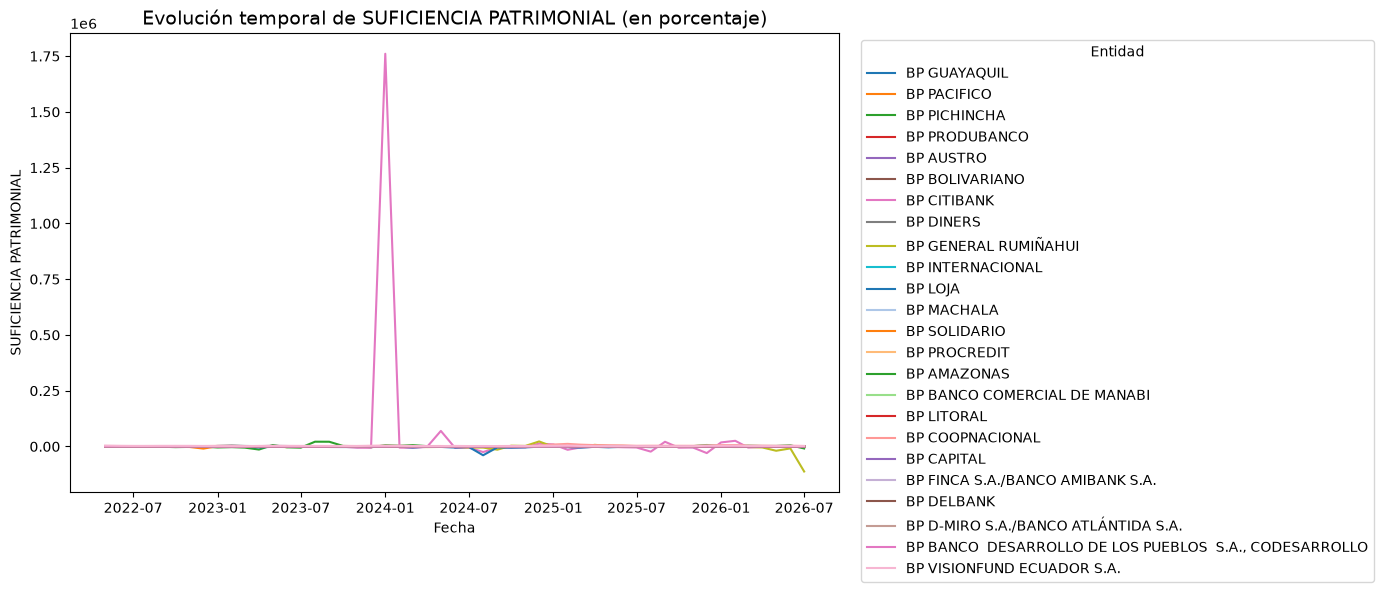

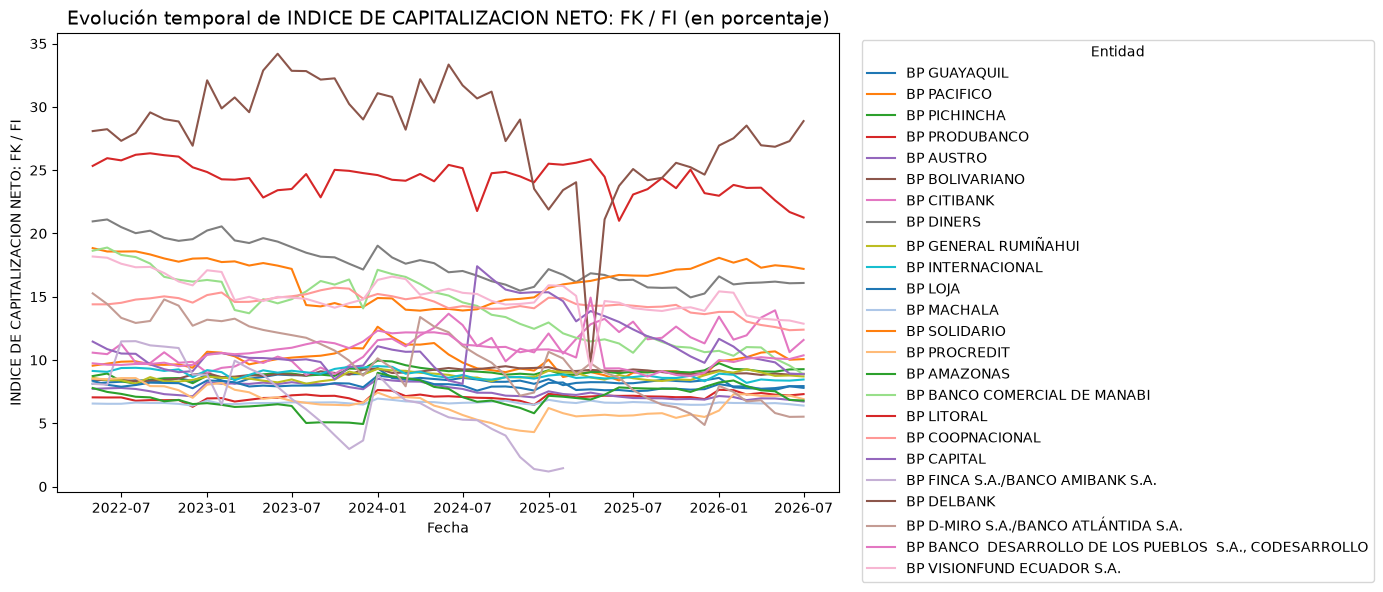

Guardado: graficas_EDA_indicadores_financieros\ACTIVOS_PRODUCTIVOS__TOTAL_ACTIVOS.png
Guardado: graficas_EDA_indicadores_financieros\ACTIVOS_PRODUCTIVOS__PASIVOS_CON_COSTO.png
Guardado: graficas_EDA_indicadores_financieros\COBERTURA_DE_LA_CARTERA_REFINANCIADA.png
Guardado: graficas_EDA_indicadores_financieros\COBERTURA_DE_LA_CARTERA_REESTRUCTURADA.png


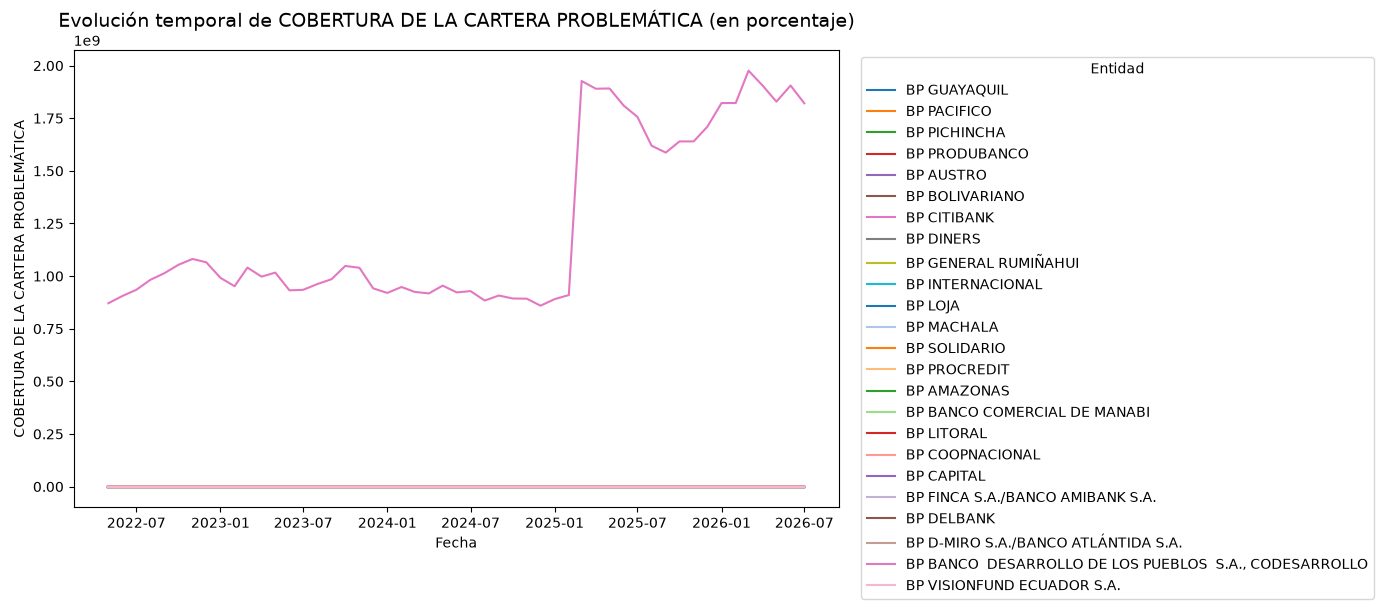

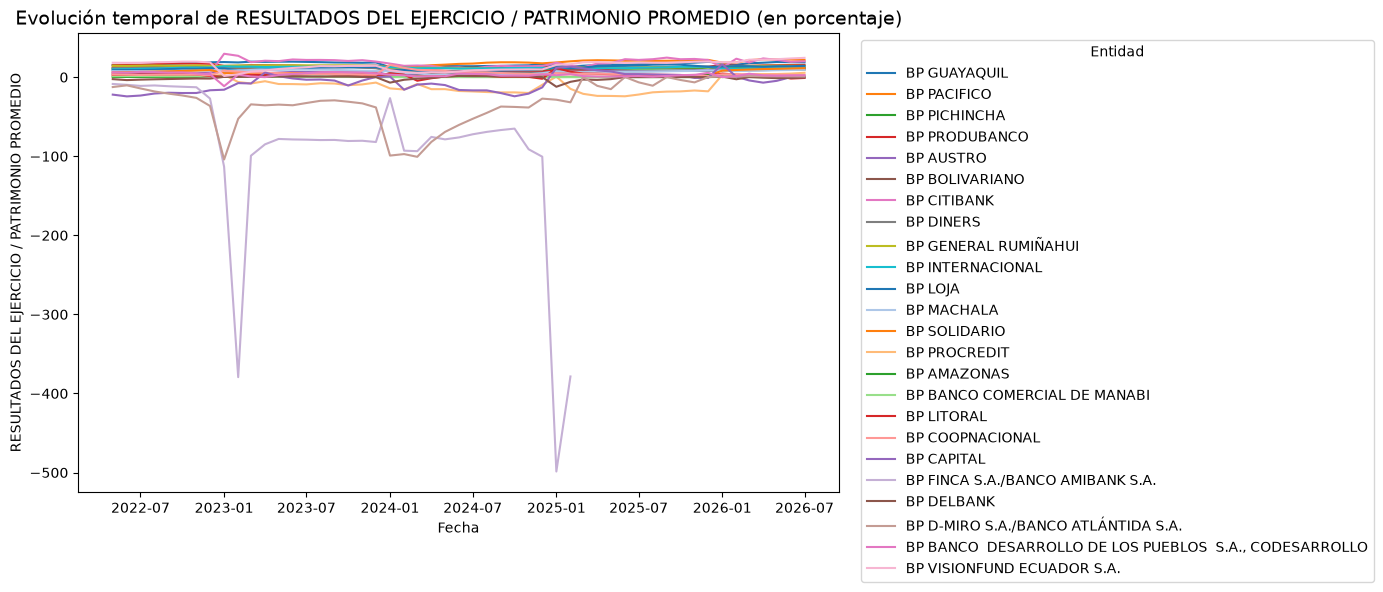

Guardado: graficas_EDA_indicadores_financieros\RESULTADOS_DEL_EJERCICIO__ACTIVO_PROMEDIO.png
Guardado: graficas_EDA_indicadores_financieros\CARTERA_BRUTA__DEPOSITOS_A_LA_VISTA_+_DEPOSITOS_A_PLAZO.png


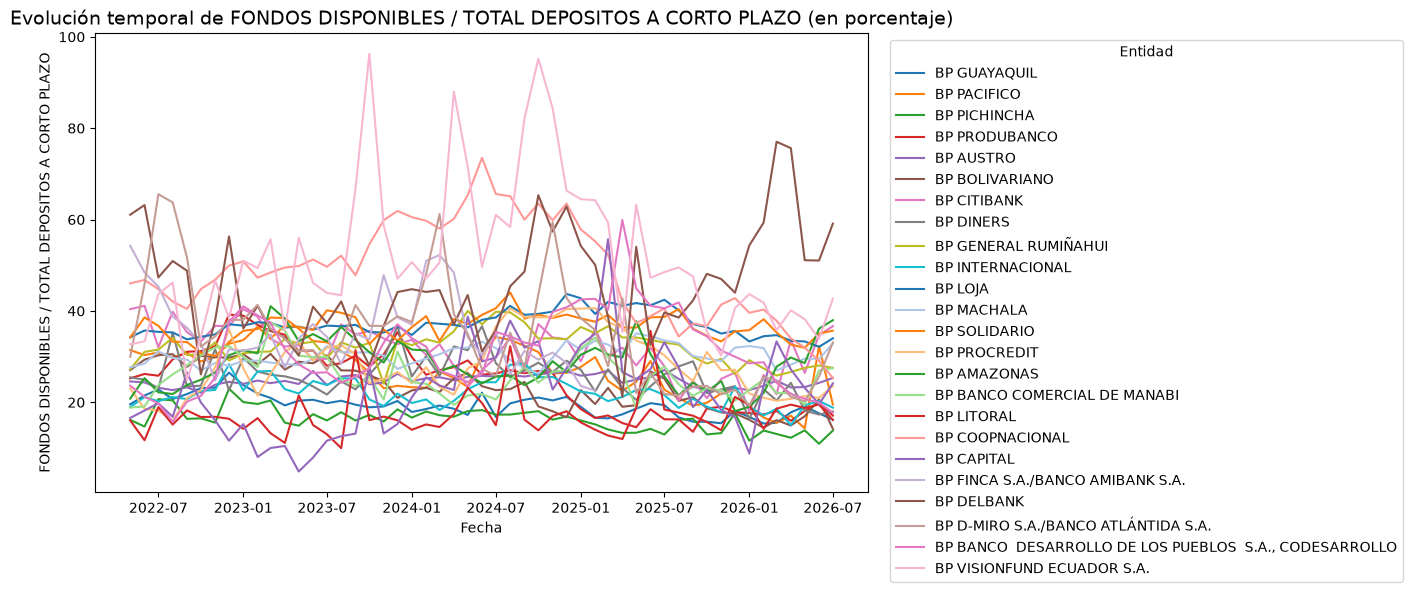

In [16]:
eda.graficar_indicadores(
    base_final,
    indicadores_mayor,
    carpeta="graficas_EDA_indicadores_financieros",
    indicadores_notebook=indicadores_notebook
)


Durante el análisis exploratorio se identificaron valores atípicos particularmente elevados en los indicadores de suficiencia patrimonial y cobertura de la cartera problemática. Sin embargo, estos valores corresponden a Citibank, N.A. Sucursal Ecuador, una entidad con características estructurales diferentes a las del resto de bancos analizados, debido a su condición de banco privado extranjero y a su enfoque principalmente corporativo y empresarial, en lugar de concentrarse en el segmento minorista. Por tanto, estos valores extremos no se consideran inicialmente errores de registro ni se eliminan de la base, ya que pueden reflejar las particularidades de su estructura financiera y de los denominadores utilizados en el cálculo de estos indicadores. En consecuencia, los valores serán conservados para las etapas posteriores de análisis, considerando su posible influencia sobre la distribución de las variables y sobre las técnicas de reducción de dimensionalidad y clustering. 

Con esta consideración, se continúa con el análisis mediante boxplots y mapas de calor (heatmaps) para evaluar la distribución, dispersión y relaciones entre los indicadores.

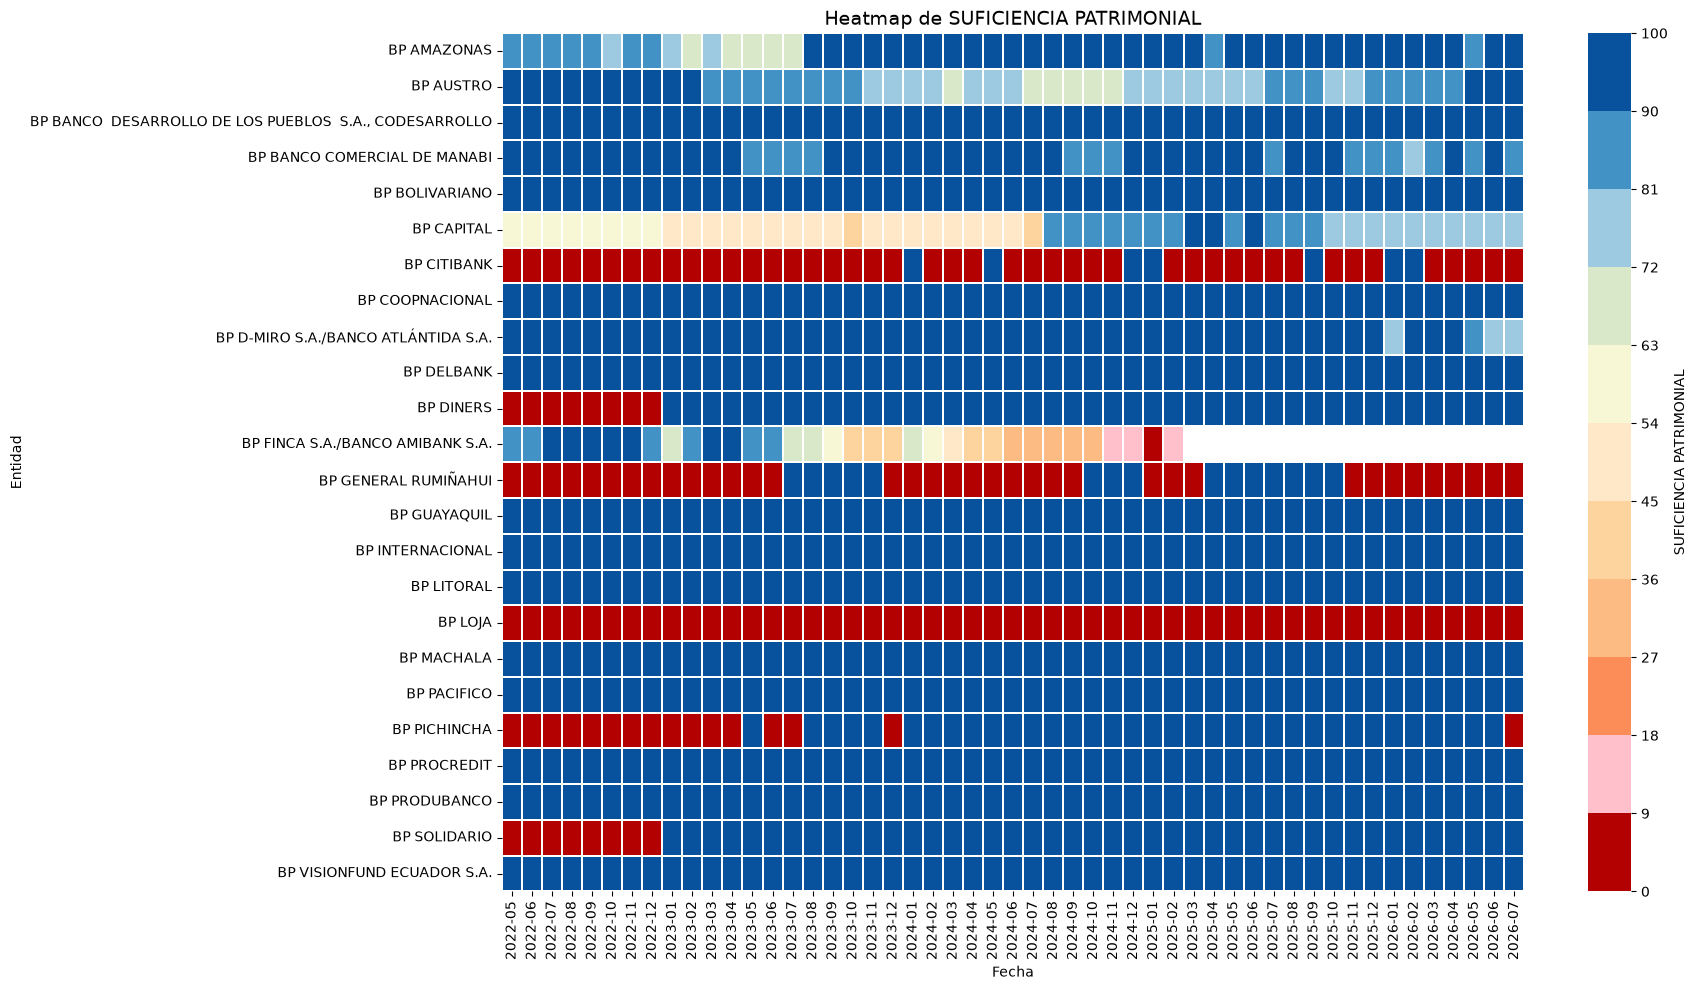

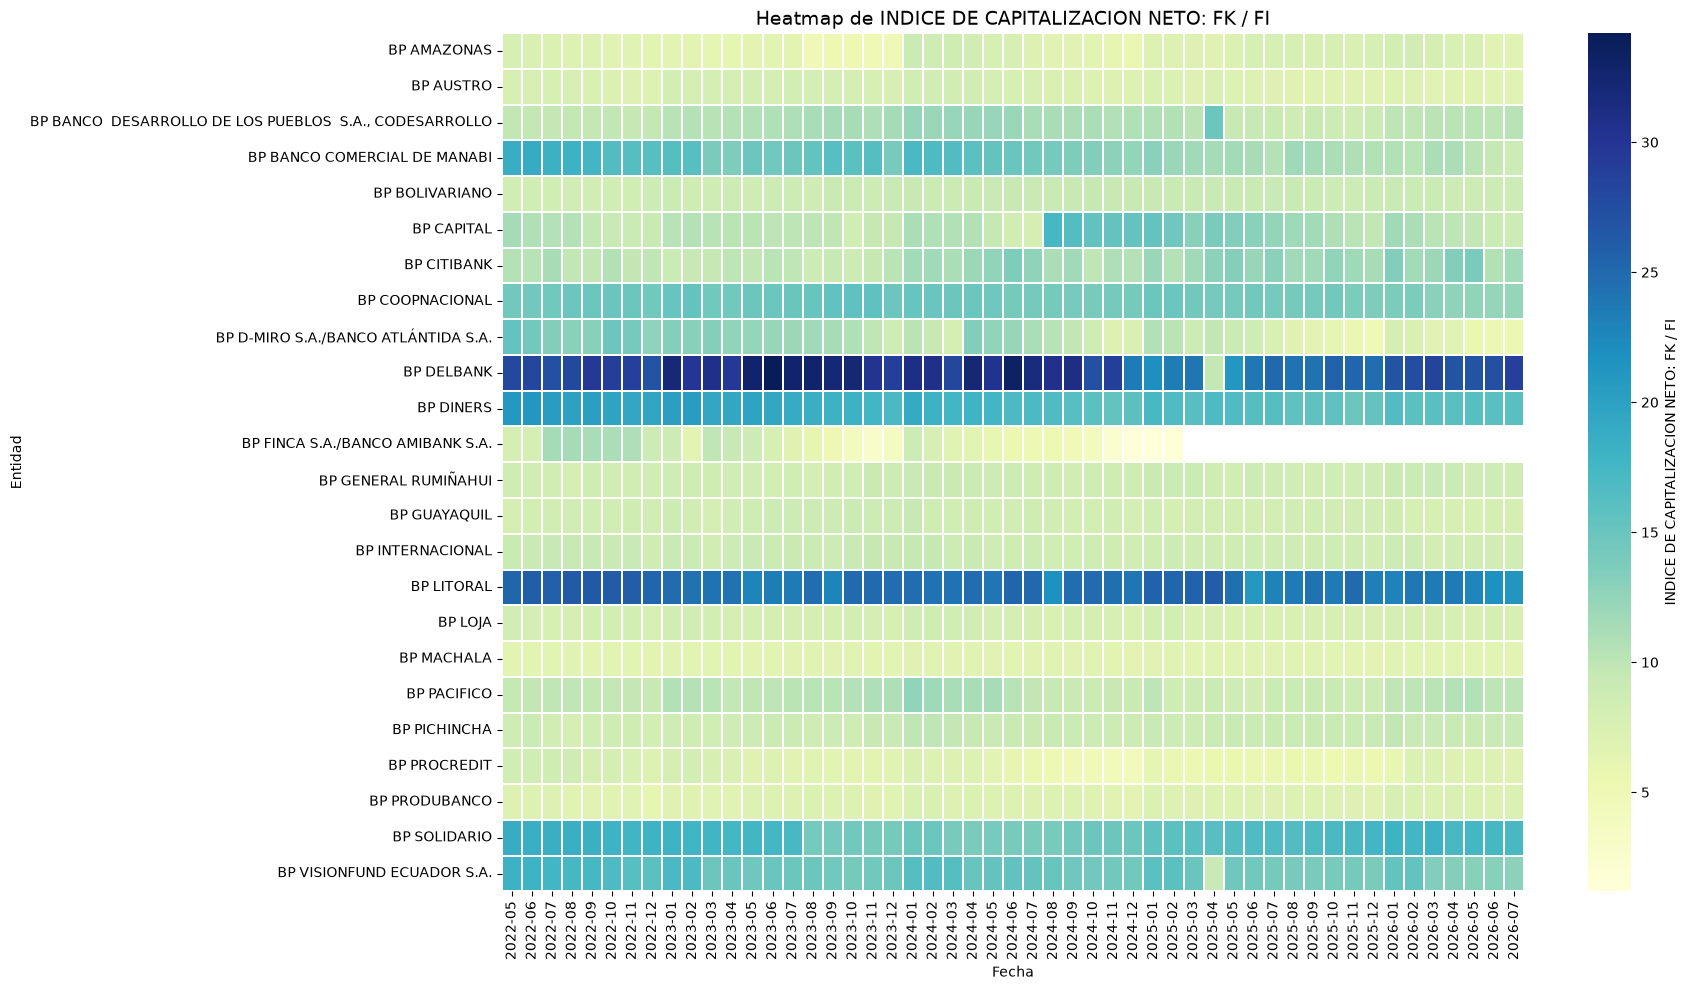

Guardado: graficas_EDA_indicadores_financieros\heatmap_ACTIVOS_PRODUCTIVOS__TOTAL_ACTIVOS.png
Guardado: graficas_EDA_indicadores_financieros\heatmap_ACTIVOS_PRODUCTIVOS__PASIVOS_CON_COSTO.png
Guardado: graficas_EDA_indicadores_financieros\heatmap_COBERTURA_DE_LA_CARTERA_REFINANCIADA.png
Guardado: graficas_EDA_indicadores_financieros\heatmap_COBERTURA_DE_LA_CARTERA_REESTRUCTURADA.png


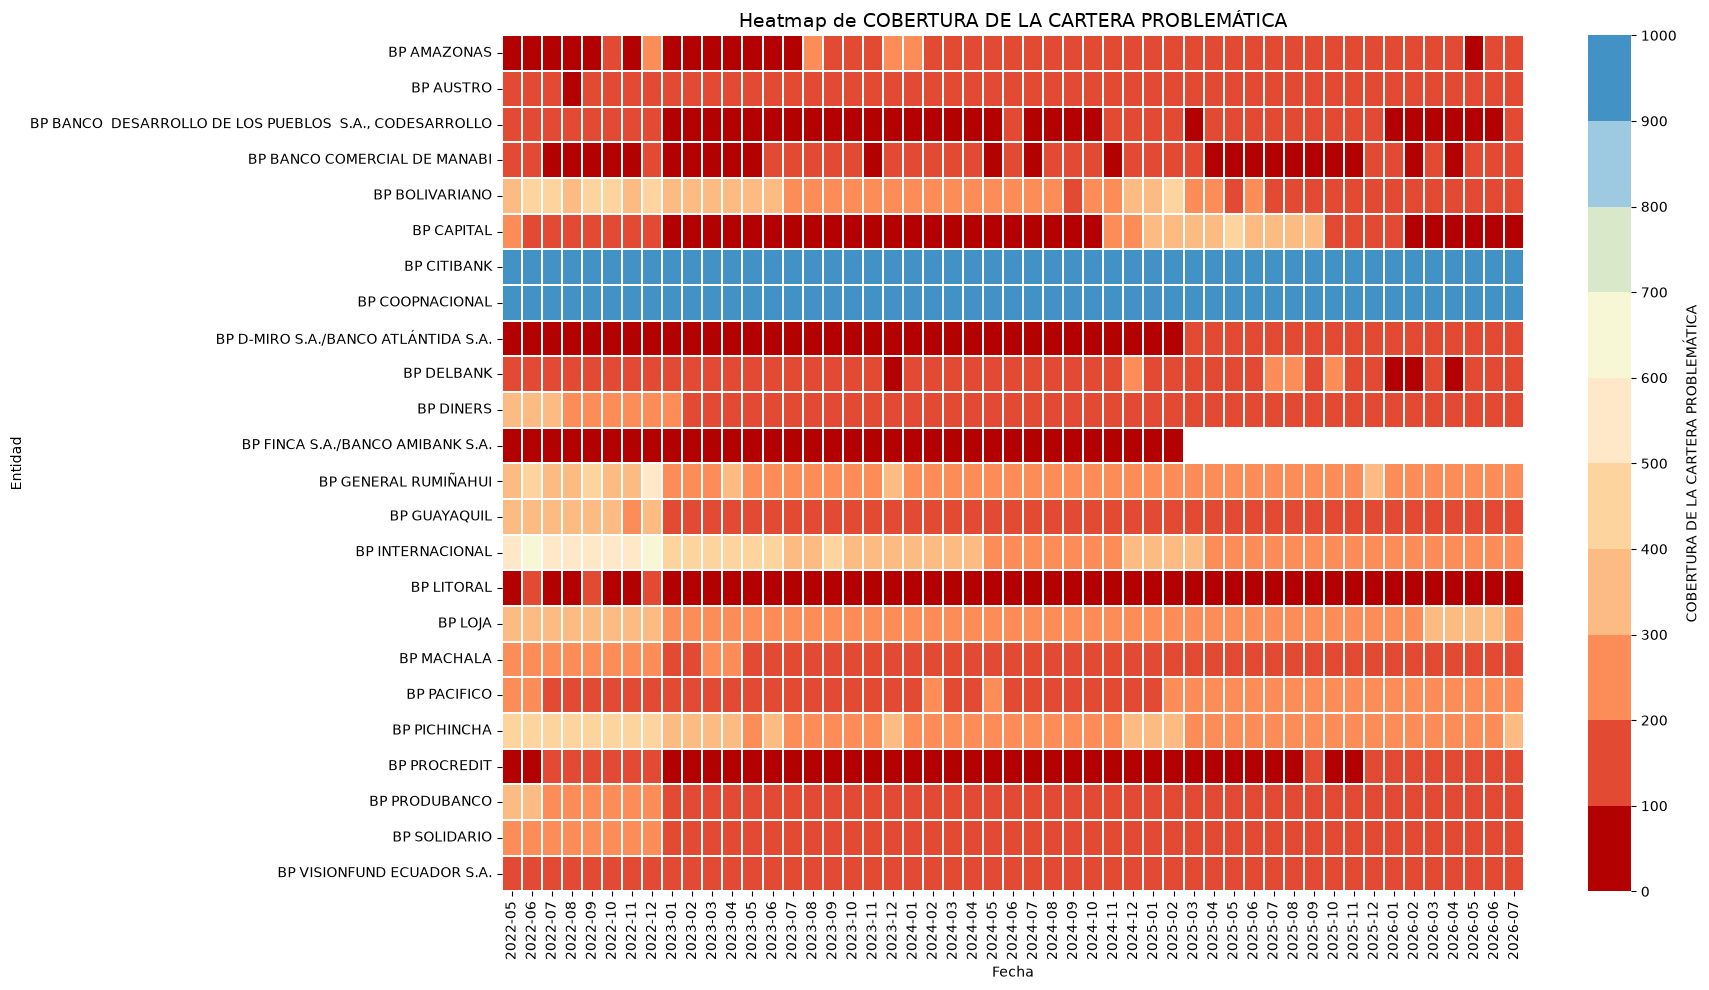

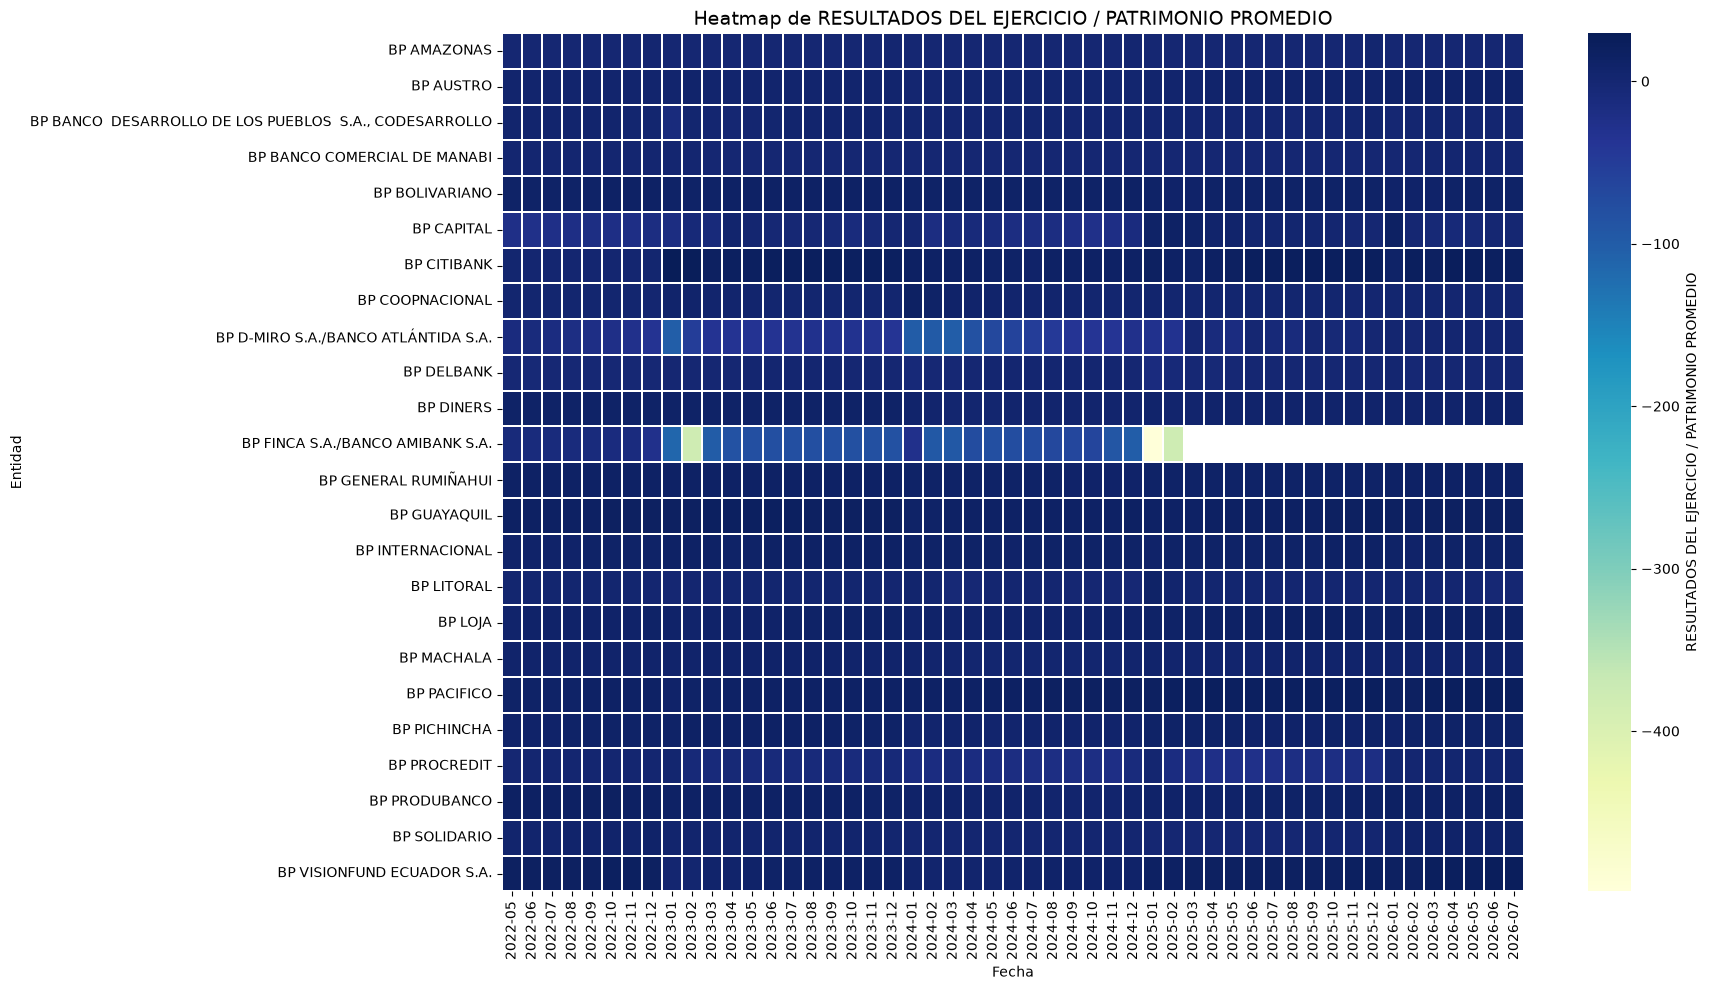

Guardado: graficas_EDA_indicadores_financieros\heatmap_RESULTADOS_DEL_EJERCICIO__ACTIVO_PROMEDIO.png
Guardado: graficas_EDA_indicadores_financieros\heatmap_CARTERA_BRUTA__DEPOSITOS_A_LA_VISTA_+_DEPOSITOS_A_PLAZO.png


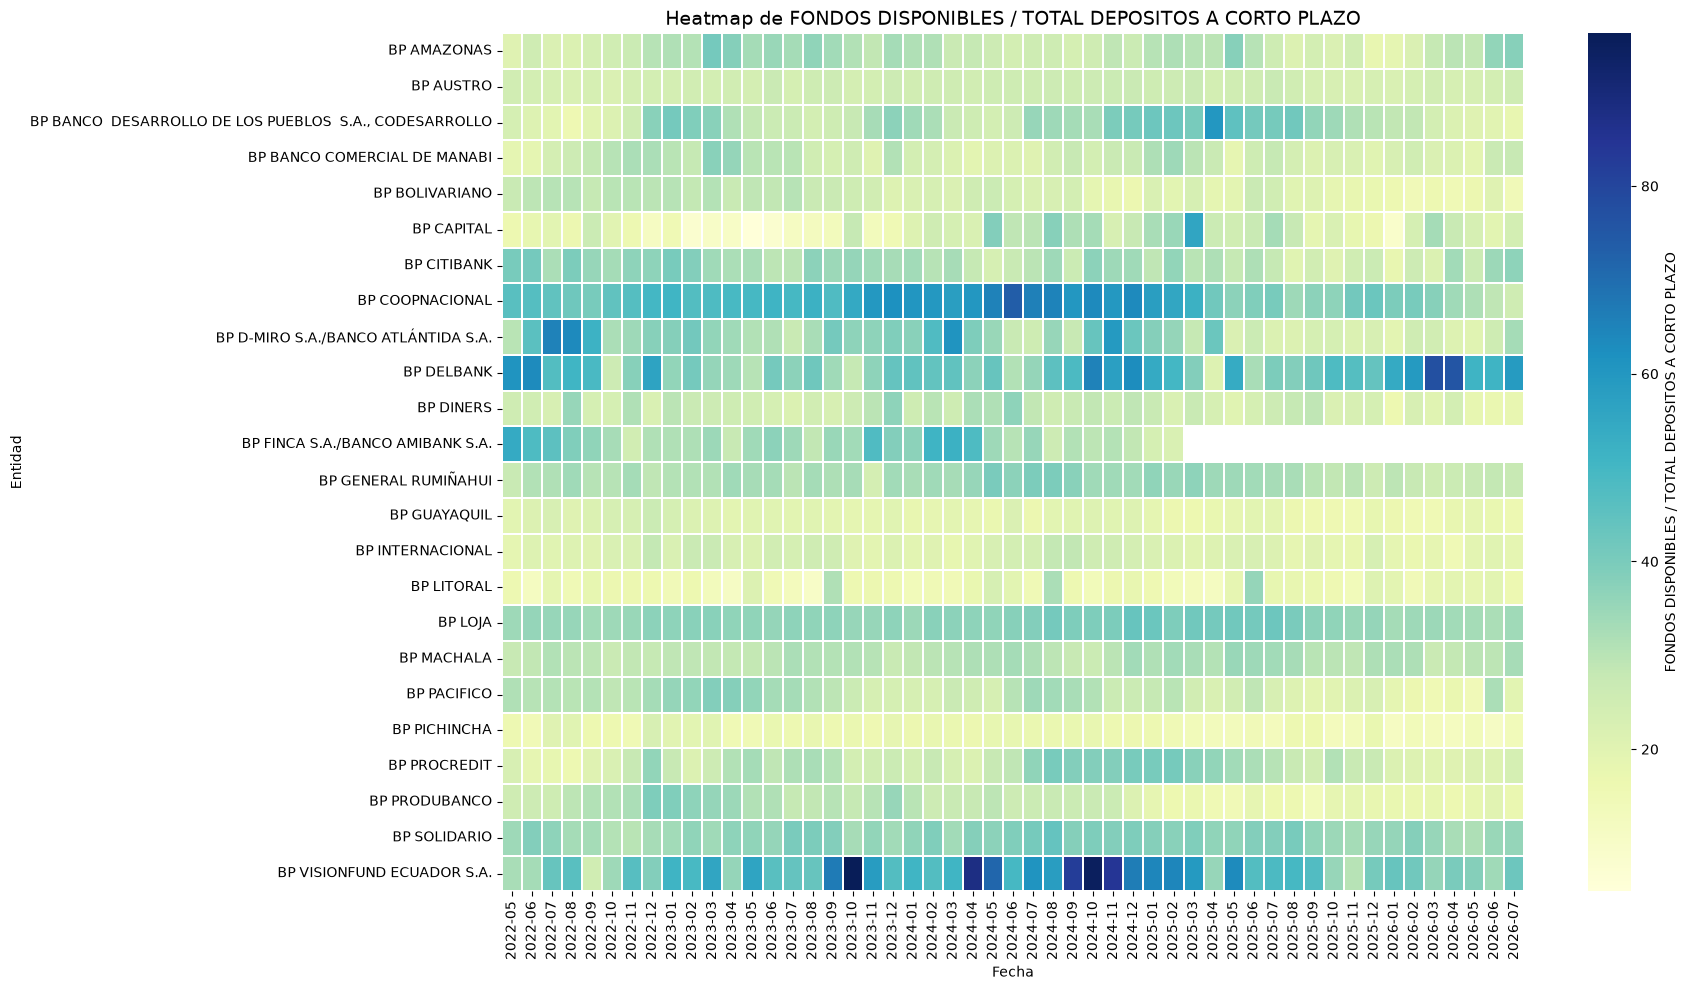

In [17]:
eda.generar_heatmaps(base_final, indicadores_mayor, indicadores_notebook=indicadores_notebook, carpeta="graficas_EDA_indicadores_financieros")

El análisis mediante mapas de calor permitió identificar diferencias importantes en el comportamiento temporal de los indicadores financieros entre las entidades bancarias. En la suficiencia patrimonial se observa una marcada heterogeneidad entre instituciones, con entidades que mantienen niveles elevados durante gran parte del período y otras que presentan valores inferiores al umbral regulatorio del 9%, evidenciando además cambios en determinados períodos. En el índice de capitalización neto se aprecia una mayor estabilidad relativa, aunque persisten diferencias estructurales entre bancos, destacándose algunas entidades con niveles consistentemente superiores al resto. Por su parte, la cobertura de la cartera problemática presenta una elevada dispersión entre instituciones, con valores generalmente inferiores a 100% en varias entidades y niveles considerablemente superiores en otras, particularmente en Citibank, lo que confirma el comportamiento atípico identificado previamente. Finalmente, el indicador de fondos disponibles respecto al total de depósitos de corto plazo muestra variaciones tanto entre entidades como a lo largo del tiempo, permitiendo identificar diferentes patrones de liquidez. En conjunto, los heatmaps evidencian que las entidades bancarias no presentan un comportamiento financiero homogéneo, sino que existen diferencias persistentes y patrones temporales específicos, lo que constituye un primer indicio de la existencia de perfiles financieros diferenciados que serán posteriormente analizados mediante técnicas de reducción de dimensionalidad y clustering.

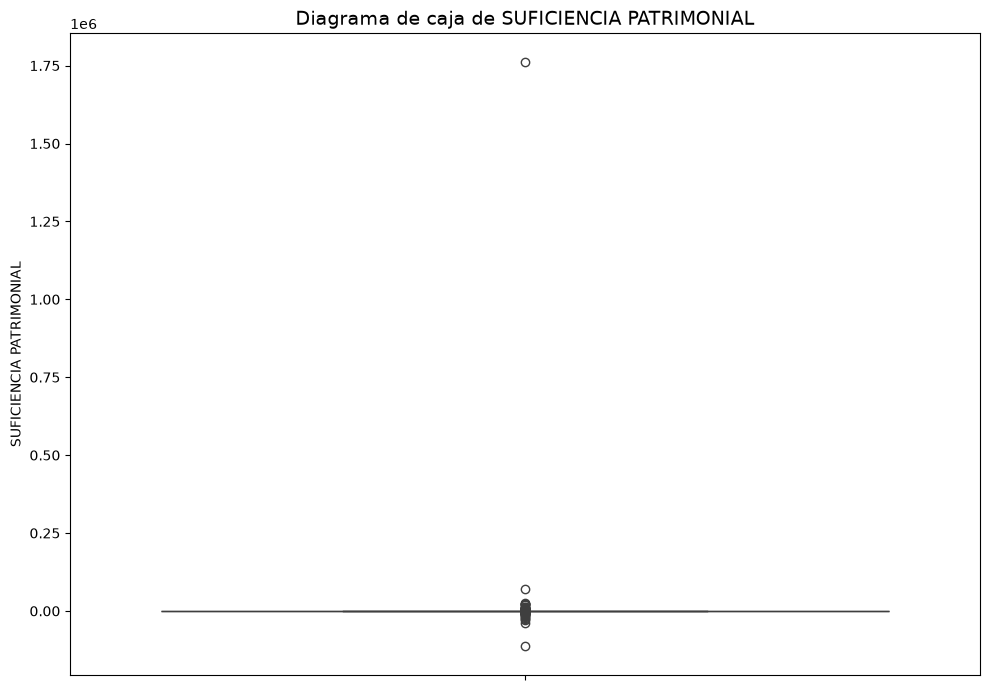

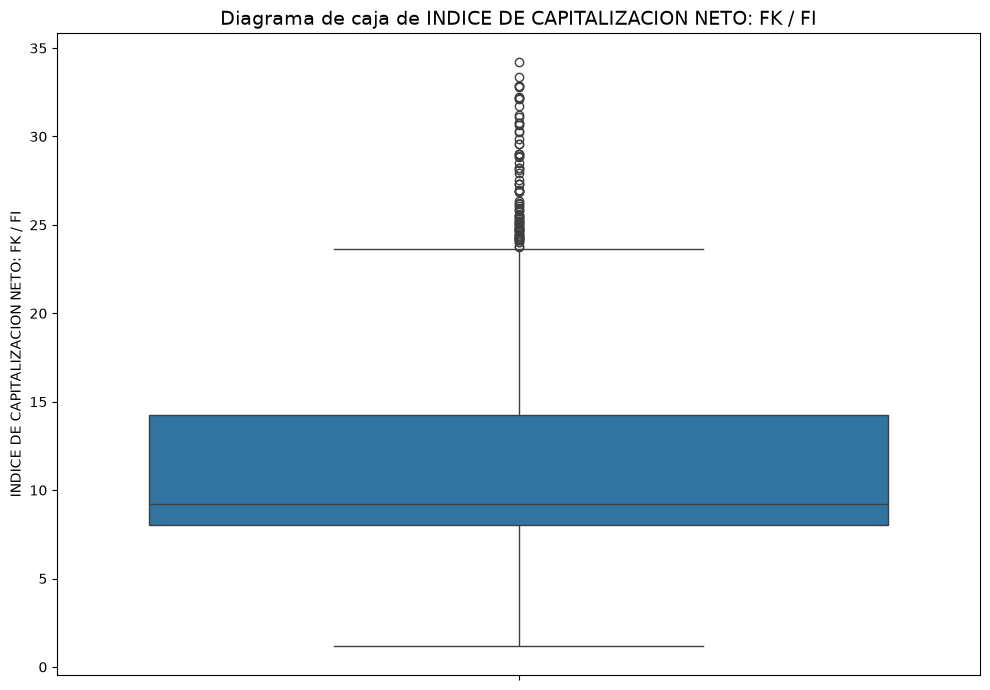

Guardado: graficas_EDA_indicadores_financieros\boxplot_ACTIVOS_PRODUCTIVOS__TOTAL_ACTIVOS.png
Guardado: graficas_EDA_indicadores_financieros\boxplot_ACTIVOS_PRODUCTIVOS__PASIVOS_CON_COSTO.png
Guardado: graficas_EDA_indicadores_financieros\boxplot_COBERTURA_DE_LA_CARTERA_REFINANCIADA.png
Guardado: graficas_EDA_indicadores_financieros\boxplot_COBERTURA_DE_LA_CARTERA_REESTRUCTURADA.png


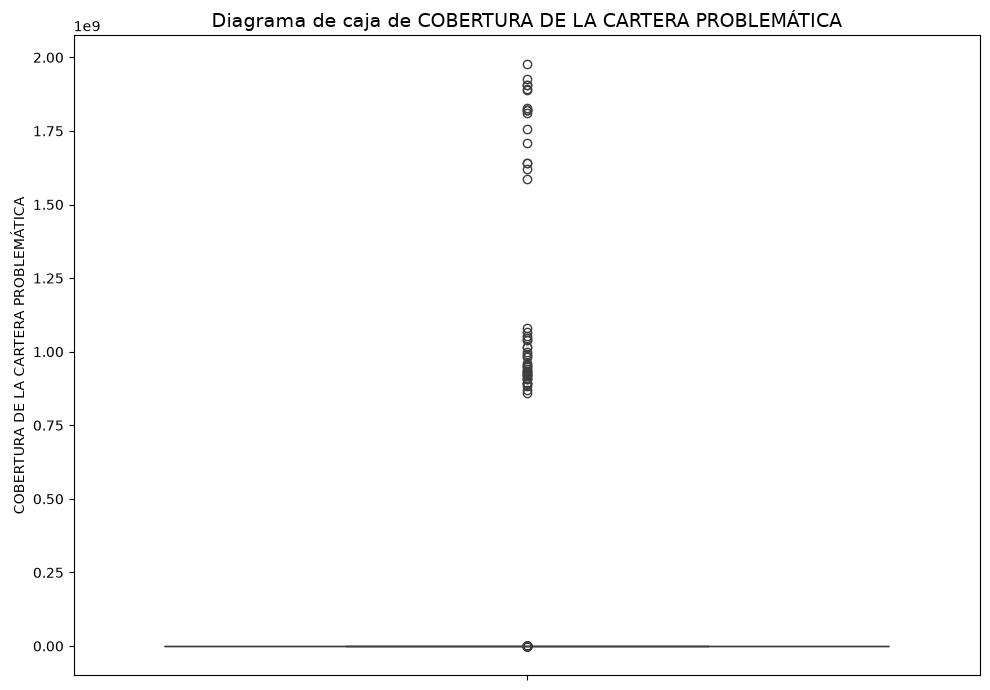

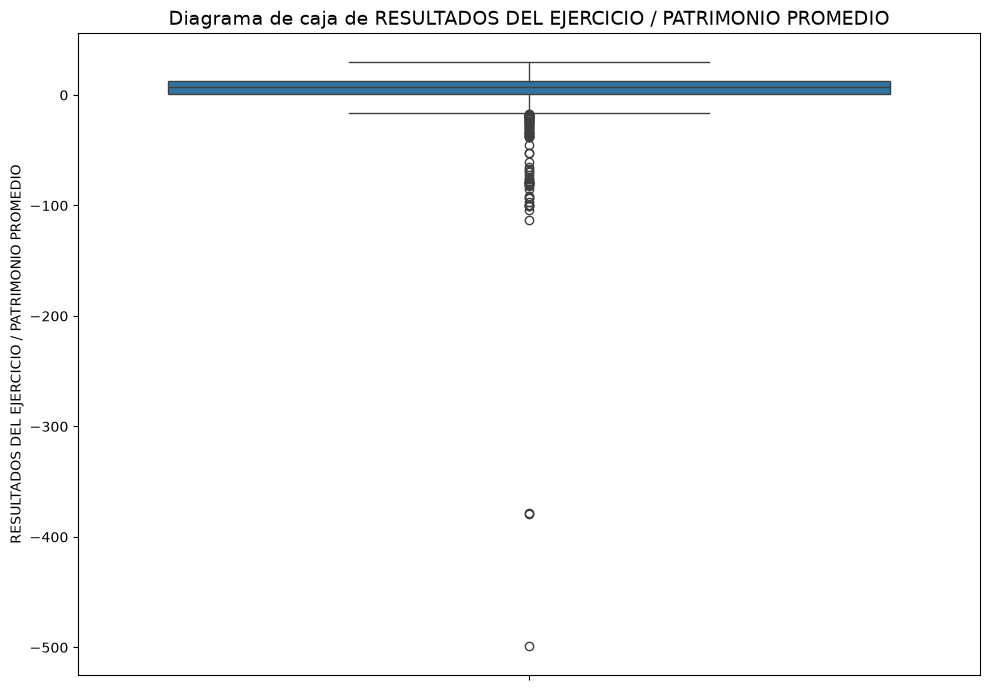

Guardado: graficas_EDA_indicadores_financieros\boxplot_RESULTADOS_DEL_EJERCICIO__ACTIVO_PROMEDIO.png
Guardado: graficas_EDA_indicadores_financieros\boxplot_CARTERA_BRUTA__DEPOSITOS_A_LA_VISTA_+_DEPOSITOS_A_PLAZO.png


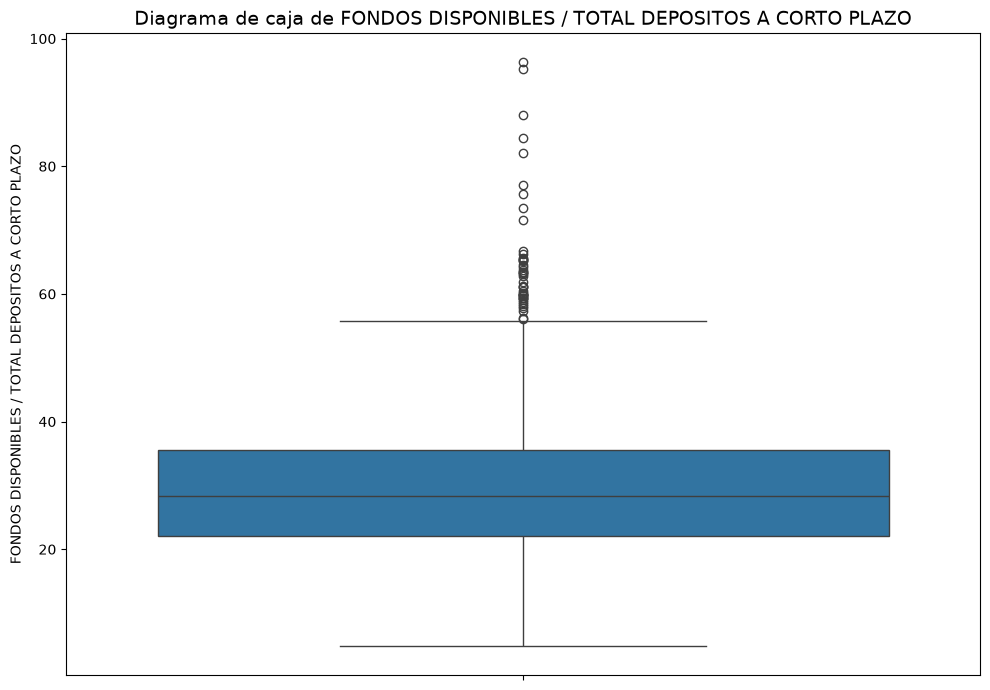

In [18]:
eda.generar_boxplots(base_final, indicadores_mayor, indicadores_notebook=indicadores_notebook, carpeta="graficas_EDA_indicadores_financieros")

Los diagramas de caja evidencian una importante heterogeneidad en la distribución de los indicadores financieros analizados, así como la presencia de valores atípicos en varias de las variables. La suficiencia patrimonial presenta una distribución altamente asimétrica, con numerosos valores extremos y observaciones considerablemente alejadas del conjunto principal, destacándose nuevamente los valores asociados a Citibank. El índice de capitalización neto muestra una dispersión más acotada, aunque presenta múltiples observaciones por encima del límite superior del diagrama, lo que indica la existencia de entidades con niveles de capitalización significativamente superiores al comportamiento central de la muestra. En la cobertura de la cartera problemática se observa una marcada concentración de las observaciones en niveles relativamente bajos y una gran cantidad de valores extremos positivos, asociados principalmente a diferencias importantes en la estructura de las entidades y, particularmente, al comportamiento de Citibank. Por su parte, el indicador de resultados del ejercicio respecto al patrimonio promedio presenta una distribución más concentrada alrededor de valores positivos, aunque se identifican numerosos valores atípicos negativos que pueden corresponder a períodos con resultados desfavorables. Finalmente, el indicador de fondos disponibles respecto al total de depósitos de corto plazo presenta una dispersión moderada y una concentración de observaciones alrededor de su distribución central, acompañada de varios valores extremos superiores. En conjunto, los diagramas de caja confirman la existencia de distribuciones heterogéneas, asimetrías y observaciones extremas, por lo que estos valores deberán ser analizados individualmente para determinar si corresponden a errores de datos, eventos particulares o características financieras propias de las entidades, antes de definir cualquier tratamiento para las etapas posteriores del análisis multivariado.

In [19]:
tabla_atipicos = eda.detectar_atipicos_iqr(
    base_final,
    indicadores_mayor
)

In [20]:
conteo_atipicos = pd.pivot_table(
    tabla_atipicos,
    index=["ENTIDAD", "INDICADOR"],
    columns="TIPO_ATIPICO",
    values="FECHA",
    aggfunc="count",
    fill_value=0
).reset_index()

# Total de atípicos
conteo_atipicos["TOTAL_ATIPICOS"] = (
    conteo_atipicos.get("Inferior", 0)
    + conteo_atipicos.get("Superior", 0)
)

# Ordenar de mayor a menor
conteo_atipicos = conteo_atipicos.sort_values(
    "TOTAL_ATIPICOS",
    ascending=False
).reset_index(drop=True)


In [25]:
# Número de valores no nulos por entidad e indicador
total_valores = (
    base_final
    .groupby("ENTIDAD")[indicadores_mayor]
    .count()
    .reset_index()
    .melt(
        id_vars="ENTIDAD",
        var_name="INDICADOR",
        value_name="TOTAL_VALORES"
    )
)

# Unir con tabla de atípicos
atipicos_f = conteo_atipicos.merge(
    total_valores,
    on=["ENTIDAD", "INDICADOR"],
    how="left"
)

# Porcentaje de valores atípicos problemáticos
atipicos_f["PORC_ATIPICOS_INF"] = (
    atipicos_f["Inferior"]
    / atipicos_f["TOTAL_VALORES"]
    * 100
)

In [26]:
atipicos_f

,ENTIDAD,INDICADOR,Inferior,Superior,TOTAL_ATIPICOS,TOTAL_VALORES,PORC_ATIPICOS_INF
0,BP CITIBANK,ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO,0,51,51,51,0.00000
1,BP CITIBANK,SUFICIENCIA PATRIMONIAL,44,7,51,51,86.27451
2,BP CITIBANK,COBERTURA DE LA CARTERA PROBLEMÁTICA,0,51,51,51,0.00000
3,BP COOPNACIONAL,SUFICIENCIA PATRIMONIAL,0,51,51,51,0.00000
4,BP COOPNACIONAL,COBERTURA DE LA CARTERA PROBLEMÁTICA,0,51,51,51,0.00000
...,...,...,...,...,...,...,...
58,"BP BANCO DESARROLLO DE LOS PUEBLOS S.A., COD...",FONDOS DISPONIBLES / TOTAL DEPOSITOS A CORTO P...,0,1,1,51,0.00000
59,BP CAPITAL,COBERTURA DE LA CARTERA REESTRUCTURADA,0,1,1,51,0.00000
60,BP GENERAL RUMIÑAHUI,COBERTURA DE LA CARTERA PROBLEMÁTICA,0,1,1,51,0.00000
61,BP LITORAL,ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO,0,1,1,51,0.00000


In [27]:
atipicos_f = atipicos_f.sort_values(
    "PORC_ATIPICOS_INF",
    ascending=False
)

In [28]:
atipicos_f

,ENTIDAD,INDICADOR,Inferior,Superior,TOTAL_ATIPICOS,TOTAL_VALORES,PORC_ATIPICOS_INF
8,BP LOJA,SUFICIENCIA PATRIMONIAL,46,0,46,51,90.196078
1,BP CITIBANK,SUFICIENCIA PATRIMONIAL,44,7,51,51,86.274510
19,BP FINCA S.A./BANCO AMIBANK S.A.,RESULTADOS DEL EJERCICIO / ACTIVO PROMEDIO,28,0,28,34,82.352941
20,BP FINCA S.A./BANCO AMIBANK S.A.,RESULTADOS DEL EJERCICIO / PATRIMONIO PROMEDIO,27,0,27,34,79.411765
11,BP D-MIRO S.A./BANCO ATLÁNTIDA S.A.,RESULTADOS DEL EJERCICIO / ACTIVO PROMEDIO,35,0,35,51,68.627451
...,...,...,...,...,...,...,...
58,"BP BANCO DESARROLLO DE LOS PUEBLOS S.A., COD...",FONDOS DISPONIBLES / TOTAL DEPOSITOS A CORTO P...,0,1,1,51,0.000000
59,BP CAPITAL,COBERTURA DE LA CARTERA REESTRUCTURADA,0,1,1,51,0.000000
60,BP GENERAL RUMIÑAHUI,COBERTURA DE LA CARTERA PROBLEMÁTICA,0,1,1,51,0.000000
61,BP LITORAL,ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO,0,1,1,51,0.000000


La identificación de valores atípicos mediante el criterio del rango intercuartílico no se utilizó como criterio automático para excluir entidades de la muestra. Debido a que determinados valores extremos pueden responder a características estructurales propias de las entidades y no necesariamente a errores de registro, las observaciones identificadas fueron sometidas a un proceso de validación. Adicionalmente, se evaluó mediante un análisis de sensibilidad el efecto de las entidades con comportamiento extremo sobre los resultados de la reducción de dimensionalidad y del clustering.

El análisis de valores atípicos mediante el criterio del rango intercuartílico evidencia una concentración de observaciones extremas en determinadas combinaciones de entidades e indicadores. En algunos casos, una misma entidad presenta valores atípicos durante una proporción elevada del período analizado, lo que sugiere la existencia de diferencias estructurales en su comportamiento financiero y no necesariamente errores en los datos. Un caso notable es BP CITIBANK, que presenta 51 de 51 observaciones identificadas como atípicas superiores tanto en el indicador de activos productivos sobre pasivos con costo como en la cobertura de la cartera problemática, mientras que en suficiencia patrimonial registra 44 observaciones atípicas inferiores de un total de 51. Este comportamiento evidencia un perfil financiero diferenciado respecto al resto de entidades y demuestra que los valores atípicos pueden representar características estructurales propias de una institución.

Asimismo, se observa que la dirección de los valores atípicos depende del indicador: mientras algunas variables presentan principalmente observaciones atípicas inferiores, otras concentran sus valores extremos en la parte superior de la distribución. Por tanto, la identificación de atípicos se utilizará como mecanismo de diagnóstico y no como criterio automático de eliminación de observaciones o variables. Dado que el objetivo del estudio es identificar perfiles financieros mediante técnicas de reducción de dimensionalidad y clustering, no se eliminará ningún indicador por presentar una elevada proporción de valores atípicos, ya que estos pueden contener información relevante para diferenciar las entidades bancarias. En consecuencia, se conservará la información observada y, debido a la importancia de los valores extremos en las técnicas posteriores, los datos serán centralizados antes de aplicar la reducción de dimensionalidad y el clustering, buscando disminuir la influencia de las diferencias de escala y mantener la información contenida en las observaciones extremas.

### Indicadores donde valores más bajos representan un mejor desempeño

In [29]:
base_final.columns.to_list()

['MES',
 'AÑO',
 'ENTIDAD',
 'SUFICIENCIA PATRIMONIAL',
 'INDICE DE CAPITALIZACION NETO: FK / FI',
 'ACTIVOS IMPRODUCTIVOS NETOS / TOTAL ACTIVOS',
 'ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS',
 'ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO',
 'MOROSIDAD DE LA CARTERA DE CREDITOS CONSUMO',
 'MOROSIDAD DE LA CARTERA DE CRÉDITOS INMOBILIARIO',
 'MOROSIDAD DE LA CARTERA DE CRÉDITOS MICROCRÉDITO',
 'MOROSIDAD DE LA CARTERA TOTAL',
 'COBERTURA DE LA CARTERA REFINANCIADA',
 'COBERTURA DE LA CARTERA REESTRUCTURADA',
 'COBERTURA DE LA CARTERA PROBLEMÁTICA',
 'GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO PROMEDIO (3)',
 'GASTOS DE OPERACION  / MARGEN FINANCIERO',
 'GASTOS DE PERSONAL ESTIMADOS / ACTIVO PROMEDIO (3)',
 'RESULTADOS DEL EJERCICIO / PATRIMONIO PROMEDIO',
 'RESULTADOS DEL EJERCICIO / ACTIVO PROMEDIO',
 'CARTERA BRUTA / (DEPOSITOS A LA VISTA + DEPOSITOS A PLAZO)',
 'FONDOS DISPONIBLES / TOTAL DEPOSITOS A CORTO PLAZO',
 'CARTERA IMPRODUCTIVA / CARTERA BRUTA',
 'CARTERA VENCIDA / CARTERA BRUTA',
 

In [34]:
indicadores_menor=['ACTIVOS IMPRODUCTIVOS NETOS / TOTAL ACTIVOS',
                   'MOROSIDAD DE LA CARTERA TOTAL',
                    'MOROSIDAD DE LA CARTERA DE CREDITOS CONSUMO',
                    'MOROSIDAD DE LA CARTERA DE CRÉDITOS INMOBILIARIO',
                    'MOROSIDAD DE LA CARTERA DE CRÉDITOS MICROCRÉDITO',
                    'GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO PROMEDIO (3)',
                    'GASTOS DE OPERACION  / MARGEN FINANCIERO',
                    'GASTOS DE PERSONAL ESTIMADOS / ACTIVO PROMEDIO (3)']

In [35]:
indicadores_notebook = [
    'ACTIVOS IMPRODUCTIVOS NETOS / TOTAL ACTIVOS',
    'MOROSIDAD DE LA CARTERA TOTAL',
    'GASTOS DE OPERACION  / MARGEN FINANCIERO'
]

In [36]:
# Diccionario de meses
meses = {
    "enero": 1,
    "febrero": 2,
    "marzo": 3,
    "abril": 4,
    "mayo": 5,
    "junio": 6,
    "julio": 7,
    "agosto": 8,
    "septiembre": 9,
    "octubre": 10,
    "noviembre": 11,
    "diciembre": 12
}

# Crear número de mes
base_final["MES_NUM"] = base_final["MES"].str.lower().map(meses)

# Crear fecha
base_final["FECHA"] = pd.to_datetime(
    base_final["AÑO"].astype(str) + "-" +
    base_final["MES_NUM"].astype(str) + "-01"
)

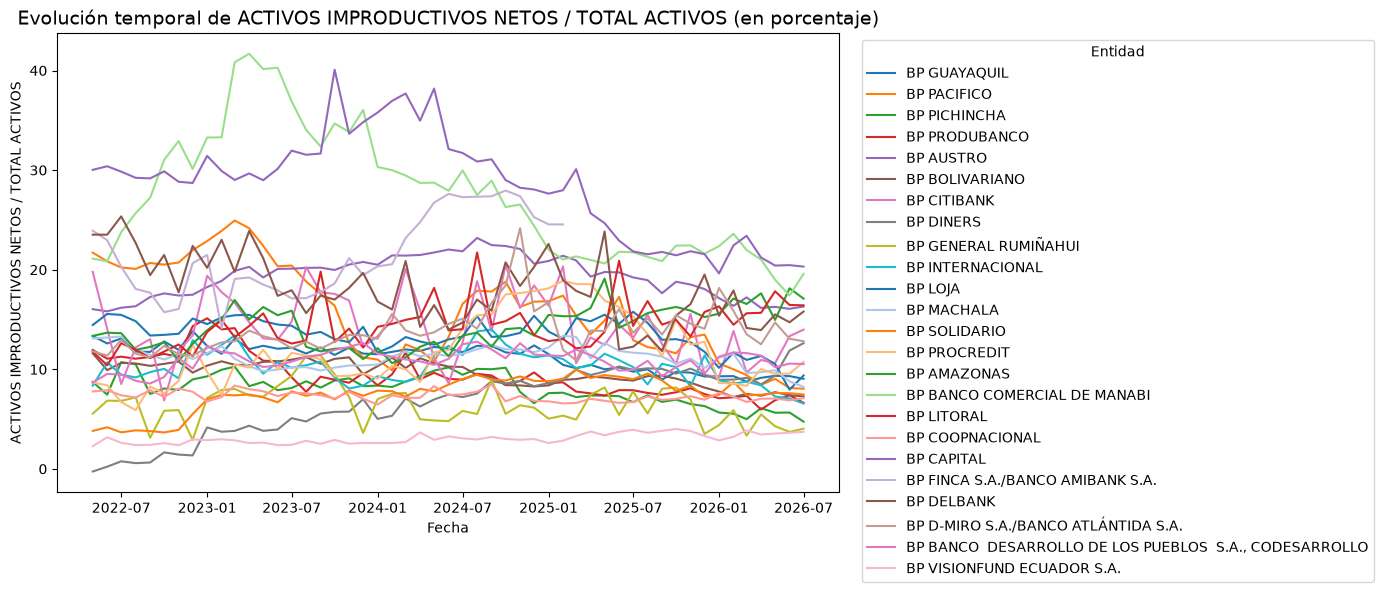

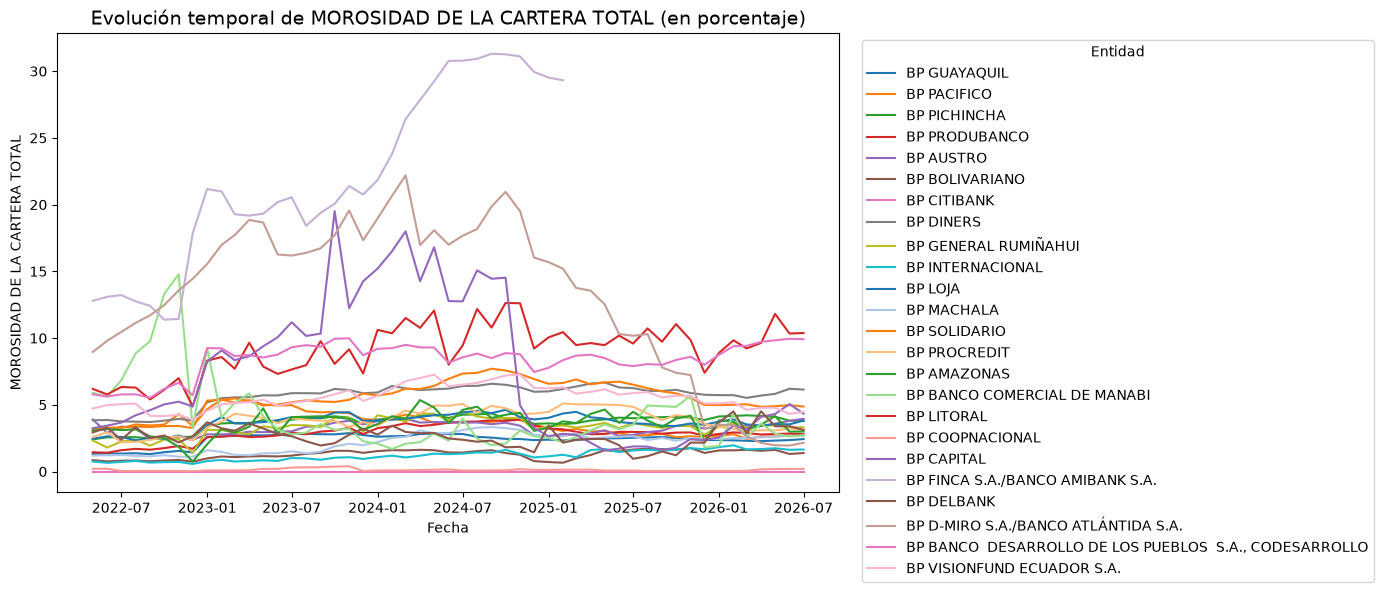

Guardado: graficas_EDA_indicadores_financieros\MOROSIDAD_DE_LA_CARTERA_DE_CREDITOS_CONSUMO.png
Guardado: graficas_EDA_indicadores_financieros\MOROSIDAD_DE_LA_CARTERA_DE_CRÉDITOS_INMOBILIARIO.png
Guardado: graficas_EDA_indicadores_financieros\MOROSIDAD_DE_LA_CARTERA_DE_CRÉDITOS_MICROCRÉDITO.png
Guardado: graficas_EDA_indicadores_financieros\GASTOS_DE_OPERACION_ESTIMADOS__TOTAL_ACTIVO_PROMEDIO_3.png


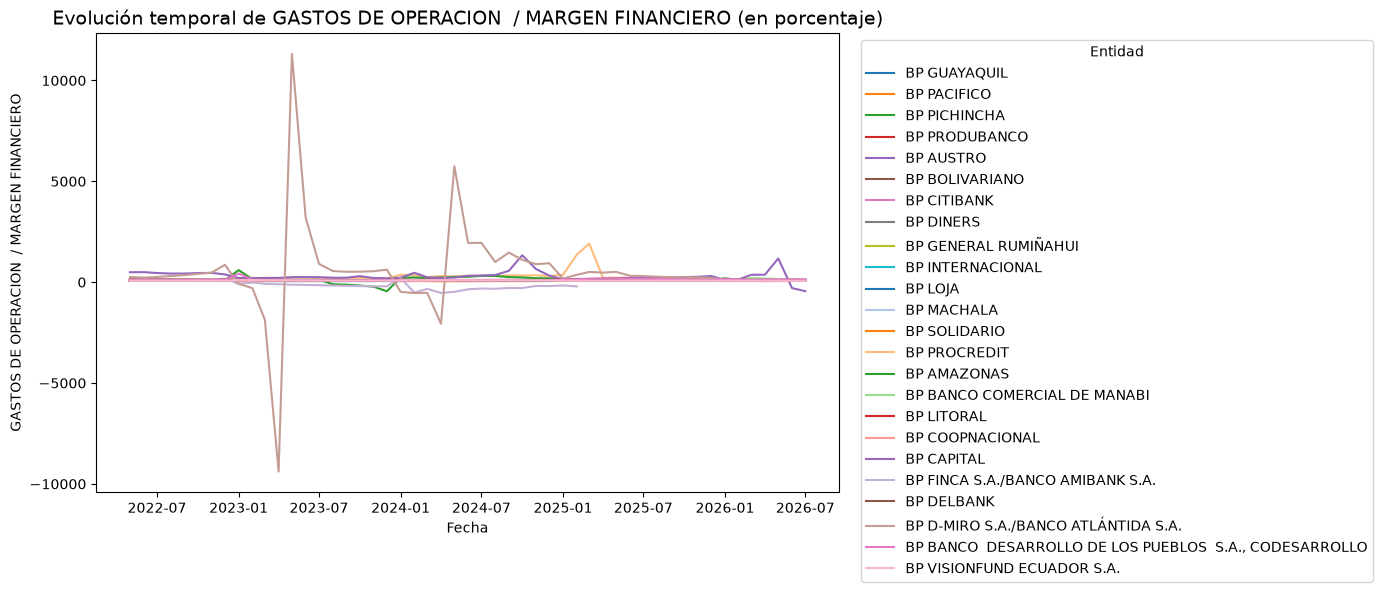

Guardado: graficas_EDA_indicadores_financieros\GASTOS_DE_PERSONAL_ESTIMADOS__ACTIVO_PROMEDIO_3.png


In [37]:
eda.graficar_indicadores(
    base_final,
    indicadores_menor,
    carpeta="graficas_EDA_indicadores_financieros",
    indicadores_notebook=indicadores_notebook
)


El análisis de la evolución temporal evidencia diferencias importantes entre las entidades bancarias en indicadores asociados con distintos componentes de su perfil financiero. En particular, la morosidad de la cartera total muestra una marcada heterogeneidad: mientras varias entidades mantienen niveles relativamente bajos y estables, algunas presentan niveles considerablemente superiores. Destaca BP FINCA S.A./Banco Amibank S.A., cuya morosidad supera el 30% durante varios períodos, seguida por BP D-MIRO S.A./Banco Atlántida S.A., que alcanza niveles superiores al 20% en determinados períodos.

Esta diferenciación también se observa en la proporción de activos improductivos netos sobre el total de activos. Entidades como BP BANCO COMERCIAL DE MANABÍ y BP CAPITAL presentan niveles elevados y trayectorias diferenciadas respecto a otras instituciones, que se mantienen en rangos considerablemente menores. Esto evidencia que las entidades presentan estructuras distintas en cuanto a la composición y calidad de sus activos.

Por otra parte, el indicador de gastos de operación respecto al margen financiero presenta una dispersión particularmente elevada, con episodios extremos en determinadas entidades, lo que evidencia diferencias importantes en la relación entre los gastos operativos y los ingresos generados por la actividad financiera. Estos valores extremos deberán ser considerados posteriormente en el análisis de los datos, sin asumir inicialmente que corresponden a errores, debido a la naturaleza del indicador y a la posible influencia de variaciones en el margen financiero.

En conjunto, las tres variables evidencian que las entidades bancarias presentan comportamientos diferenciados no solo en términos de morosidad, sino también respecto a la calidad de sus activos y su eficiencia operativa. Por ejemplo, mientras algunas entidades presentan niveles elevados de morosidad, otras destacan por una mayor proporción de activos improductivos o por una mayor variabilidad en sus gastos de operación. Estas diferencias sugieren la existencia de distintos perfiles financieros entre las instituciones analizadas y constituyen evidencia exploratoria que respalda la aplicación posterior de técnicas de reducción de dimensionalidad y clustering para identificar y caracterizar dichos perfiles.

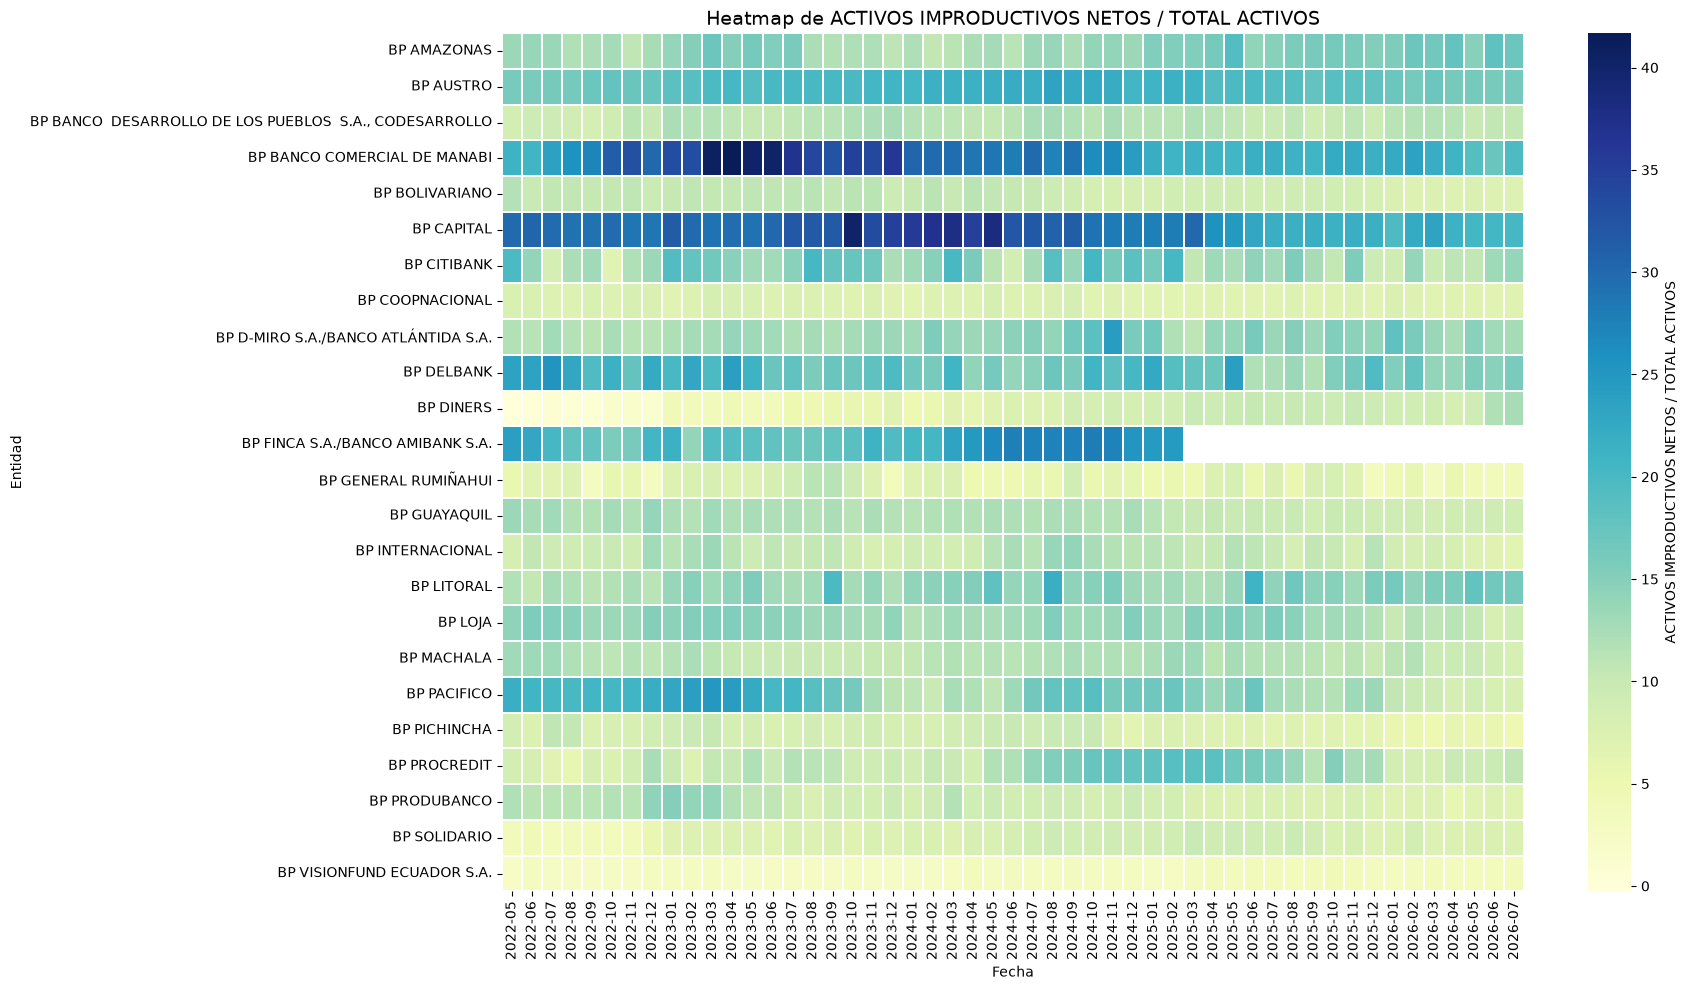

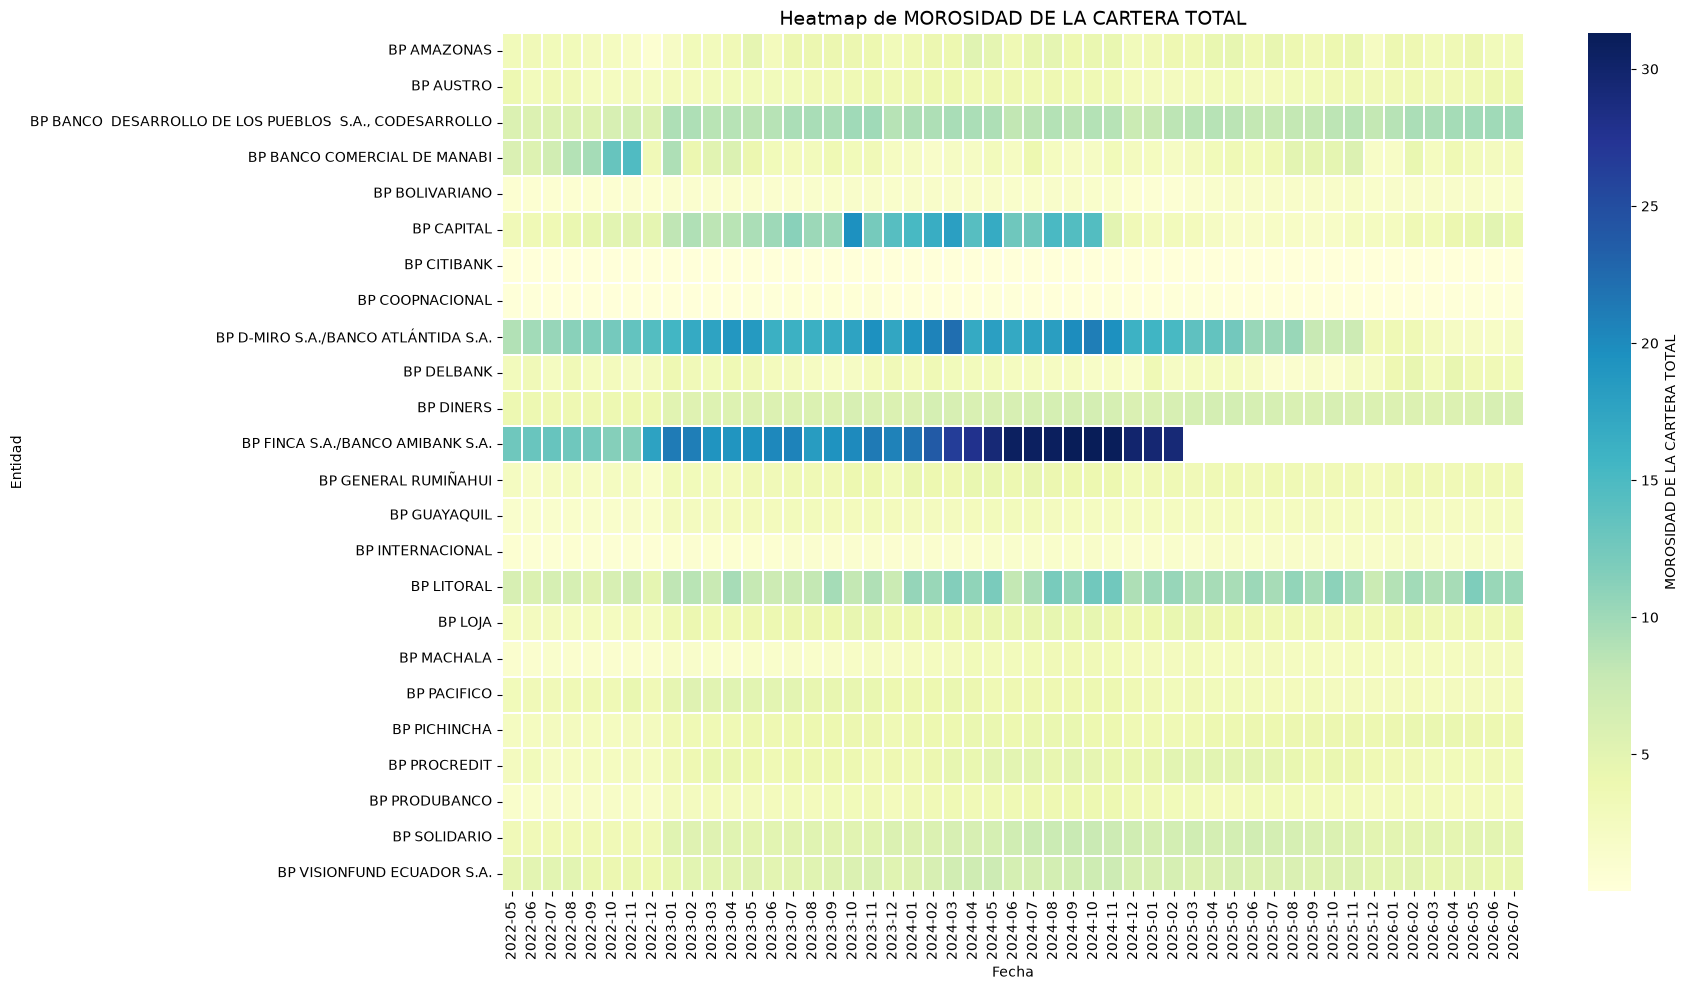

Guardado: graficas_EDA_indicadores_financieros\heatmap_MOROSIDAD_DE_LA_CARTERA_DE_CREDITOS_CONSUMO.png
Guardado: graficas_EDA_indicadores_financieros\heatmap_MOROSIDAD_DE_LA_CARTERA_DE_CRÉDITOS_INMOBILIARIO.png
Guardado: graficas_EDA_indicadores_financieros\heatmap_MOROSIDAD_DE_LA_CARTERA_DE_CRÉDITOS_MICROCRÉDITO.png
Guardado: graficas_EDA_indicadores_financieros\heatmap_GASTOS_DE_OPERACION_ESTIMADOS__TOTAL_ACTIVO_PROMEDIO_3.png


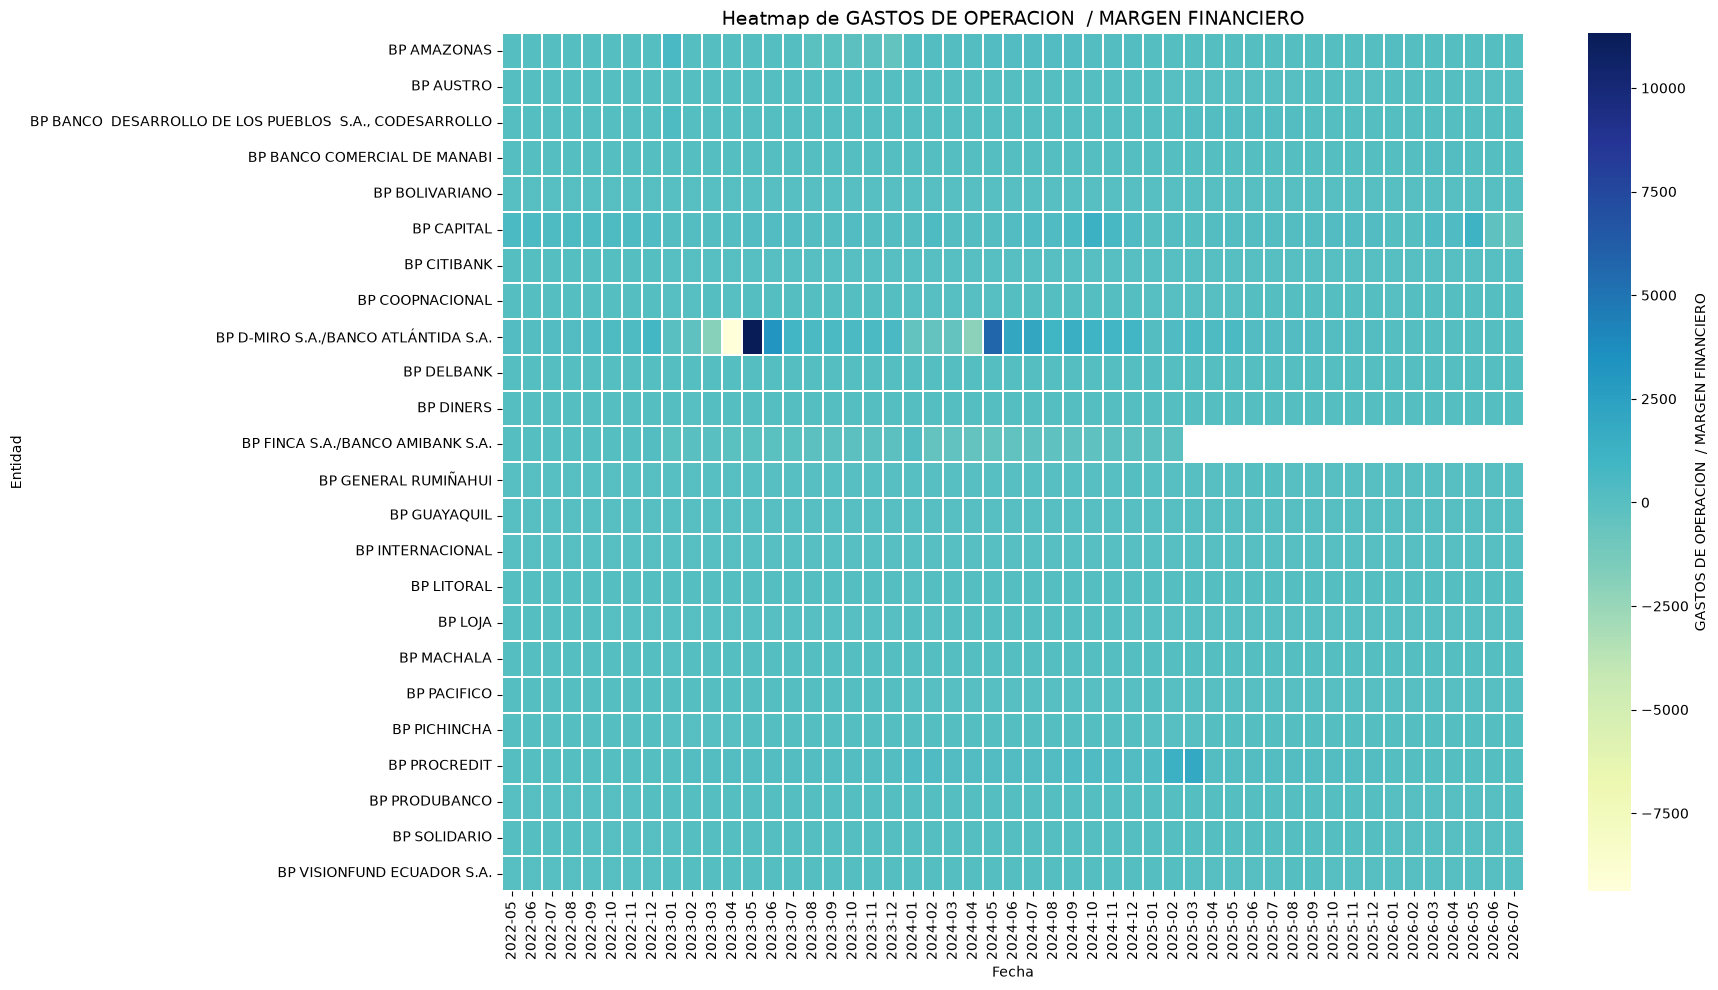

Guardado: graficas_EDA_indicadores_financieros\heatmap_GASTOS_DE_PERSONAL_ESTIMADOS__ACTIVO_PROMEDIO_3.png


In [38]:
eda.generar_heatmaps(base_final, indicadores_menor, indicadores_notebook=indicadores_notebook, carpeta="graficas_EDA_indicadores_financieros")

Los tres heatmaps evidencian una marcada heterogeneidad entre las entidades bancarias privadas a lo largo del período analizado, tanto en términos de calidad de activos, riesgo de crédito como de eficiencia operativa. En cuanto a los activos improductivos netos sobre el total de activos, se observan entidades con niveles persistentemente elevados, como BP BANCO COMERCIAL DE MANABÍ y BP CAPITAL, cuyos valores alcanzan niveles superiores al 30% durante determinados períodos, mientras que otras entidades, como BP COOPNACIONAL, BP GENERAL RUMIÑAHUI y BP VISIONFUND ECUADOR S.A., mantienen proporciones considerablemente menores.

Las diferencias son aún más marcadas en la morosidad de la cartera total. BP FINCA S.A./BANCO AMIBANK S.A. presenta los niveles más elevados, superando el 30% durante varios períodos, mientras que BP D-MIRO S.A./BANCO ATLÁNTIDA S.A. alcanza niveles superiores al 20% en determinados momentos. En contraste, entidades como BP AMAZONAS, BP AUSTRO, BP GUAYAQUIL y BP PICHINCHA mantienen niveles considerablemente menores durante gran parte del período. Esto evidencia que las entidades presentan perfiles diferenciados respecto al riesgo de crédito y la calidad de su cartera.

Finalmente, el indicador de gastos de operación sobre margen financiero presenta una distribución considerablemente más dispersa, con episodios extremos concentrados principalmente en BP D-MIRO S.A./BANCO ATLÁNTIDA S.A. y otros períodos puntuales en distintas entidades. Esta elevada variabilidad muestra diferencias en la relación entre los gastos operativos y el margen generado por la actividad financiera y, al mismo tiempo, evidencia la necesidad de considerar cuidadosamente los valores extremos antes de aplicar las técnicas de reducción de dimensionalidad.

En conjunto, los tres indicadores muestran que las entidades no presentan un comportamiento financiero homogéneo: algunas se caracterizan por mayores niveles de activos improductivos, otras por una mayor exposición al riesgo de crédito y otras por comportamientos diferenciados en términos de eficiencia operativa. Por ejemplo, BP FINCA S.A./BANCO AMIBANK S.A. destaca por sus elevados niveles de morosidad y activos improductivos, mientras que BP CAPITAL y BP BANCO COMERCIAL DE MANABÍ presentan niveles elevados de activos improductivos. Estas diferencias sugieren la existencia de estructuras y comportamientos financieros diferenciados entre las instituciones, lo que constituye evidencia exploratoria relevante para la identificación de perfiles financieros mediante técnicas de reducción de dimensionalidad y clustering.

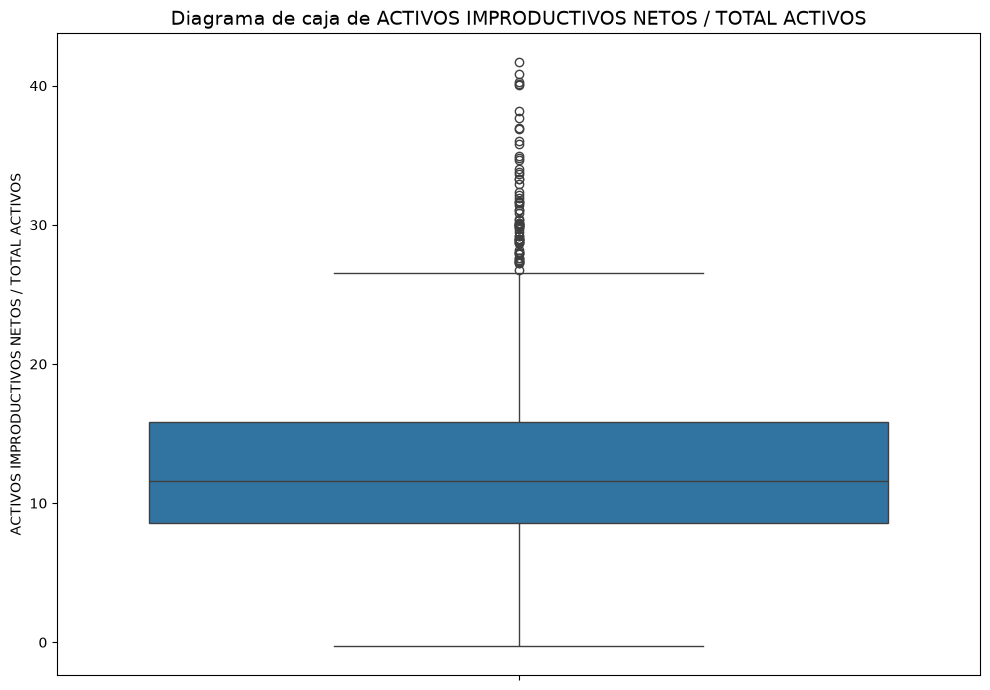

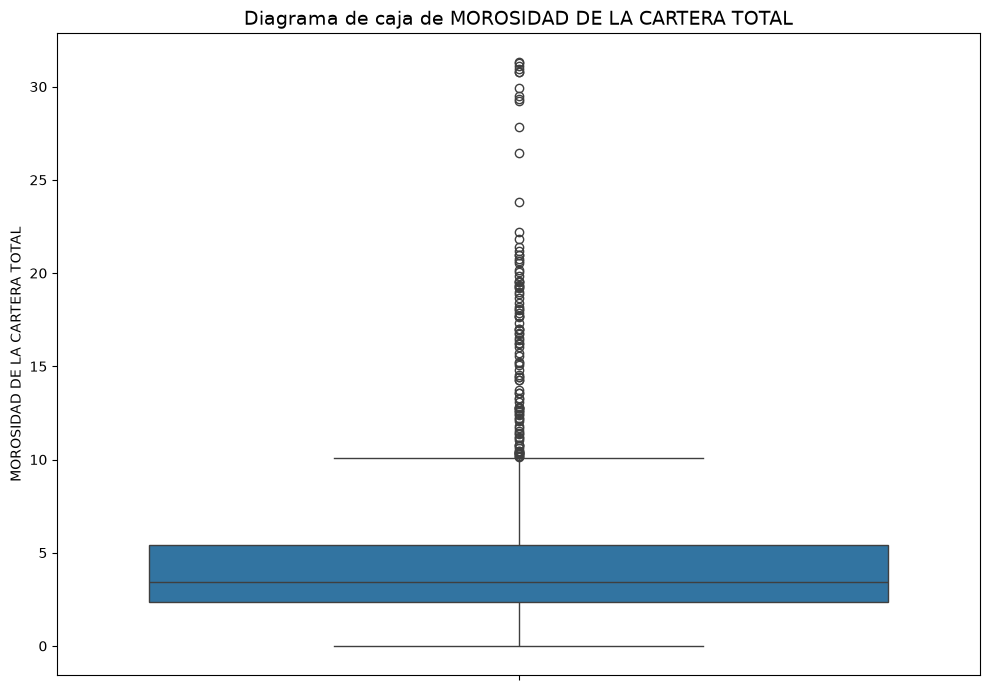

Guardado: graficas_EDA_indicadores_financieros\boxplot_MOROSIDAD_DE_LA_CARTERA_DE_CREDITOS_CONSUMO.png
Guardado: graficas_EDA_indicadores_financieros\boxplot_MOROSIDAD_DE_LA_CARTERA_DE_CRÉDITOS_INMOBILIARIO.png
Guardado: graficas_EDA_indicadores_financieros\boxplot_MOROSIDAD_DE_LA_CARTERA_DE_CRÉDITOS_MICROCRÉDITO.png
Guardado: graficas_EDA_indicadores_financieros\boxplot_GASTOS_DE_OPERACION_ESTIMADOS__TOTAL_ACTIVO_PROMEDIO_3.png


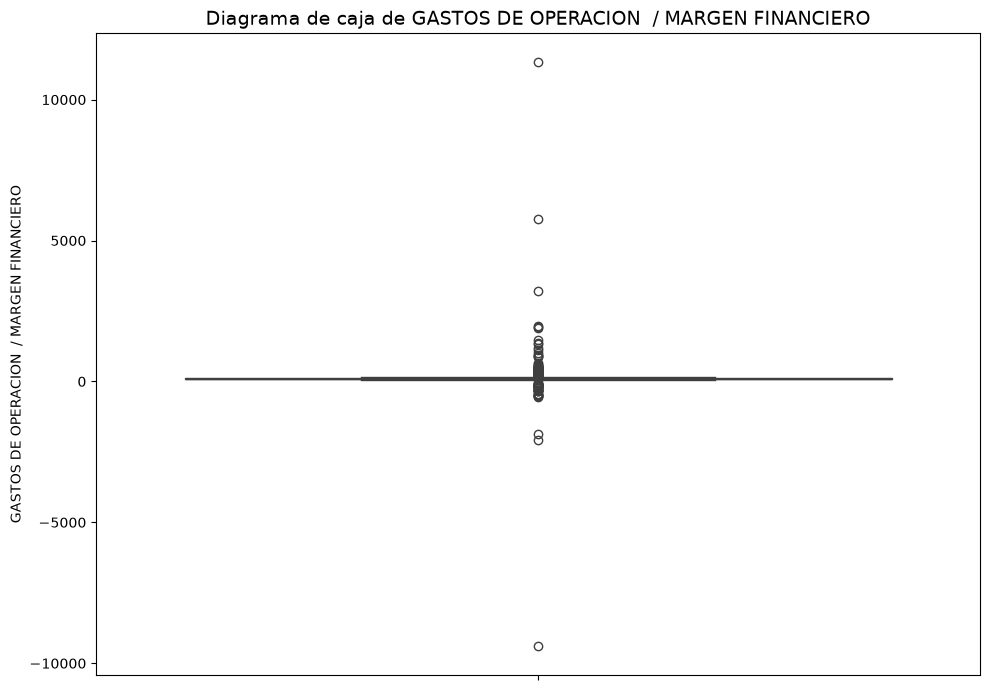

Guardado: graficas_EDA_indicadores_financieros\boxplot_GASTOS_DE_PERSONAL_ESTIMADOS__ACTIVO_PROMEDIO_3.png


In [ ]:
eda.generar_boxplots(base_final, indicadores_menor, indicadores_notebook=indicadores_notebook, carpeta="graficas_EDA_indicadores_financieros")

Los diagramas de caja evidencian una importante presencia de valores atípicos superiores al límite de $Q3 + 1.5 \times IQR$, especialmente en los indicadores donde un menor valor representa un mejor desempeño. En activos improductivos netos / total activos, se observa una distribución con numerosos valores por encima del límite superior, alcanzando niveles superiores al 40%, lo que evidencia la existencia de entidades con proporciones de activos improductivos significativamente mayores al comportamiento central de la muestra.

En morosidad de la cartera total, la concentración de valores atípicos superiores es aún más evidente. La distribución central se mantiene en niveles relativamente bajos, pero existe un número considerable de observaciones que superan el límite superior, llegando a valores superiores al 30%. Estos resultados muestran que determinadas entidades presentan niveles de morosidad considerablemente superiores al comportamiento general.

Finalmente, gastos de operación / margen financiero presenta la mayor dispersión y una cantidad importante de valores extremos tanto positivos como negativos. Destacan observaciones que superan ampliamente el límite superior, con valores superiores al 10.000%, lo que evidencia una distribución altamente asimétrica y requiere especial atención antes de las técnicas posteriores.

En conjunto, los resultados muestran que los valores atípicos superiores son relevantes en los indicadores asociados con una evaluación desfavorable hacia valores altos. Estos valores no serán eliminados automáticamente, ya que pueden representar diferencias estructurales entre las entidades y, por tanto, aportar información relevante para la identificación de perfiles financieros mediante reducción de dimensionalidad y clustering.

In [40]:
tabla_atipicos = eda.detectar_atipicos_iqr(
    base_final,
    indicadores_menor
)

In [41]:
conteo_atipicos = pd.pivot_table(
    tabla_atipicos,
    index=["ENTIDAD", "INDICADOR"],
    columns="TIPO_ATIPICO",
    values="FECHA",
    aggfunc="count",
    fill_value=0
).reset_index()

# Total de atípicos
conteo_atipicos["TOTAL_ATIPICOS"] = (
    conteo_atipicos.get("Inferior", 0)
    + conteo_atipicos.get("Superior", 0)
)

# Ordenar de mayor a menor
conteo_atipicos = conteo_atipicos.sort_values(
    "TOTAL_ATIPICOS",
    ascending=False
).reset_index(drop=True)


In [42]:
# Número de valores no nulos por entidad e indicador
total_valores = (
    base_final
    .groupby("ENTIDAD")[indicadores_mayor]
    .count()
    .reset_index()
    .melt(
        id_vars="ENTIDAD",
        var_name="INDICADOR",
        value_name="TOTAL_VALORES"
    )
)

# Unir con tabla de atípicos
atipicos_f = conteo_atipicos.merge(
    total_valores,
    on=["ENTIDAD", "INDICADOR"],
    how="left"
)

# Porcentaje de valores atípicos problemáticos
atipicos_f["PORC_ATIPICOS_SUP"] = (
    atipicos_f["Superior"]
    / atipicos_f["TOTAL_VALORES"]
    * 100
)

In [43]:
atipicos_f

,ENTIDAD,INDICADOR,Inferior,Superior,TOTAL_ATIPICOS,TOTAL_VALORES,PORC_ATIPICOS_SUP
0,BP SOLIDARIO,MOROSIDAD DE LA CARTERA DE CRÉDITOS INMOBILIARIO,0,51,51,51,100.000000
1,BP CAPITAL,GASTOS DE OPERACION / MARGEN FINANCIERO,2,45,47,51,88.235294
2,BP D-MIRO S.A./BANCO ATLÁNTIDA S.A.,GASTOS DE OPERACION / MARGEN FINANCIERO,8,36,44,51,70.588235
3,BP D-MIRO S.A./BANCO ATLÁNTIDA S.A.,MOROSIDAD DE LA CARTERA TOTAL,0,38,38,51,74.509804
4,BP PROCREDIT,GASTOS DE OPERACION / MARGEN FINANCIERO,0,35,35,51,68.627451
5,BP CAPITAL,ACTIVOS IMPRODUCTIVOS NETOS / TOTAL ACTIVOS,0,35,35,51,68.627451
6,BP FINCA S.A./BANCO AMIBANK S.A.,MOROSIDAD DE LA CARTERA TOTAL,0,34,34,34,100.000000
7,BP PACIFICO,MOROSIDAD DE LA CARTERA DE CRÉDITOS MICROCRÉDITO,0,29,29,51,56.862745
8,BP FINCA S.A./BANCO AMIBANK S.A.,GASTOS DE OPERACION / MARGEN FINANCIERO,25,2,27,34,5.882353
9,BP FINCA S.A./BANCO AMIBANK S.A.,MOROSIDAD DE LA CARTERA DE CREDITOS CONSUMO,0,26,26,34,76.470588


In [46]:
atipicos_f = atipicos_f.sort_values(
    "PORC_ATIPICOS_SUP",
    ascending=False
)

In [47]:
atipicos_f

,ENTIDAD,INDICADOR,Inferior,Superior,TOTAL_ATIPICOS,TOTAL_VALORES,PORC_ATIPICOS_SUP
0,BP SOLIDARIO,MOROSIDAD DE LA CARTERA DE CRÉDITOS INMOBILIARIO,0,51,51,51,100.000000
6,BP FINCA S.A./BANCO AMIBANK S.A.,MOROSIDAD DE LA CARTERA TOTAL,0,34,34,34,100.000000
1,BP CAPITAL,GASTOS DE OPERACION / MARGEN FINANCIERO,2,45,47,51,88.235294
9,BP FINCA S.A./BANCO AMIBANK S.A.,MOROSIDAD DE LA CARTERA DE CREDITOS CONSUMO,0,26,26,34,76.470588
3,BP D-MIRO S.A./BANCO ATLÁNTIDA S.A.,MOROSIDAD DE LA CARTERA TOTAL,0,38,38,51,74.509804
2,BP D-MIRO S.A./BANCO ATLÁNTIDA S.A.,GASTOS DE OPERACION / MARGEN FINANCIERO,8,36,44,51,70.588235
5,BP CAPITAL,ACTIVOS IMPRODUCTIVOS NETOS / TOTAL ACTIVOS,0,35,35,51,68.627451
4,BP PROCREDIT,GASTOS DE OPERACION / MARGEN FINANCIERO,0,35,35,51,68.627451
7,BP PACIFICO,MOROSIDAD DE LA CARTERA DE CRÉDITOS MICROCRÉDITO,0,29,29,51,56.862745
10,BP BANCO COMERCIAL DE MANABI,ACTIVOS IMPRODUCTIVOS NETOS / TOTAL ACTIVOS,0,25,25,51,49.019608


Dado que la variable de morosidad de la cartera total constituye una medida agregada del nivel de morosidad de la cartera de cada entidad, se utilizará este indicador como referencia para caracterizar el riesgo de mora. En consecuencia, se excluirán del conjunto de variables destinadas al análisis multivariado los indicadores específicos de morosidad de cartera de consumo, inmobiliaria y microcrédito. Esta decisión responde a las diferencias existentes en la estructura y especialización de las entidades bancarias, dado que determinados segmentos de cartera no tienen la misma relevancia o incluso pueden no formar parte de la actividad de algunas instituciones. Por ejemplo, el caso de BP Solidario evidencia que la ausencia de operaciones en un determinado segmento como el inmobiliario puede generar valores que no representan adecuadamente el comportamiento de la entidad en dicho indicador. 

Por esta razón, se considera más consistente utilizar la morosidad de la cartera total, que permite evaluar de manera homogénea el nivel de morosidad de las entidades independientemente de la composición particular de sus carteras.

In [48]:
columnas_eliminar = [
    'MOROSIDAD DE LA CARTERA DE CREDITOS CONSUMO',
    'MOROSIDAD DE LA CARTERA DE CRÉDITOS INMOBILIARIO',
    'MOROSIDAD DE LA CARTERA DE CRÉDITOS MICROCRÉDITO'
]

base_final = base_final.drop(columns=columnas_eliminar)

In [49]:
base_final.shape

(1207, 33)

In [50]:
base_final

,MES,AÑO,ENTIDAD,SUFICIENCIA PATRIMONIAL,INDICE DE CAPITALIZACION NETO: FK / FI,ACTIVOS IMPRODUCTIVOS NETOS / TOTAL ACTIVOS,ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS,ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO,MOROSIDAD DE LA CARTERA TOTAL,COBERTURA DE LA CARTERA REFINANCIADA,...,CARTERA REESTRUCTURADA / CARTERA BRUTA,VAR_FONDOS DISPONIBLES,VAR_INVERSIONES,VAR_CARTERA DE CRÉDITOS,VAR_TOTAL ACTIVO,VAR_Depósitos a la vista,VAR_Depósitos a plazo,VAR_TOTAL PATRIMONIO,MES_NUM,FECHA
0,Mayo,2022,BP GUAYAQUIL,410.634510,8.120787,13.346535,86.653465,120.426351,1.324103,81.951397,...,0.527229,-15.357506,-3.105869,21.963595,10.850009,14.419397,16.334925,8.087612,5,2022-05-01
1,Mayo,2022,BP PACIFICO,276.006994,9.549144,21.715553,78.284447,111.274525,3.081702,178.560615,...,4.166759,-16.102362,15.214273,-0.671445,-0.215742,-3.749551,7.616585,2.003489,5,2022-05-01
2,Mayo,2022,BP PICHINCHA,-1288.206946,8.728095,8.727610,91.272390,142.387866,2.408577,146.778509,...,4.722154,-34.596167,0.889363,34.189556,10.684144,9.095698,17.660489,4.376836,5,2022-05-01
3,Mayo,2022,BP PRODUBANCO,345.788698,7.046035,11.941164,88.058836,146.171009,1.442211,89.147317,...,2.484534,-4.501507,-3.521776,24.150188,13.806515,9.297570,11.956282,7.797315,5,2022-05-01
4,Mayo,2022,BP AUSTRO,129.543127,7.715342,16.033362,83.966638,104.258095,3.898154,60.387736,...,2.783564,-15.937829,6.911905,21.409839,11.400689,7.823076,4.820617,12.813348,5,2022-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1202,Julio,2026,BP CAPITAL,74.360823,8.877858,20.311775,79.688225,97.499072,4.329603,42.553501,...,0.247529,-1.764260,54.532954,43.405379,32.243631,4.628479,44.564605,4.072887,7,2026-07-01
1203,Julio,2026,BP DELBANK,743.520441,28.876492,15.797866,84.202134,176.981056,3.113181,77.719435,...,0.384947,9.622450,-37.925514,-11.897364,-10.244491,-12.542475,-22.706797,5.183978,7,2026-07-01
1204,Julio,2026,BP D-MIRO S.A./BANCO ATLÁNTIDA S.A.,78.836924,5.519091,12.819096,87.180904,96.598989,2.152263,41.948642,...,0.751003,139.889649,50.905153,78.103791,71.293760,27.512148,109.688042,-5.648516,7,2026-07-01
1205,Julio,2026,"BP BANCO DESARROLLO DE LOS PUEBLOS S.A., COD...",299.062134,10.365757,10.524893,89.475107,106.919132,9.916992,94.215098,...,0.662222,-58.597055,24.865624,3.694559,-5.187257,-13.838419,8.657541,6.703112,7,2026-07-01


## Indicadores de porcentaje de cartera

| Variable | Significado | Límite / referencia | Interpretación | Dirección deseable |
| --- | --- | --- | --- | --- |
| **Cartera improductiva / Cartera Bruta** | Mide la proporción de la cartera improductiva respecto a la cartera bruta total. | No existe un límite regulatorio general específico. | Valores elevados indican una mayor participación de cartera que no genera ingresos financieros o presenta deterioro. | **Menor es mejor** |
| **Cartera vencida / Cartera Bruta** | Mide la proporción de la cartera vencida respecto a la cartera bruta total. | No existe un límite regulatorio general específico. | Valores elevados indican una mayor proporción de créditos que presentan incumplimiento de pago. | **Menor es mejor** |
| **Cartera que no devenga intereses / Cartera bruta** | Mide la proporción de la cartera que no genera intereses respecto a la cartera bruta. | No existe un límite regulatorio general específico. | Valores elevados indican una mayor proporción de cartera que ha dejado de generar ingresos por intereses. | **Menor es mejor** |
| **Cartera refinanciada / Cartera bruta** | Mide la participación de la cartera refinanciada dentro de la cartera bruta. | No existe un límite regulatorio general específico. | Valores elevados indican una mayor participación de créditos cuyas condiciones originales han sido modificadas mediante refinanciamiento. | **Menor es mejor** |
| **Cartera reestructurada / Cartera bruta** | Mide la participación de la cartera reestructurada dentro de la cartera bruta. | No existe un límite regulatorio general específico. | Valores elevados indican una mayor participación de créditos cuyas condiciones han sido modificadas mediante procesos de reestructuración. | **Menor es mejor** |

In [54]:
indicadores_cartera=['CARTERA IMPRODUCTIVA / CARTERA BRUTA',	
                   'CARTERA VENCIDA / CARTERA BRUTA',	
                   'CARTERA QUE NO DEVENGA INTERESES / CARTERA BRUTA',	
                   'CARTERA REFINANCIADA / CARTERA BRUTA',	
                   'CARTERA REESTRUCTURADA / CARTERA BRUTA']

In [55]:
indicadores_notebook = indicadores_cartera

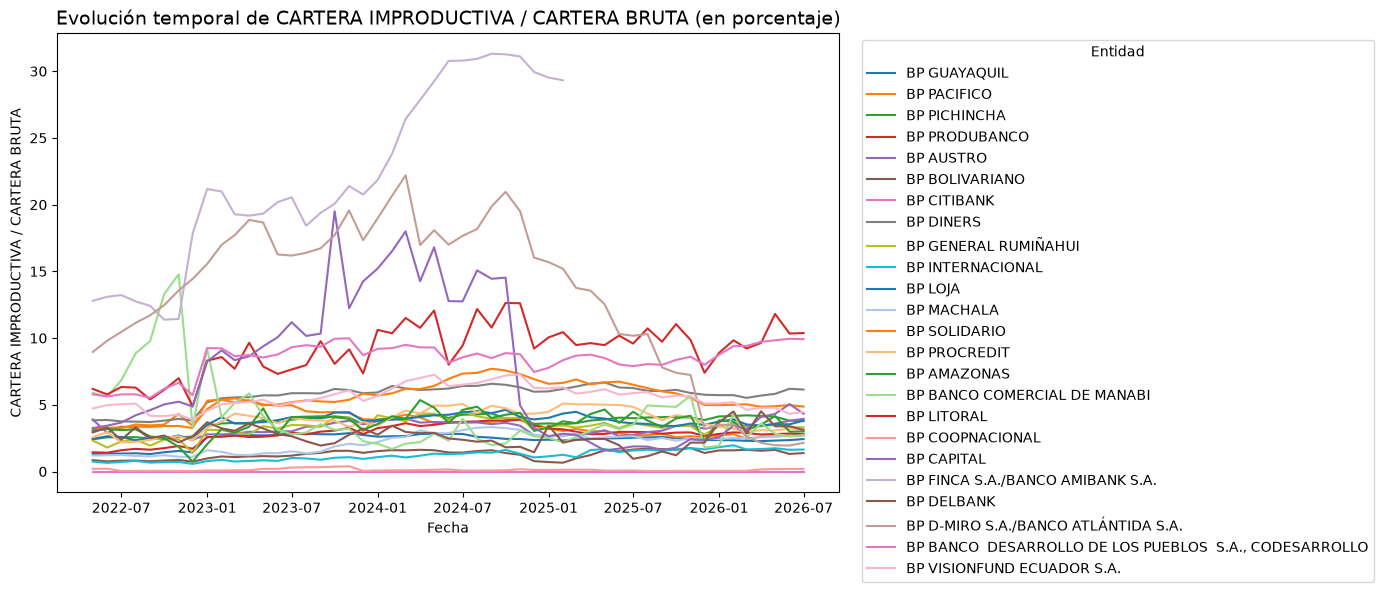

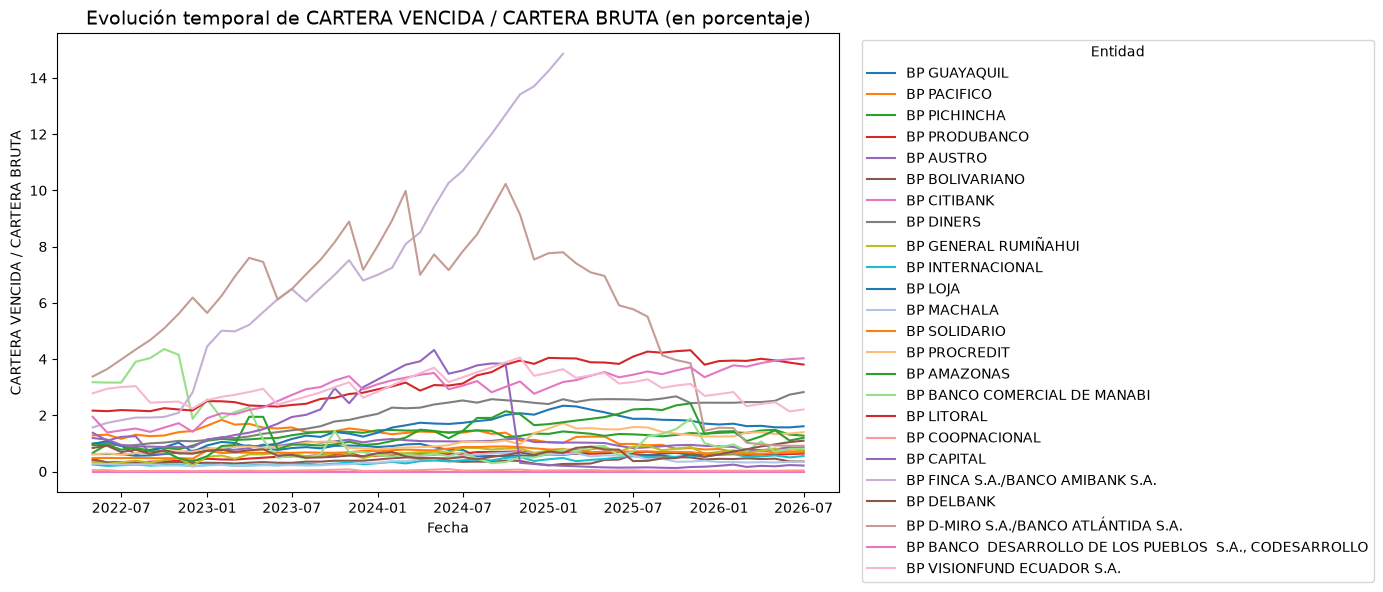

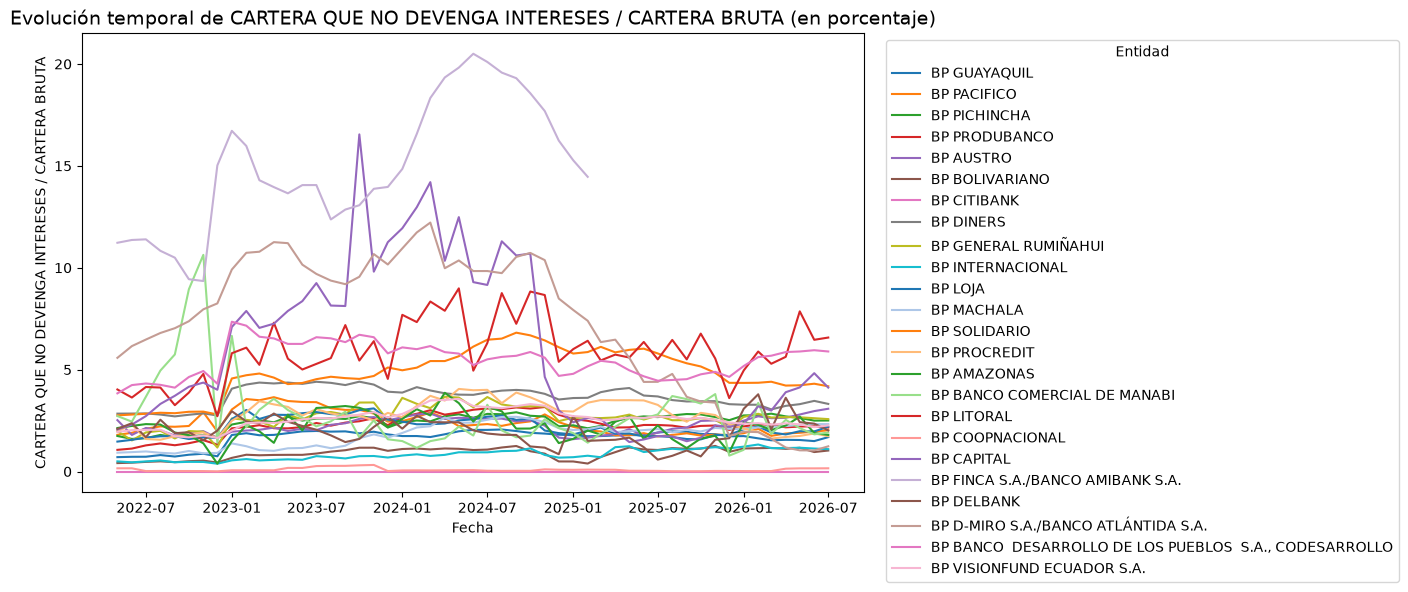

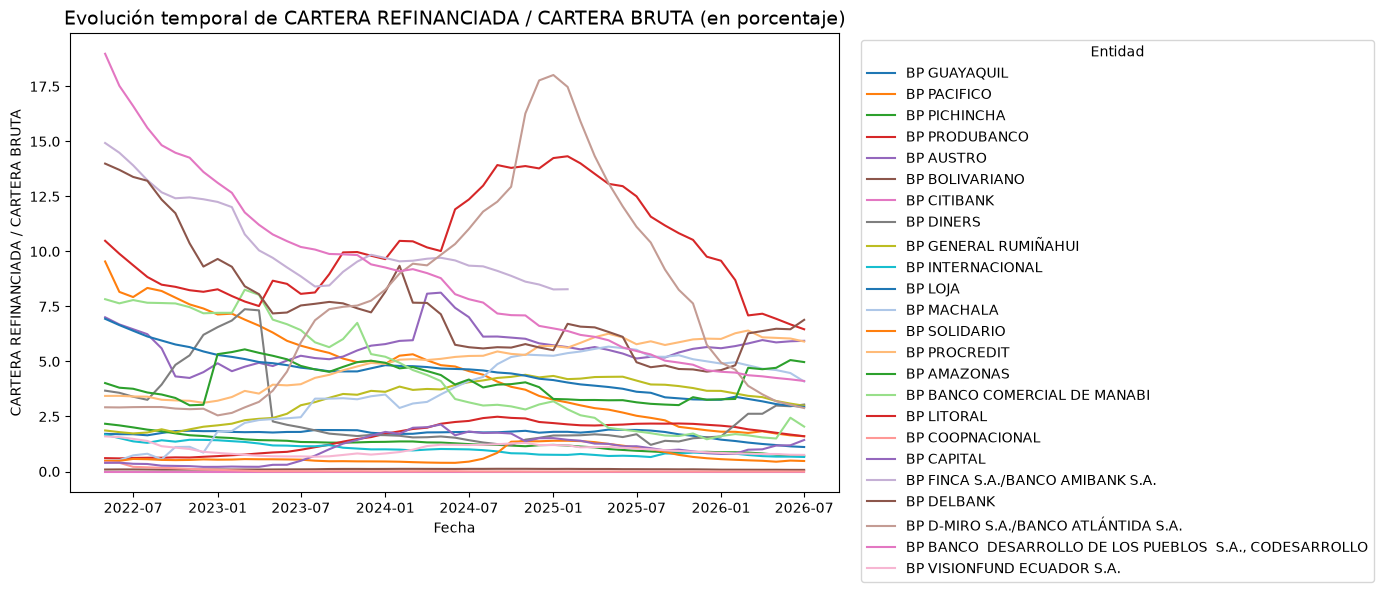

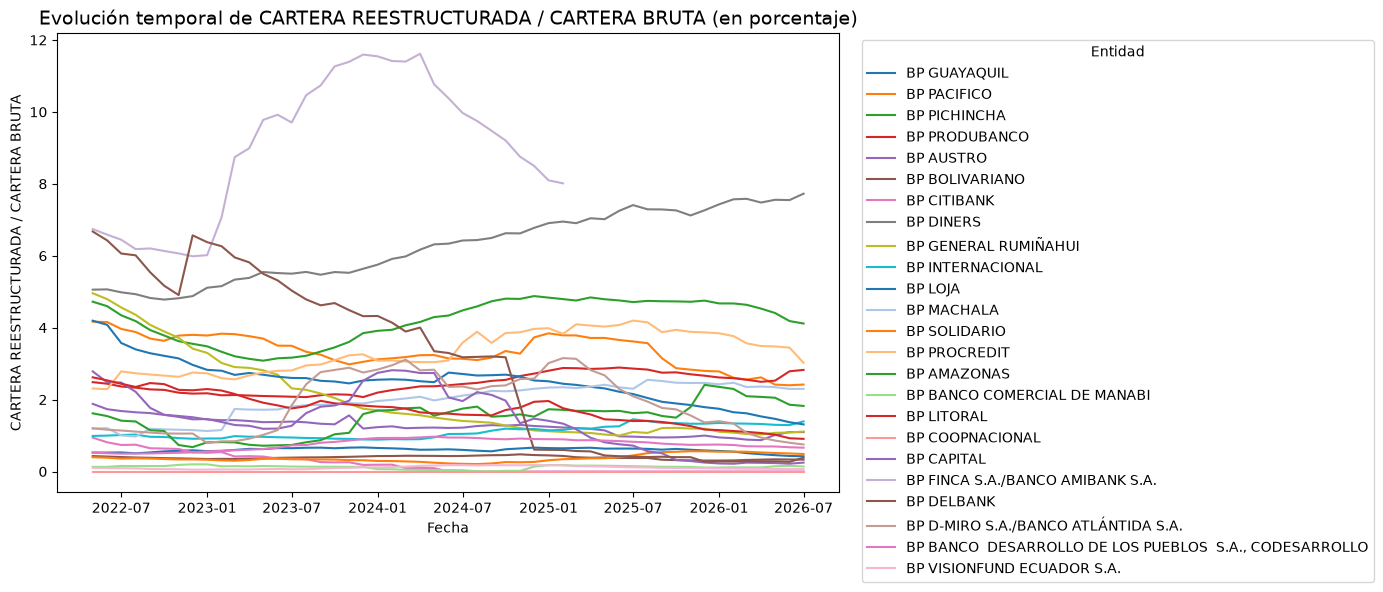

In [56]:
eda.graficar_indicadores(
    base_final,
    indicadores_cartera,
    carpeta="graficas_EDA_indicadores_financieros",
    indicadores_notebook=indicadores_notebook
)


Las series temporales muestran que, aunque la dirección deseable de estos indicadores corresponde a valores bajos, existen diferencias importantes entre las entidades. Algunas instituciones presentan niveles considerablemente superiores al resto, particularmente en los indicadores de cartera improductiva, cartera vencida y cartera que no devenga intereses. Sin embargo, los valores observados se mantienen por debajo del 100%, por lo que no se evidencian valores extremos en términos del rango porcentual de la razón. La principal característica identificada es la heterogeneidad entre entidades y la presencia de episodios de incremento en determinados períodos, lo que refleja diferentes niveles y dinámicas de riesgo y calidad de cartera.

Respecto a la cartera improductiva/cartera bruta (que no genera ingresos) destaca BP FINCA S.A./BANCO AMIBANK S.A., con valores superiores al 30%, mientras que otras entidades mantienen niveles considerablemente menores. En cartera vencida/cartera bruta también existe heterogeneidad. BP FINCA S.A./BANCO AMIBANK S.A. presenta una trayectoria creciente que alcanza aproximadamente 15%, mientras BP D-MIRO S.A./BANCO ATLÁNTIDA S.A. registra episodios cercanos al 10%.
En Cartera reestructurada / Cartera Bruta, BP FINCA S.A./BANCO AMIBANK S.A. presenta los niveles más elevados, alcanzando aproximadamente 11–12%, mientras que BP DINERS muestra una trayectoria creciente que llega a cerca del 7–8%.

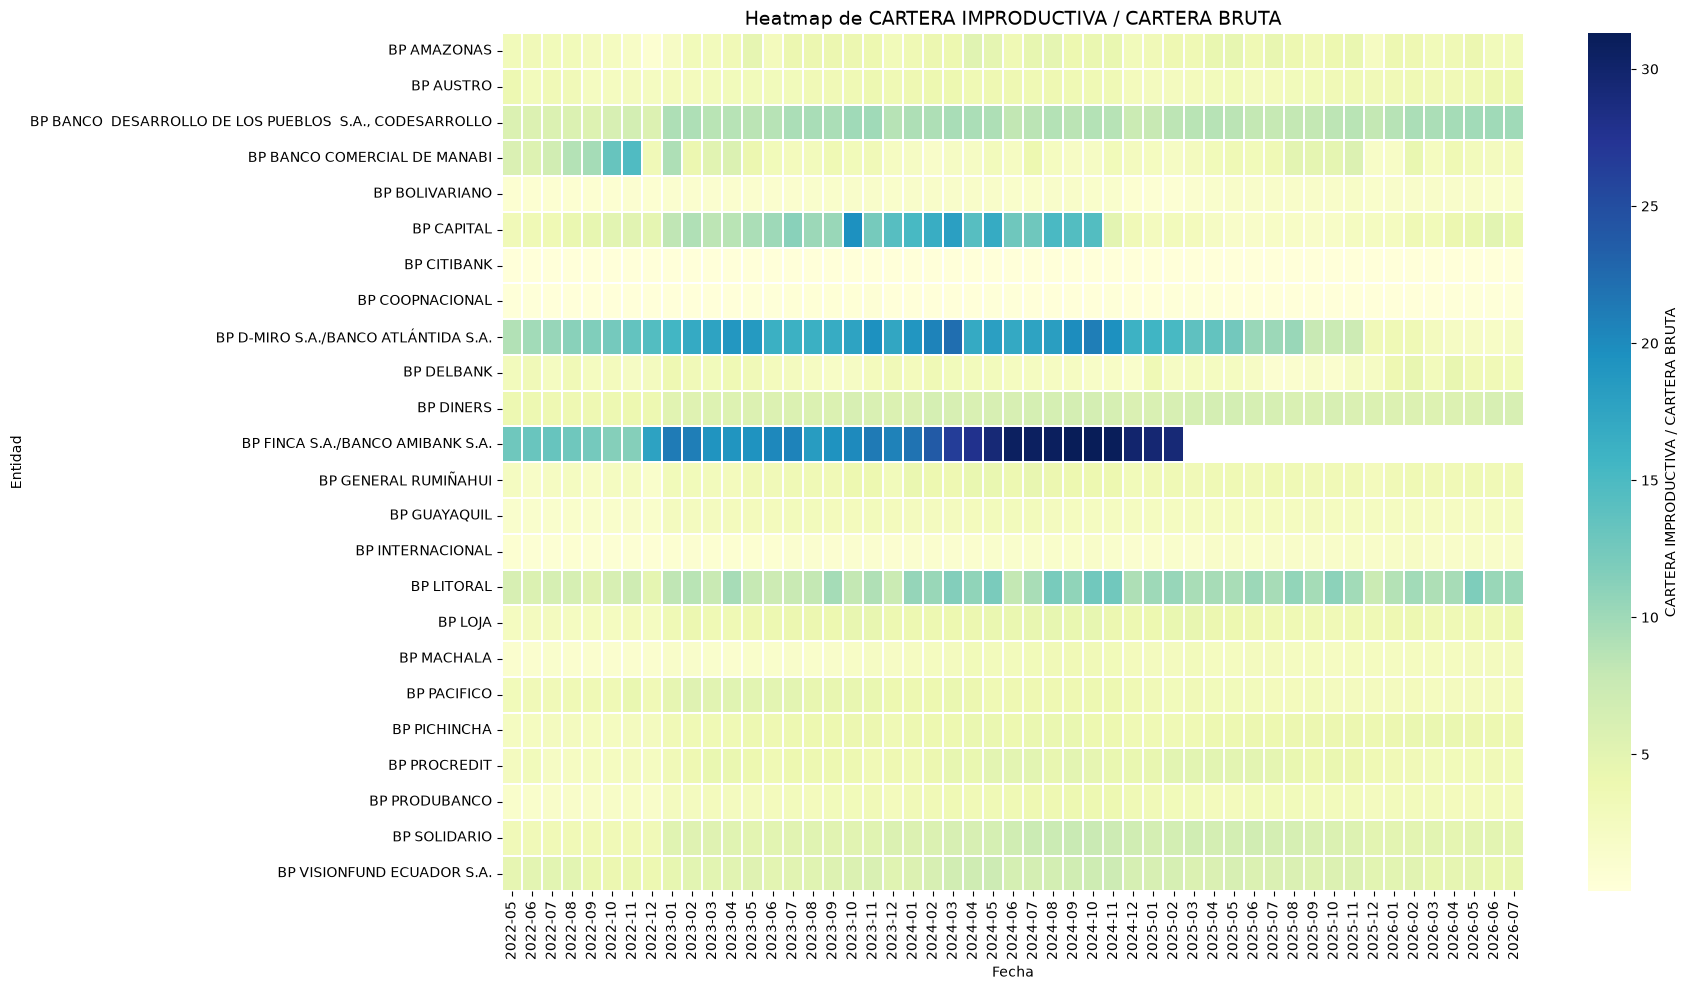

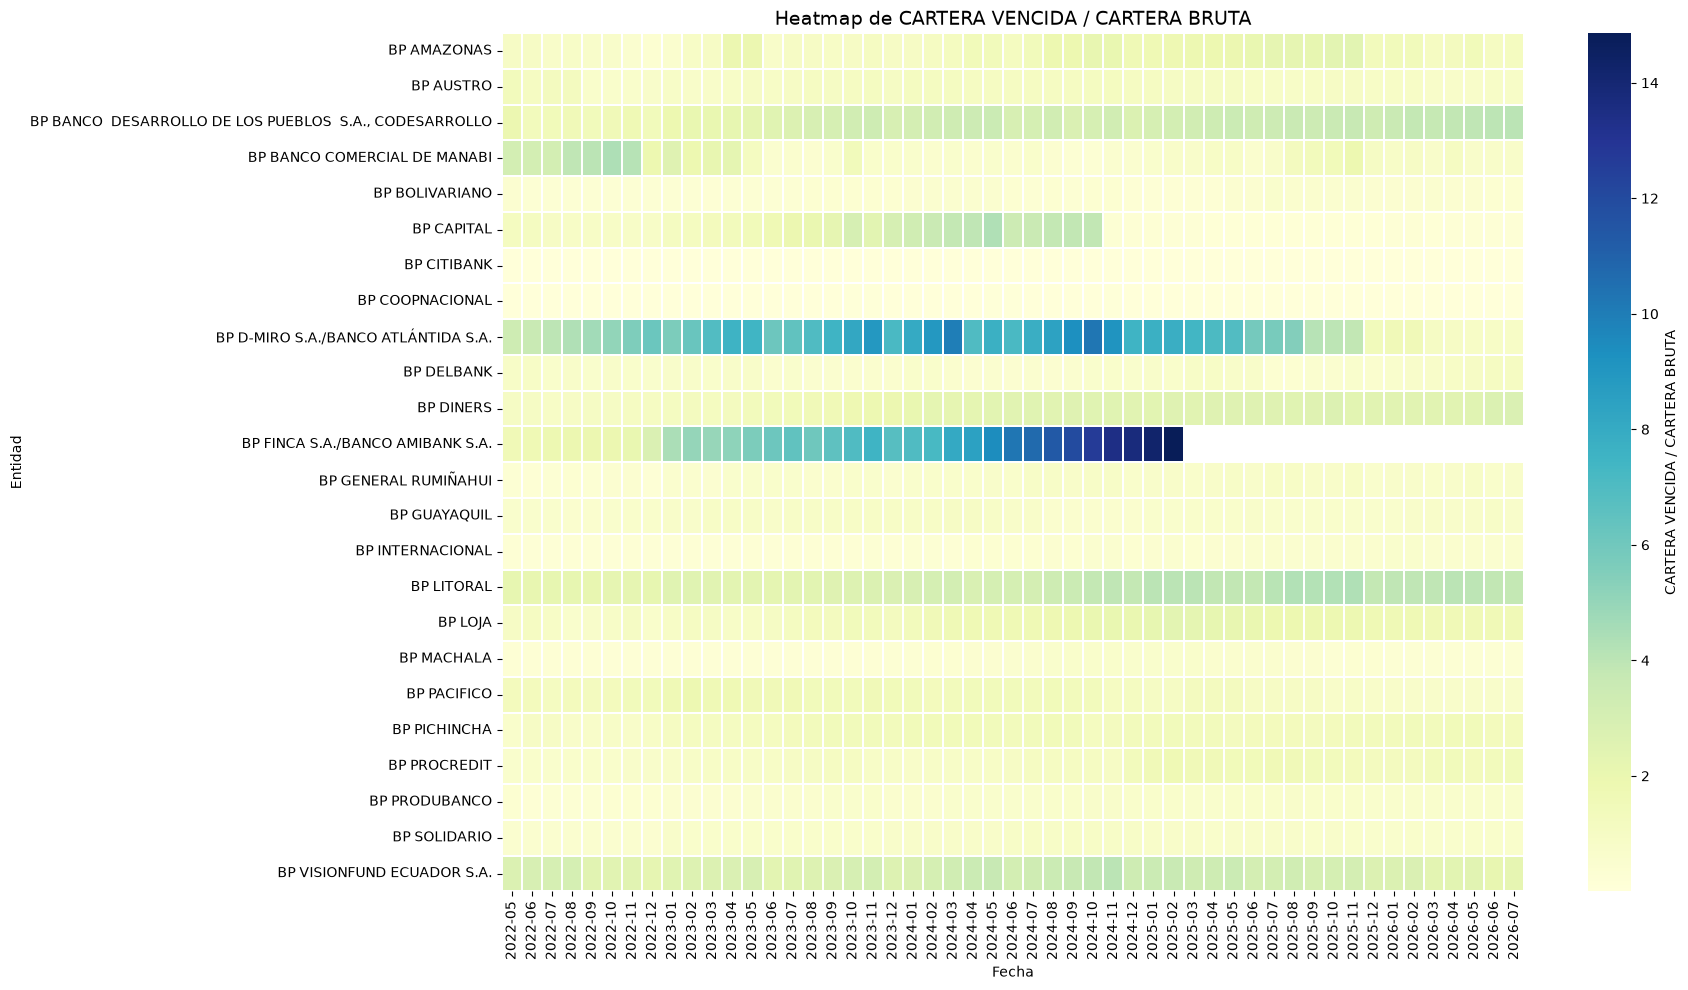

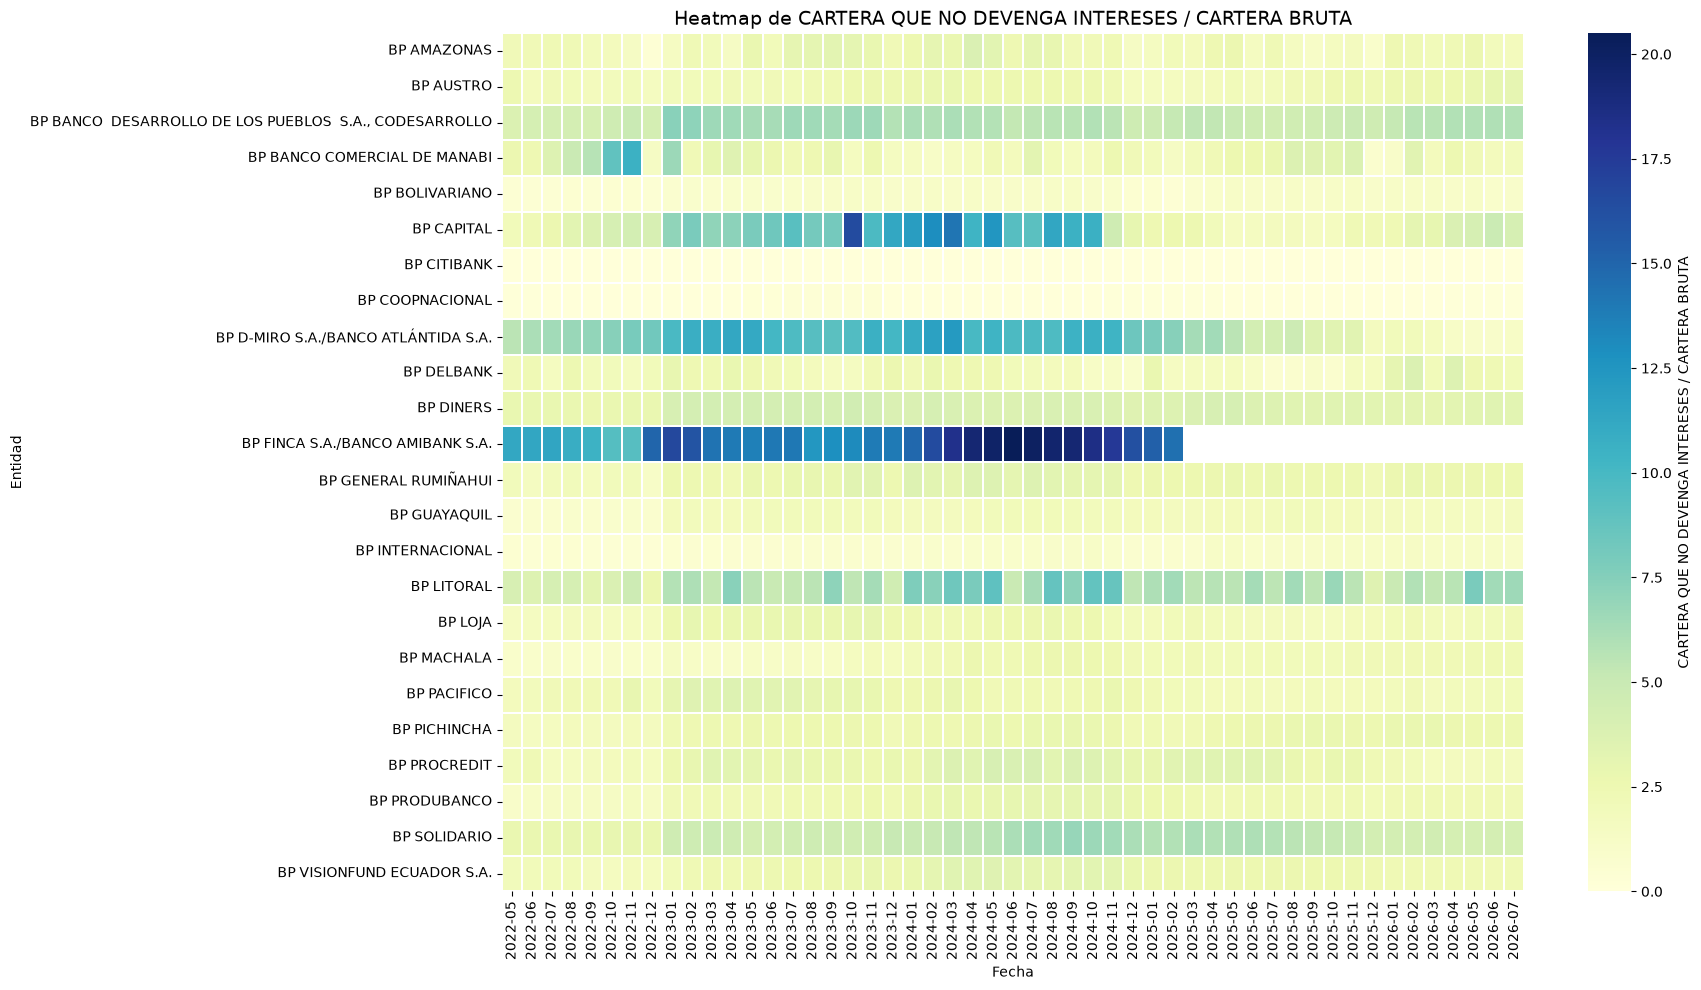

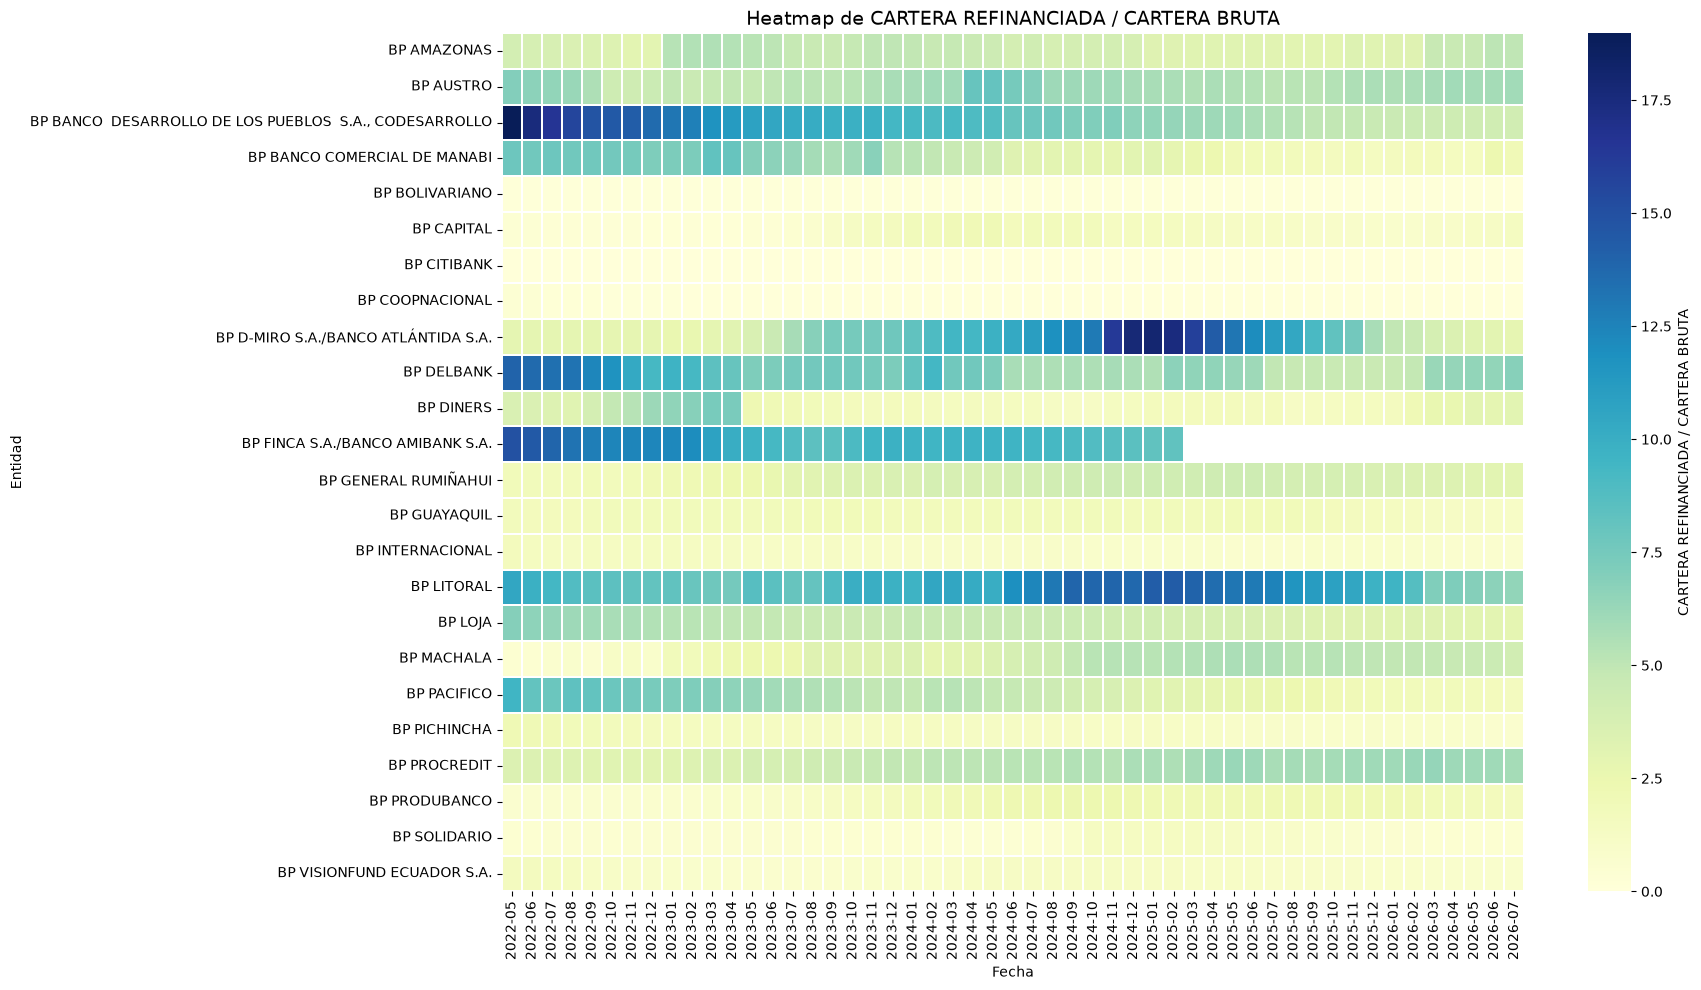

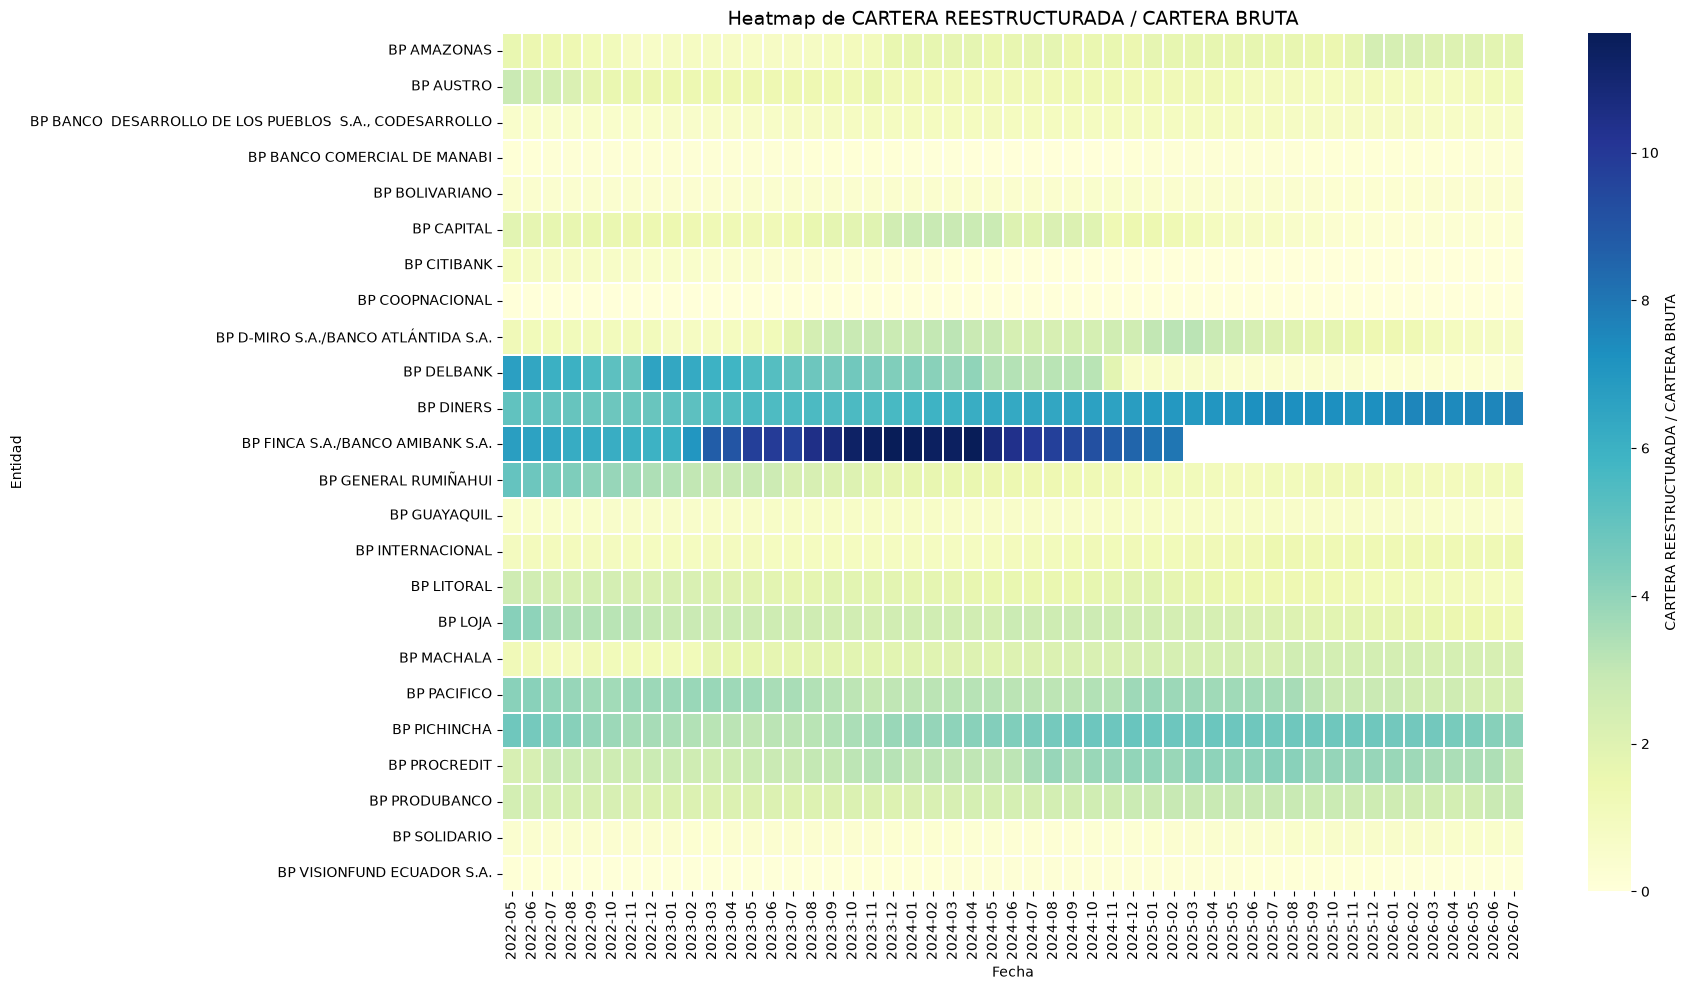

In [57]:
eda.generar_heatmaps(base_final, indicadores_cartera, indicadores_notebook=indicadores_notebook, carpeta="graficas_EDA_indicadores_financieros")

Los heatmaps evidencian una marcada heterogeneidad entre las entidades bancarias y a lo largo del período analizado. En general, predominan valores relativamente bajos; sin embargo, se identifican entidades que mantienen niveles elevados o presentan incrementos importantes durante determinados períodos. En particular, BP FINCA S.A./BANCO AMIBANK S.A. presenta niveles persistentemente altos de cartera improductiva y cartera que no devenga intereses, alcanzando aproximadamente 30% y 20%, respectivamente, durante varios períodos. De igual manera, BP D-MIRO S.A./BANCO ATLÁNTIDA S.A. registra valores elevados y sostenidos en estos indicadores, especialmente entre 2023 y 2025. Para la cartera vencida, nuevamente destacan estas dos entidades, con BP FINCA S.A./BANCO AMIBANK S.A. alcanzando valores cercanos al 15%. En cuanto a la cartera refinanciada, se observan niveles particularmente elevados en BP BANCO DESARROLLO DE LOS PUEBLOS S.A., CODESARROLLO, BP D-MIRO S.A./BANCO ATLÁNTIDA S.A., BP DELBANK y BP LITORAL. Finalmente, la cartera reestructurada presenta mayores niveles en BP FINCA S.A./BANCO AMIBANK S.A. y BP DINERS. En conjunto, los patrones observados muestran que el deterioro y la composición de la cartera no se distribuyen de manera homogénea entre las entidades, sino que existen perfiles diferenciados y persistencia temporal en determinados casos.

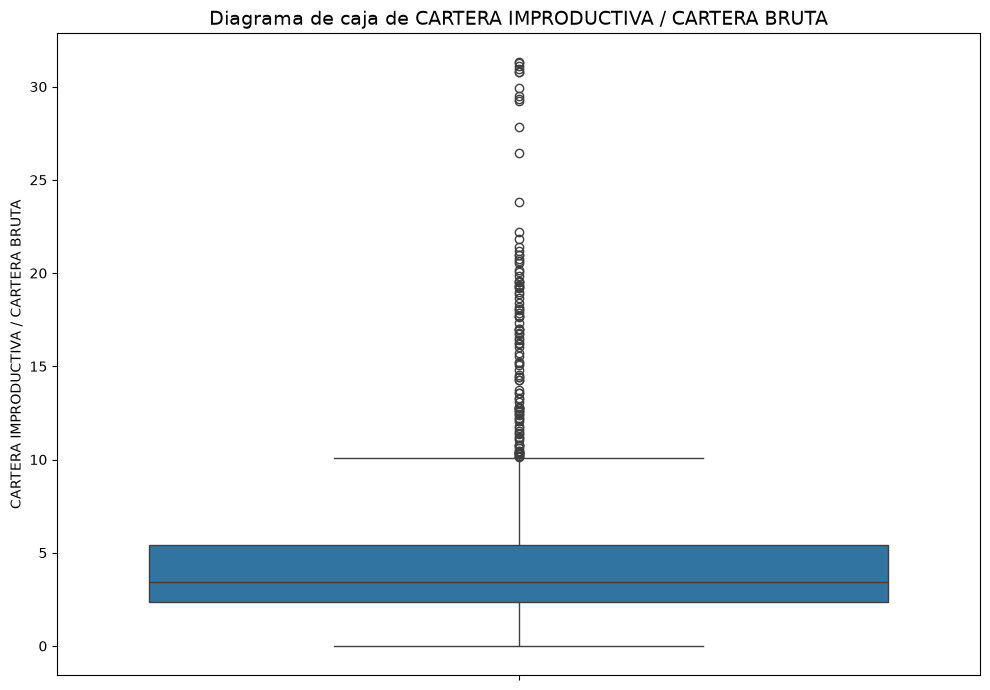

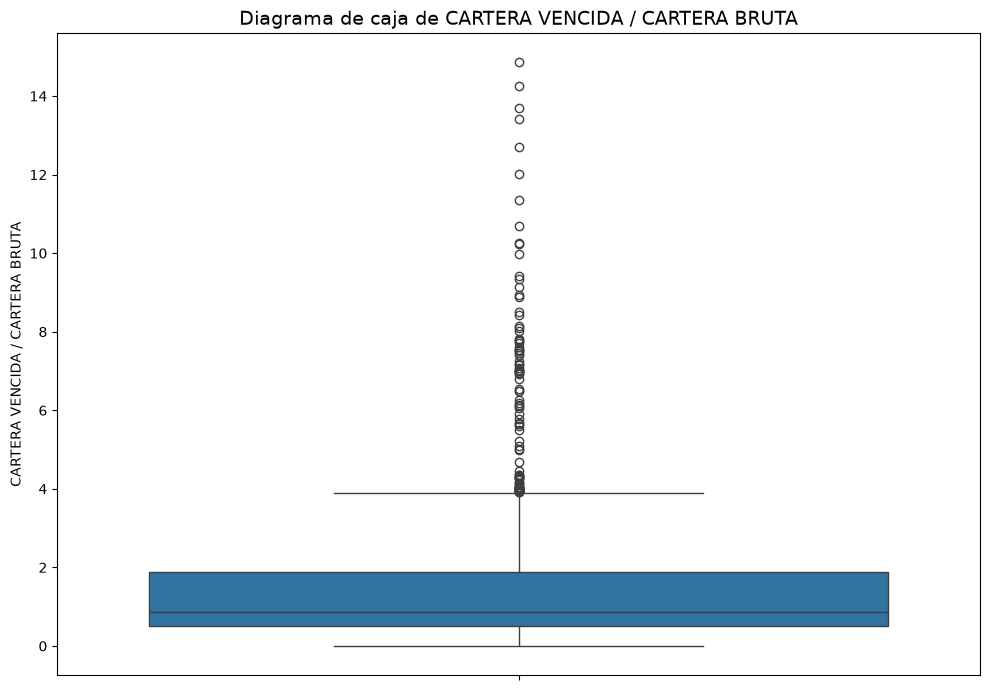

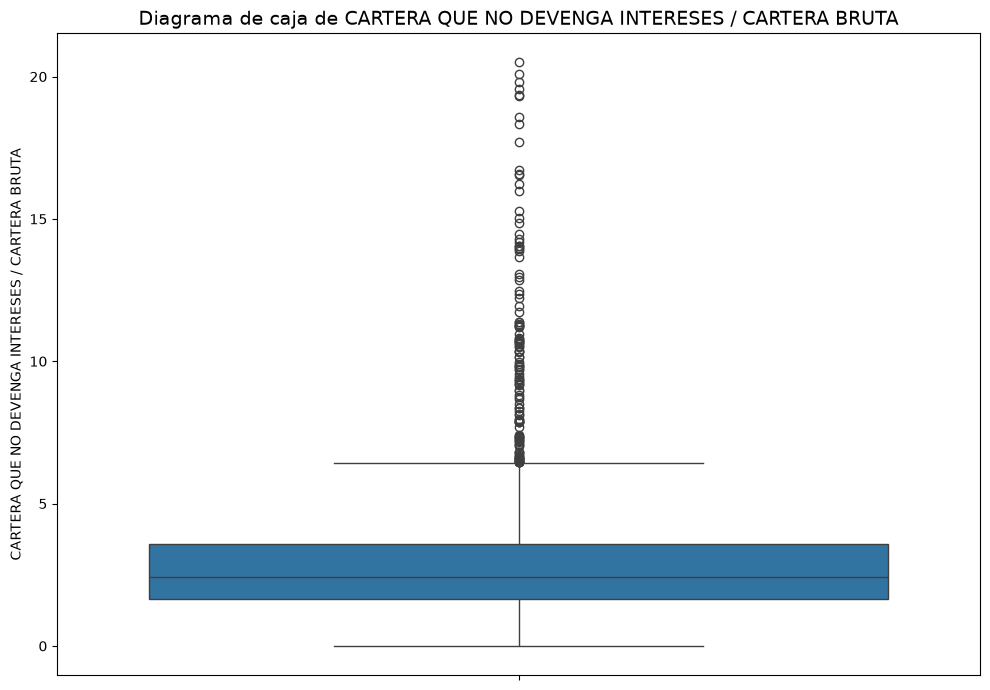

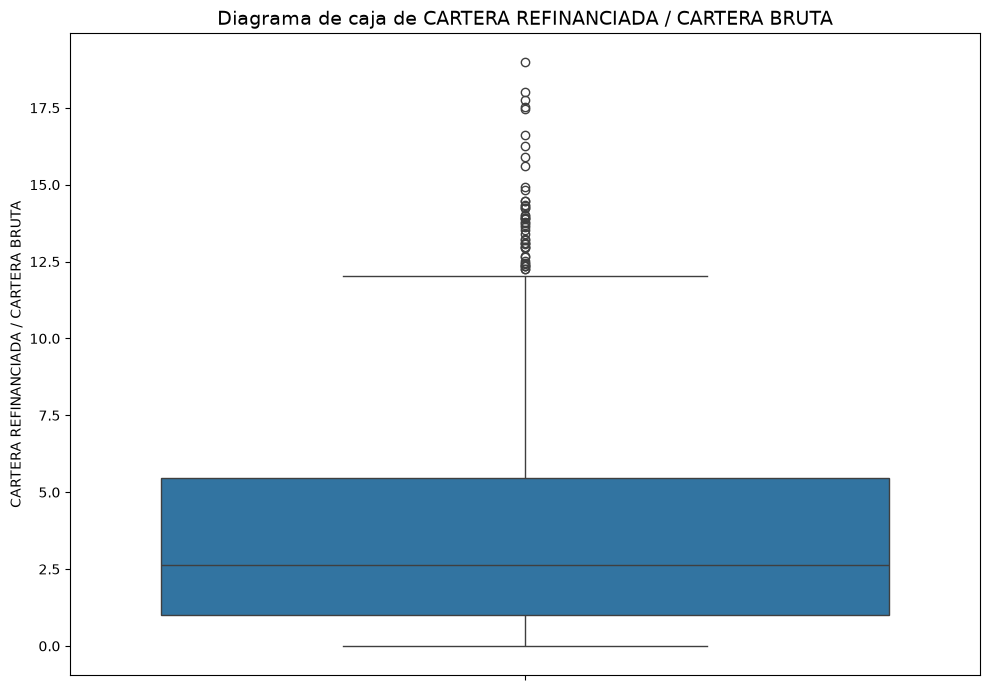

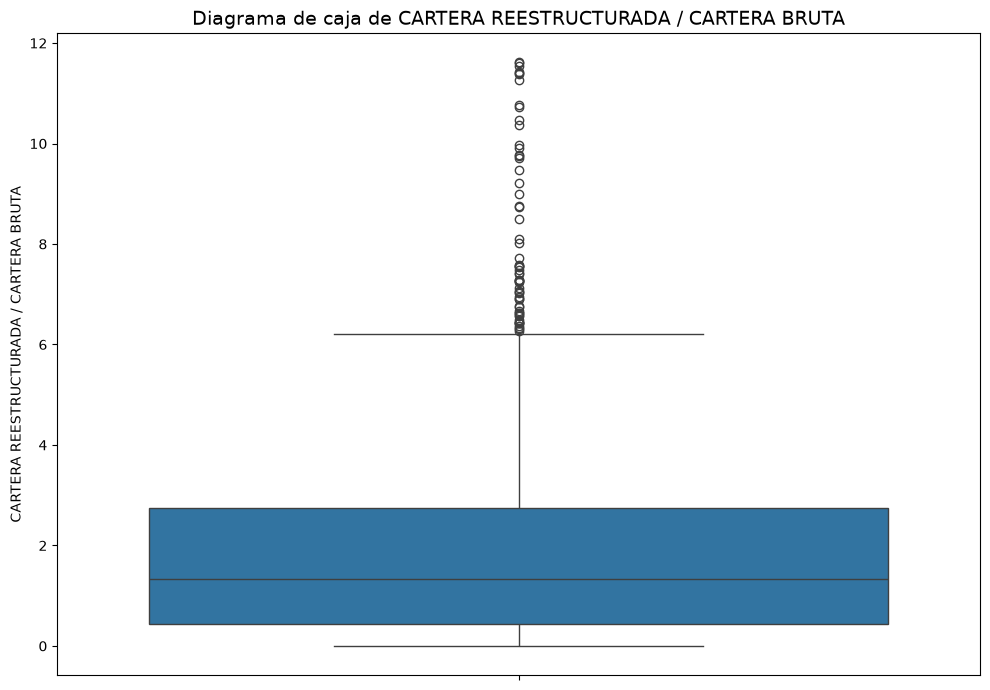

In [58]:
eda.generar_boxplots(base_final, indicadores_cartera, indicadores_notebook=indicadores_notebook, carpeta="graficas_EDA_indicadores_financieros")

Los diagramas de caja evidencian la presencia de numerosos valores atípicos por encima del límite superior definido mediante el criterio de $Q3 + 1.5 \times IQR$ en los cinco indicadores analizados. Esta concentración de observaciones por encima del bigote superior confirma una distribución con asimetría hacia valores elevados, particularmente en indicadores cuya dirección deseable corresponde a valores bajos. La mayor dispersión se observa en la cartera improductiva, donde se identifican valores atípicos que superan el 30%, seguida de la cartera que no devenga intereses, con valores superiores al 20%. Asimismo, la cartera refinanciada presenta valores atípicos cercanos al 19%, mientras que la cartera vencida alcanza aproximadamente el 15% y la cartera reestructurada supera el 11%. Estos resultados evidencian la existencia de observaciones extremas que corresponden a períodos y entidades con niveles relativamente elevados respecto al comportamiento general de la muestra.

In [71]:
tabla_atipicos = eda.detectar_atipicos_iqr(
    base_final,
    indicadores_cartera
)

In [72]:
conteo_atipicos = pd.pivot_table(
    tabla_atipicos,
    index=["ENTIDAD", "INDICADOR"],
    columns="TIPO_ATIPICO",
    values="FECHA",
    aggfunc="count",
    fill_value=0
).reset_index()

# Total de atípicos
conteo_atipicos["TOTAL_ATIPICOS"] = (
    conteo_atipicos.get("Inferior", 0)
    + conteo_atipicos.get("Superior", 0)
)

# Ordenar de mayor a menor
conteo_atipicos = conteo_atipicos.sort_values(
    "TOTAL_ATIPICOS",
    ascending=False
).reset_index(drop=True)


In [73]:
# Número de valores no nulos por entidad e indicador
total_valores = (
    base_final
    .groupby("ENTIDAD")[indicadores_cartera]
    .count()
    .reset_index()
    .melt(
        id_vars="ENTIDAD",
        var_name="INDICADOR",
        value_name="TOTAL_VALORES"
    )
)

# Unir con tabla de atípicos
atipicos_f = conteo_atipicos.merge(
    total_valores,
    on=["ENTIDAD", "INDICADOR"],
    how="left"
)

# Porcentaje de valores atípicos problemáticos
atipicos_f["PORC_ATIPICOS_SUP"] = (
    atipicos_f["Superior"]
    / atipicos_f["TOTAL_VALORES"]
    * 100
)

In [74]:
atipicos_f

,ENTIDAD,INDICADOR,Superior,TOTAL_ATIPICOS,TOTAL_VALORES,PORC_ATIPICOS_SUP
0,BP D-MIRO S.A./BANCO ATLÁNTIDA S.A.,CARTERA VENCIDA / CARTERA BRUTA,40,40,51,78.431373
1,BP D-MIRO S.A./BANCO ATLÁNTIDA S.A.,CARTERA IMPRODUCTIVA / CARTERA BRUTA,38,38,51,74.509804
2,BP FINCA S.A./BANCO AMIBANK S.A.,CARTERA IMPRODUCTIVA / CARTERA BRUTA,34,34,34,100.000000
3,BP FINCA S.A./BANCO AMIBANK S.A.,CARTERA QUE NO DEVENGA INTERESES / CARTERA BRUTA,34,34,34,100.000000
4,BP D-MIRO S.A./BANCO ATLÁNTIDA S.A.,CARTERA QUE NO DEVENGA INTERESES / CARTERA BRUTA,33,33,51,64.705882
5,BP FINCA S.A./BANCO AMIBANK S.A.,CARTERA REESTRUCTURADA / CARTERA BRUTA,28,28,34,82.352941
6,BP DINERS,CARTERA REESTRUCTURADA / CARTERA BRUTA,27,27,51,52.941176
7,BP FINCA S.A./BANCO AMIBANK S.A.,CARTERA VENCIDA / CARTERA BRUTA,26,26,34,76.470588
8,BP CAPITAL,CARTERA QUE NO DEVENGA INTERESES / CARTERA BRUTA,22,22,51,43.137255
9,BP CAPITAL,CARTERA IMPRODUCTIVA / CARTERA BRUTA,16,16,51,31.372549


In [75]:
atipicos_f = atipicos_f.sort_values(
    "PORC_ATIPICOS_SUP",
    ascending=False
)

In [76]:
atipicos_f

,ENTIDAD,INDICADOR,Superior,TOTAL_ATIPICOS,TOTAL_VALORES,PORC_ATIPICOS_SUP
2,BP FINCA S.A./BANCO AMIBANK S.A.,CARTERA IMPRODUCTIVA / CARTERA BRUTA,34,34,34,100.000000
3,BP FINCA S.A./BANCO AMIBANK S.A.,CARTERA QUE NO DEVENGA INTERESES / CARTERA BRUTA,34,34,34,100.000000
5,BP FINCA S.A./BANCO AMIBANK S.A.,CARTERA REESTRUCTURADA / CARTERA BRUTA,28,28,34,82.352941
0,BP D-MIRO S.A./BANCO ATLÁNTIDA S.A.,CARTERA VENCIDA / CARTERA BRUTA,40,40,51,78.431373
7,BP FINCA S.A./BANCO AMIBANK S.A.,CARTERA VENCIDA / CARTERA BRUTA,26,26,34,76.470588
1,BP D-MIRO S.A./BANCO ATLÁNTIDA S.A.,CARTERA IMPRODUCTIVA / CARTERA BRUTA,38,38,51,74.509804
4,BP D-MIRO S.A./BANCO ATLÁNTIDA S.A.,CARTERA QUE NO DEVENGA INTERESES / CARTERA BRUTA,33,33,51,64.705882
6,BP DINERS,CARTERA REESTRUCTURADA / CARTERA BRUTA,27,27,51,52.941176
8,BP CAPITAL,CARTERA QUE NO DEVENGA INTERESES / CARTERA BRUTA,22,22,51,43.137255
9,BP CAPITAL,CARTERA IMPRODUCTIVA / CARTERA BRUTA,16,16,51,31.372549


El análisis mediante el criterio de $Q3+1,5\times IQR$ evidencia una concentración de valores atípicos superiores en determinadas entidades, particularmente en Banco Amibank, Banco D-MIRO S.A./Banco Atlántida y Banco Diners Club. En el caso de Amibank, la elevada frecuencia de atípicos en cartera improductiva, cartera que no devenga intereses y cartera vencida es consistente con los elevados niveles de morosidad registrados por la entidad durante el período analizado. D-MIRO también presenta una concentración importante de observaciones atípicas asociadas con la calidad de su cartera, coherente con los niveles históricamente elevados de morosidad reportados por la institución. Por su parte, Diners destaca específicamente por la proporción de observaciones atípicas en cartera reestructurada, con 27 de 51 observaciones (52,94%). Este resultado debe interpretarse como una característica estadística diferenciada de la entidad y no necesariamente como una anomalía financiera, considerando su elevada especialización en cartera de consumo y la presencia de montos significativos de cartera reestructurada. En consecuencia, los valores atípicos identificados se conservarán para las etapas posteriores del análisis, dado que pueden representar características estructurales de las entidades y contribuir a la identificación de perfiles financieros diferenciados mediante las técnicas multivariadas.

### Análisis de Correlación

In [ ]:
indicador = "ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS"

heatmap_data = base_final.pivot_table(
    index="ENTIDAD",
    columns="FECHA",
    values=indicador,
    aggfunc="mean"
)

plt.figure(figsize=(18, 10))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.2,
    cbar_kws={"label": indicador}
)

plt.title(
    f"Heatmap de {indicador}",
    fontsize=14
)

plt.xlabel("Fecha")
plt.ylabel("Entidad")

# Mostrar solamente Año-Mes
plt.xticks(
    ticks=[i + 0.5 for i in range(len(heatmap_data.columns))],
    labels=heatmap_data.columns.strftime("%Y-%m"),
    rotation=90
)

plt.tight_layout()
plt.show()

In [ ]:
base_final

In [ ]:
indicador = "ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS"

entidades = base_final["ENTIDAD"].unique()

palette = sns.color_palette("tab20", n_colors=len(entidades))

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=base_final,
    x="FECHA",
    y=indicador,
    hue="ENTIDAD",
    palette=palette
)

plt.title(f"Evolución temporal de {indicador}")
plt.xlabel("Fecha")
plt.ylabel(indicador)

plt.legend(
    title="Entidad",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [ ]:
def graficar_boxplot(df, columna):

    datos = df[columna].dropna()

    plt.figure(figsize=(8, 4))
    plt.boxplot(datos, vert=False)

    plt.xlabel(columna)
    plt.title(f"Diagrama de caja: {columna}")

    plt.tight_layout()
    plt.show()

In [ ]:
graficar_boxplot(
    base_final,
    "ACTIVOS IMPRODUCTIVOS NETOS / TOTAL ACTIVOS"
)

## Indicadores de crecimiento 

| Variable | Significado | Límite / referencia | Interpretación | Dirección deseable |
| --- | --- | --- | --- | --- |
| **Crecimiento de activos totales** | Mide la variación porcentual interanual de los activos totales de la entidad. | No existe un límite regulatorio general. El **0%** representa ausencia de crecimiento. | Un valor **positivo** indica expansión de los activos; un valor **negativo** indica una contracción. Un crecimiento elevado puede reflejar expansión, pero también debe analizarse junto con la calidad y rentabilidad de los activos. | **Positivo y sostenible** |
| **Crecimiento de cartera de créditos** | Mide la variación porcentual interanual de la cartera de créditos. | No existe un límite regulatorio general. El **0%** representa estabilidad respecto al año anterior. | Un valor **positivo** indica expansión de la colocación de crédito; un valor **negativo** indica reducción de la cartera. Un crecimiento elevado puede representar mayor intermediación, pero debe analizarse conjuntamente con la morosidad y calidad de cartera. | **Positivo y sostenible** |
| **Crecimiento de depósitos a la vista** | Mide la variación porcentual interanual de los depósitos a la vista. | No existe un límite regulatorio general. El **0%** representa estabilidad. | Un valor **positivo** indica un incremento de los recursos captados a la vista; un valor **negativo** indica una disminución. Un crecimiento positivo fortalece la disponibilidad de fuentes de fondeo, aunque debe evaluarse su estabilidad. | **Positivo y sostenible** |
| **Crecimiento de depósitos a plazo** | Mide la variación porcentual interanual de los depósitos a plazo. | No existe un límite regulatorio general. El **0%** representa estabilidad. | Un valor **positivo** indica un aumento de las captaciones a plazo; un valor **negativo** indica una reducción. Un crecimiento positivo puede contribuir a fortalecer el fondeo, aunque implica considerar el costo financiero asociado. | **Positivo y sostenible** |
| **Crecimiento de patrimonio** | Mide la variación porcentual interanual del patrimonio de la entidad. | No existe un límite regulatorio general de crecimiento. El **0%** representa estabilidad. | Un valor **positivo** indica fortalecimiento patrimonial; un valor **negativo** indica una reducción del patrimonio. El crecimiento patrimonial sostenido contribuye a fortalecer la capacidad de absorción de pérdidas y respaldar la expansión de activos. | **Positivo y sostenible** |
| **Crecimiento de fondos disponibles** | Mide la variación porcentual interanual de los fondos disponibles. | No existe un límite regulatorio general de crecimiento. El **0%** representa estabilidad. | Un valor **positivo** indica un aumento de los recursos líquidos disponibles; un valor **negativo** indica una disminución. Un crecimiento positivo puede mejorar la posición de liquidez, aunque niveles excesivos podrían reflejar recursos con menor utilización productiva. | **Positivo, pero equilibrado** |
| **Crecimiento de inversiones** | Mide la variación porcentual interanual de las inversiones financieras de la entidad. | No existe un límite regulatorio general de crecimiento. El **0%** representa estabilidad. | Un valor **positivo** indica expansión de las inversiones; un valor **negativo** indica reducción. El crecimiento debe analizarse considerando su composición, rentabilidad, liquidez y riesgo. | **Positivo y sostenible** |

In [79]:
indicadores_balance=['VAR_FONDOS DISPONIBLES',	
                     'VAR_INVERSIONES',	'VAR_CARTERA DE CRÉDITOS',	
                     'VAR_TOTAL ACTIVO',	'VAR_Depósitos a la vista',
                    'VAR_Depósitos a plazo',	
                    'VAR_TOTAL PATRIMONIO']


In [80]:
indicadores_notebook = [
    'VAR_TOTAL ACTIVO',
    'VAR_CARTERA DE CRÉDITOS',
    'VAR_TOTAL PATRIMONIO'
]

Guardado: graficas_EDA_indicadores_financieros\VAR_FONDOS_DISPONIBLES.png
Guardado: graficas_EDA_indicadores_financieros\VAR_INVERSIONES.png


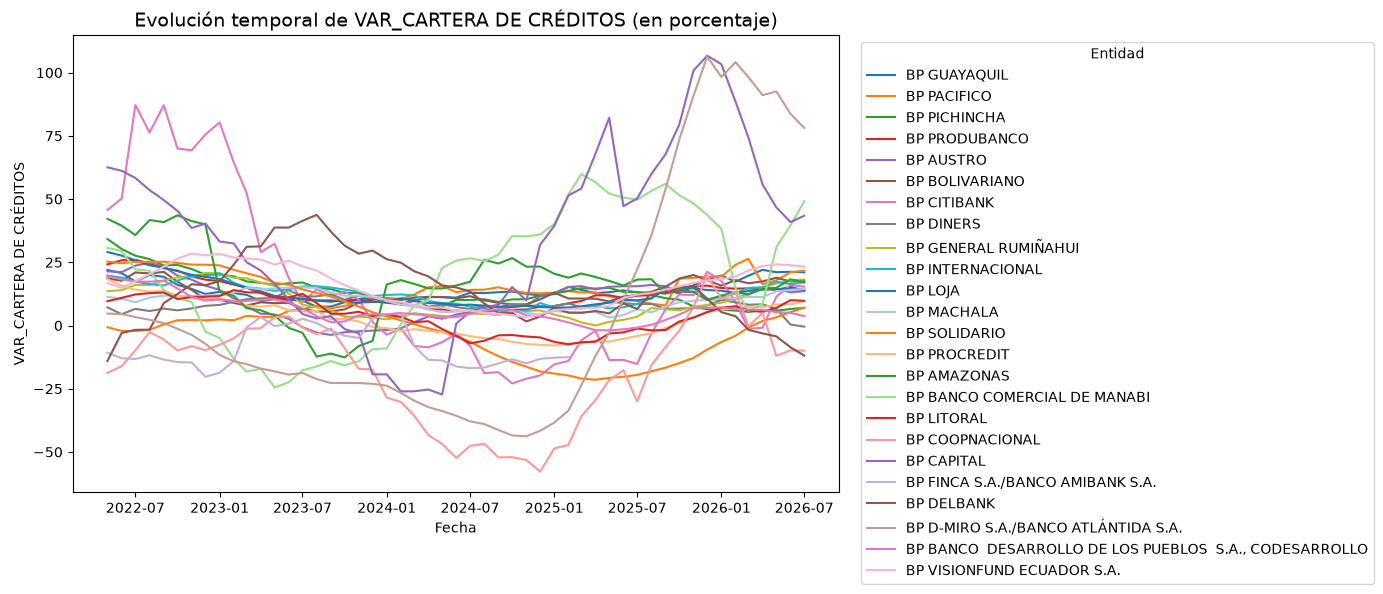

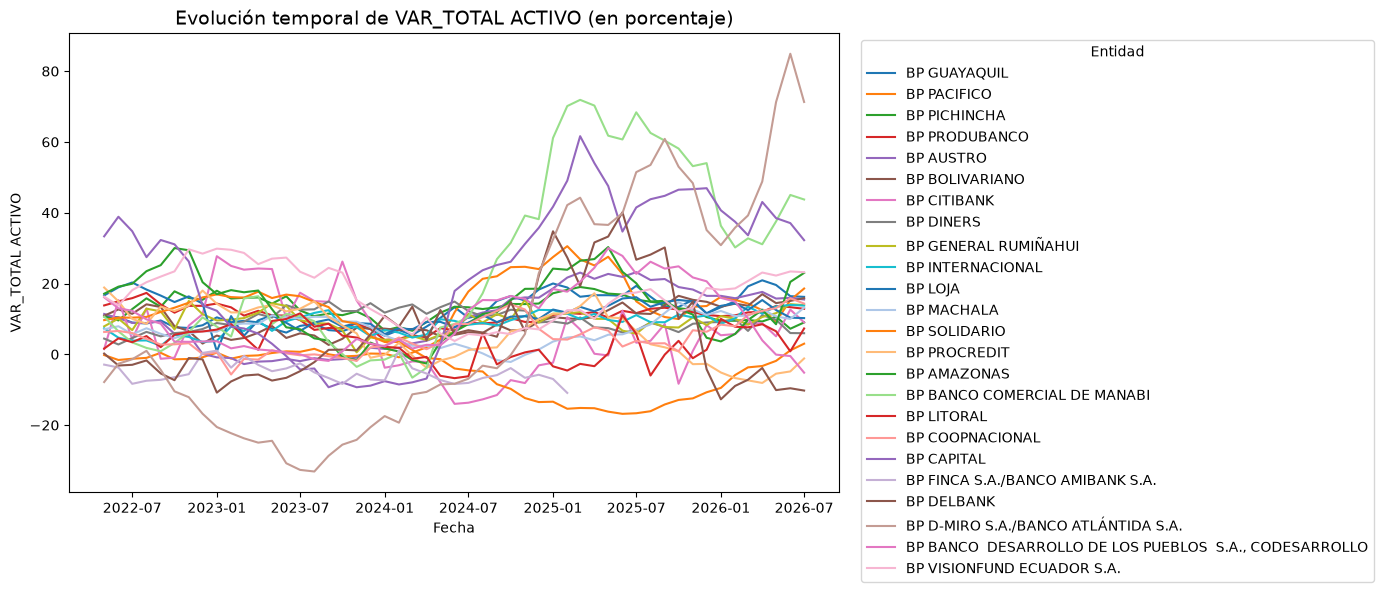

Guardado: graficas_EDA_indicadores_financieros\VAR_Depósitos_a_la_vista.png
Guardado: graficas_EDA_indicadores_financieros\VAR_Depósitos_a_plazo.png


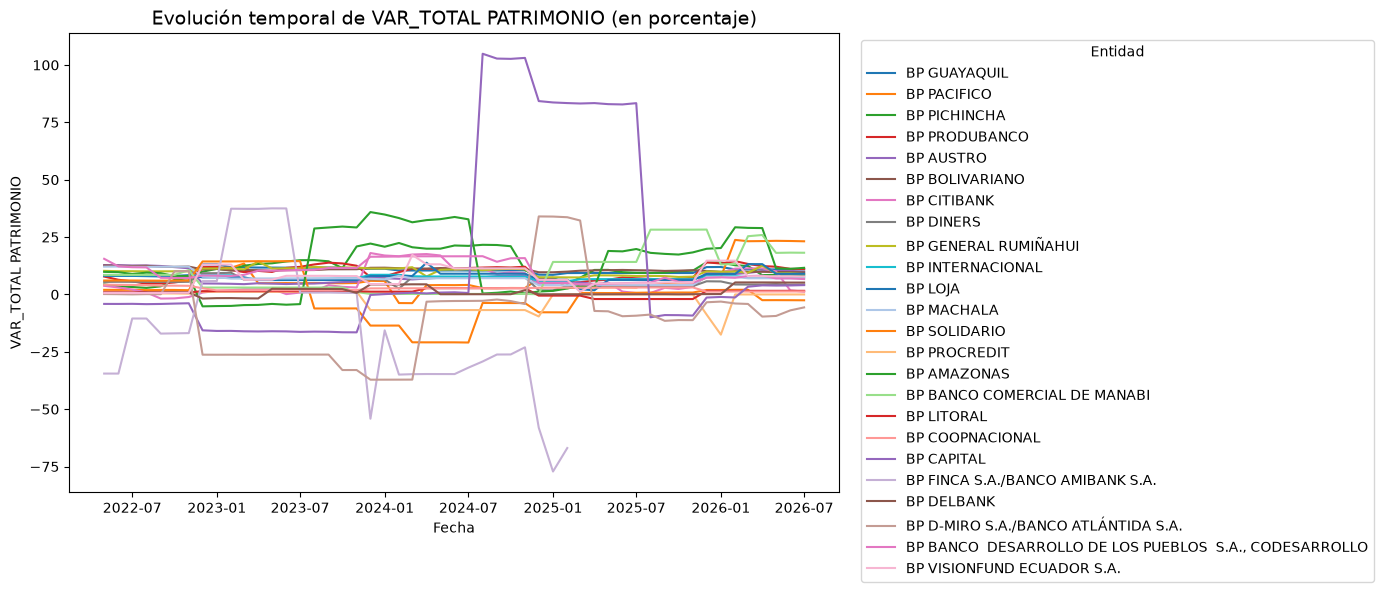

In [81]:
eda.graficar_indicadores(
    base_final,
    indicadores_balance,
    carpeta="graficas_EDA_indicadores_financieros",
    indicadores_notebook=indicadores_notebook
)


Las variables de crecimiento interanual evidencian una marcada heterogeneidad en la dinámica financiera de las entidades. Se identifican instituciones con trayectorias relativamente estables y variaciones moderadas, como BP Guayaquil, BP Pichincha, BP Produbanco, BP Internacional, BP Loja, BP Machala y BP General Rumiñahui, cuyos crecimientos de activos, cartera y patrimonio se mantienen generalmente dentro de rangos relativamente acotados durante el período analizado. En contraste, se observan entidades con mayor variabilidad, particularmente BP Capital, BP D-MIRO S.A./Banco Atlántida S.A., BP FINCA S.A./Banco Amibank S.A. y BP Banco Comercial de Manabí, que presentan períodos de expansión y contracción considerablemente más pronunciados. Asimismo, BP Citibank muestra episodios de crecimiento elevado en la cartera de créditos, mientras que BP Bolivariano presenta fluctuaciones importantes en determinados períodos. Los casos más extremos se observan en el crecimiento de cartera y activos, con tasas que superan el 100% en algunas entidades, y en el crecimiento patrimonial, donde se presentan variaciones tanto fuertemente positivas como negativas. En conjunto, estos resultados permiten identificar diferentes patrones de estabilidad y volatilidad financiera entre las entidades, constituyendo una característica relevante para la posterior reducción dimensional y conformación de perfiles mediante PCA y clustering.

Guardado: graficas_EDA_indicadores_financieros\heatmap_VAR_FONDOS_DISPONIBLES.png
Guardado: graficas_EDA_indicadores_financieros\heatmap_VAR_INVERSIONES.png


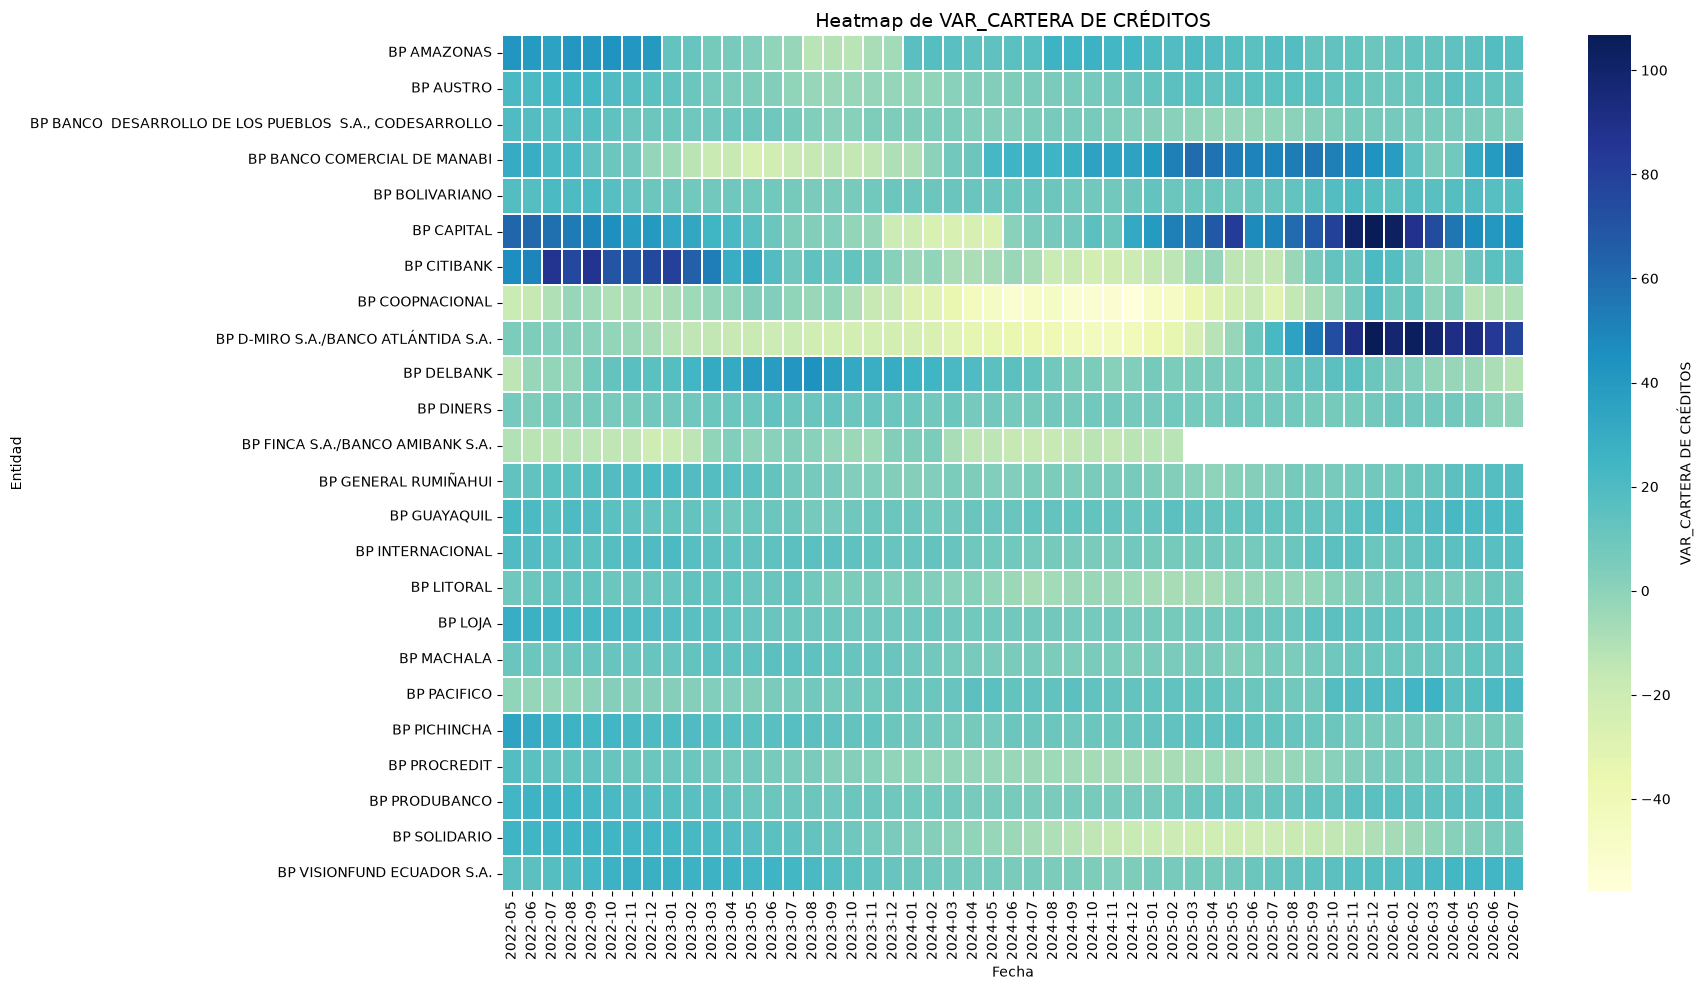

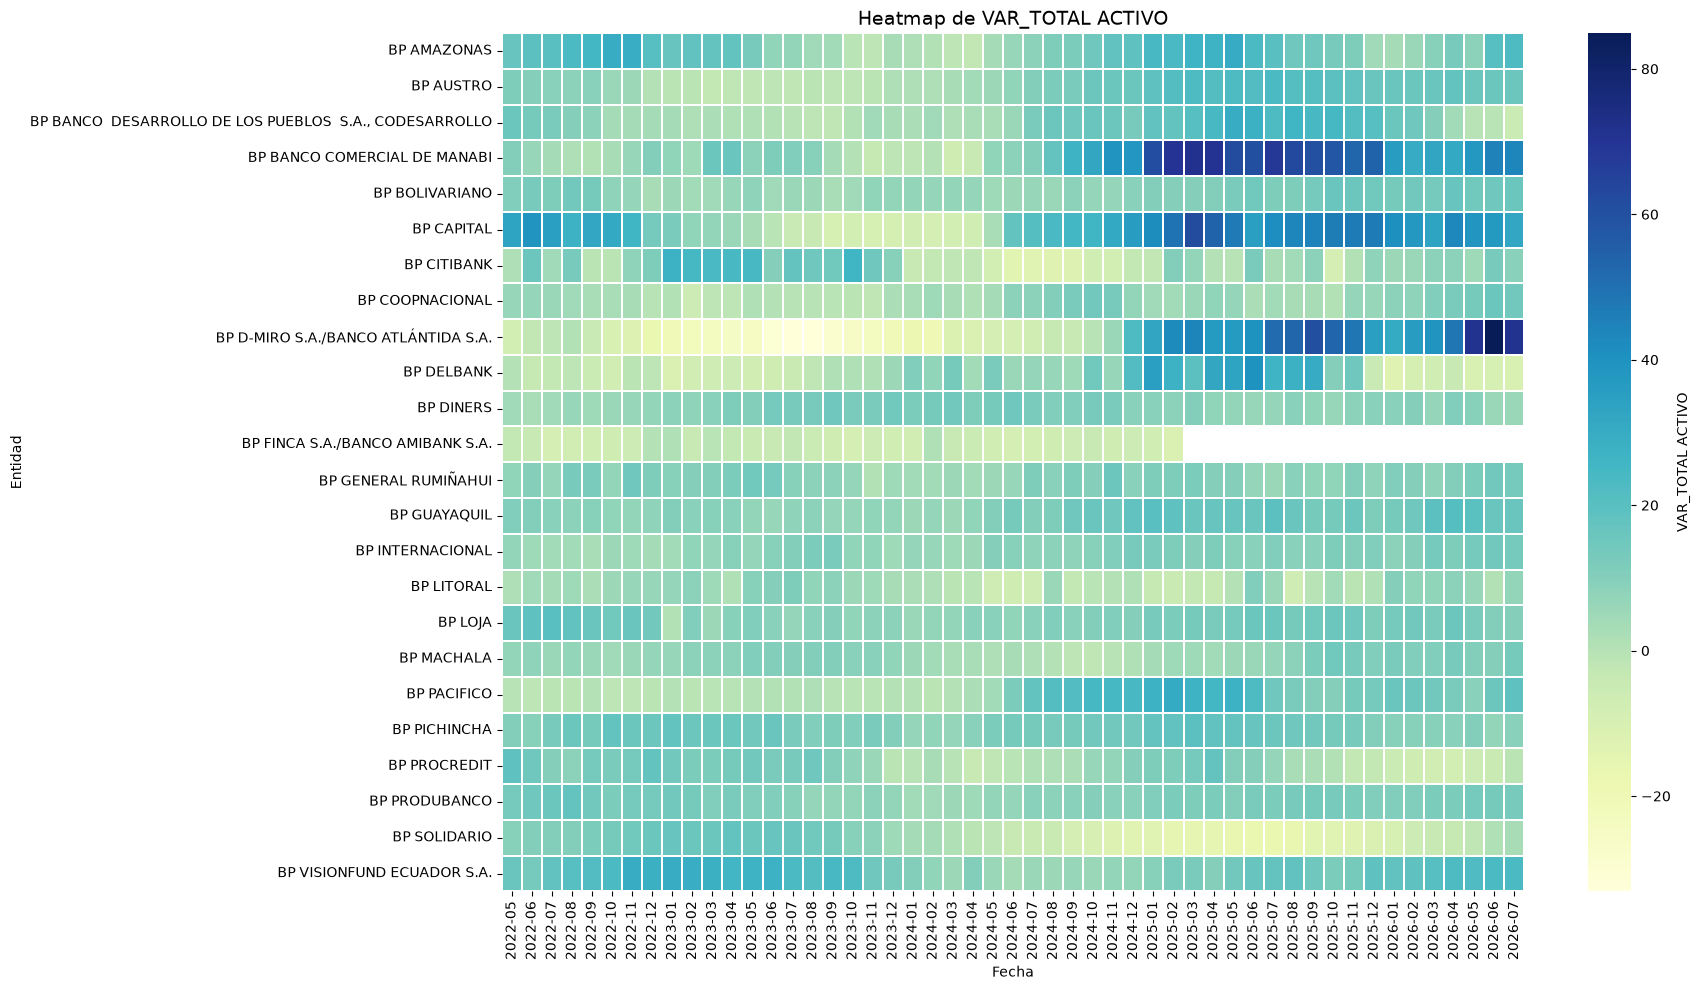

Guardado: graficas_EDA_indicadores_financieros\heatmap_VAR_Depósitos_a_la_vista.png
Guardado: graficas_EDA_indicadores_financieros\heatmap_VAR_Depósitos_a_plazo.png


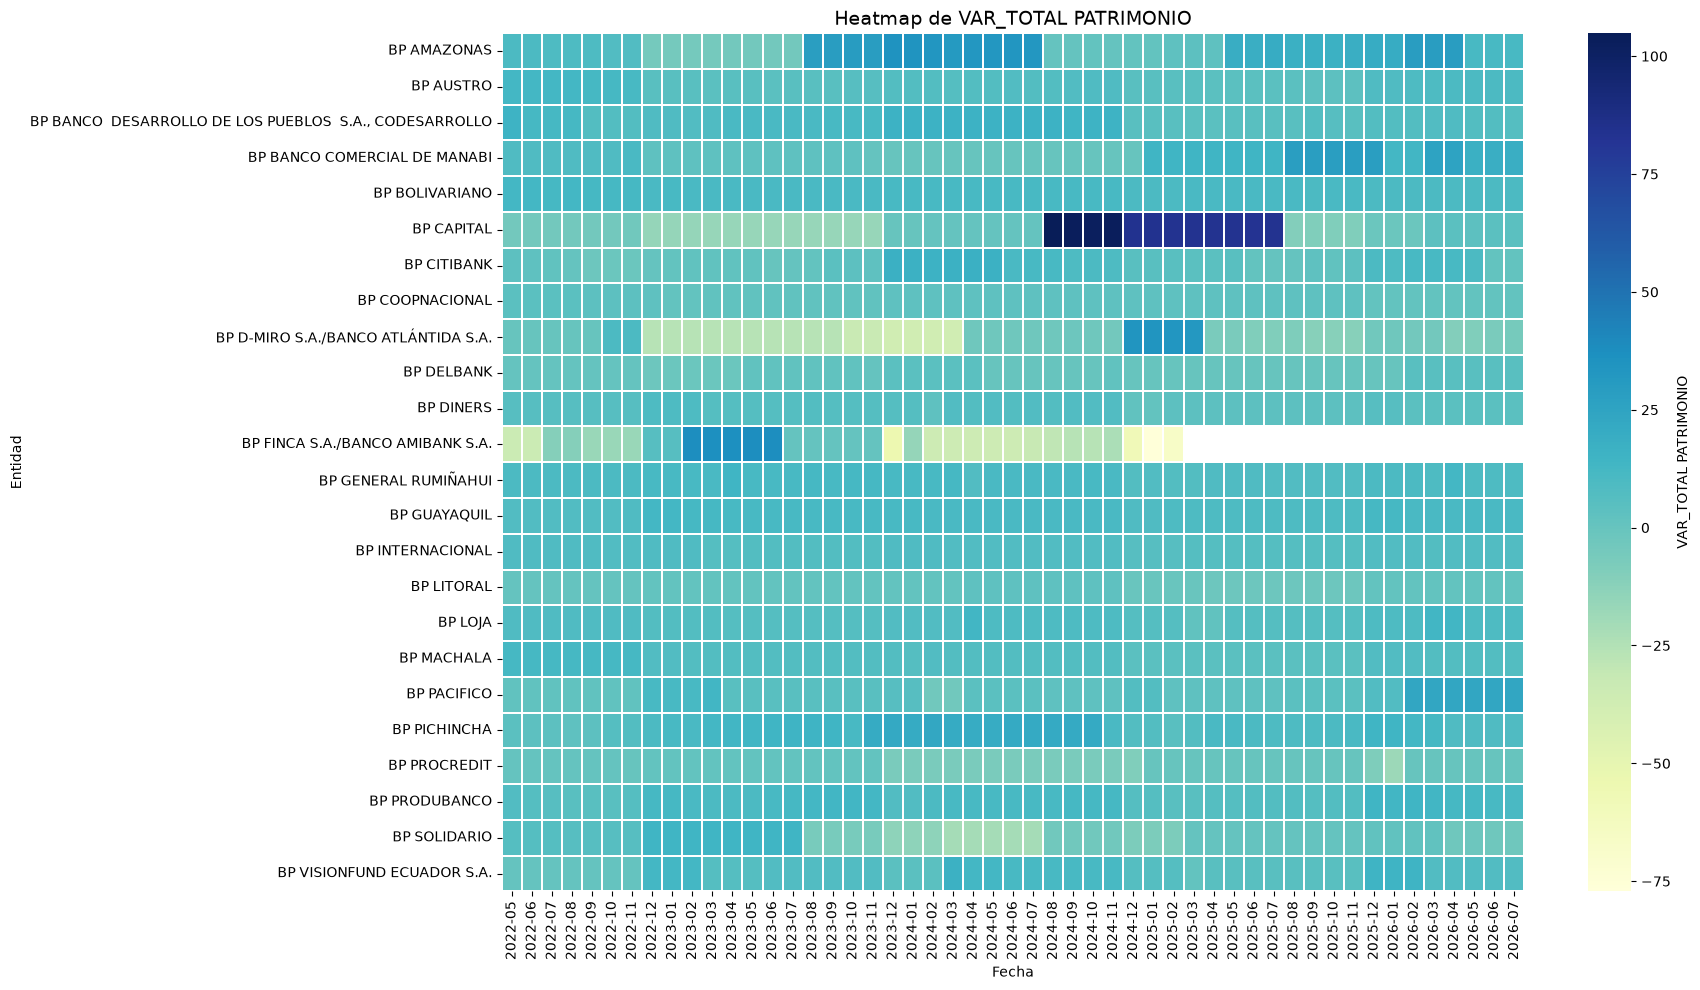

In [82]:
eda.generar_heatmaps(base_final, indicadores_balance, indicadores_notebook=indicadores_notebook, carpeta="graficas_EDA_indicadores_financieros")

Los heatmaps muestran que BP Guayaquil, BP Pichincha, BP Produbanco, BP Internacional, BP Loja y BP Machala presentan patrones relativamente estables, con variaciones de crecimiento moderadas y sin cambios extremos prolongados. En contraste, BP Capital, BP D-MIRO S.A./Banco Atlántida S.A. y BP Banco Comercial de Manabí presentan mayores fluctuaciones, evidenciadas por cambios marcados en la intensidad de los valores a través del tiempo. En el crecimiento de la cartera de créditos destacan BP Capital y BP D-MIRO, que alcanzan períodos superiores al 100%, mientras que en el crecimiento de activos sobresalen BP Banco Comercial de Manabí y BP D-MIRO, con episodios de expansión considerable. Por su parte, el crecimiento patrimonial presenta los cambios más extremos en BP Capital, con valores superiores al 100%, y en BP FINCA S.A./Banco Amibank S.A., que registra períodos de contracción significativa. En conjunto, los heatmaps permiten identificar entidades con trayectorias de crecimiento relativamente estables frente a otras con mayor volatilidad y cambios estructurales, aportando evidencia de la existencia de perfiles financieros diferenciados que posteriormente podrán ser caracterizados mediante las técnicas de reducción dimensional y clustering.

Guardado: graficas_EDA_indicadores_financieros\boxplot_VAR_FONDOS_DISPONIBLES.png
Guardado: graficas_EDA_indicadores_financieros\boxplot_VAR_INVERSIONES.png


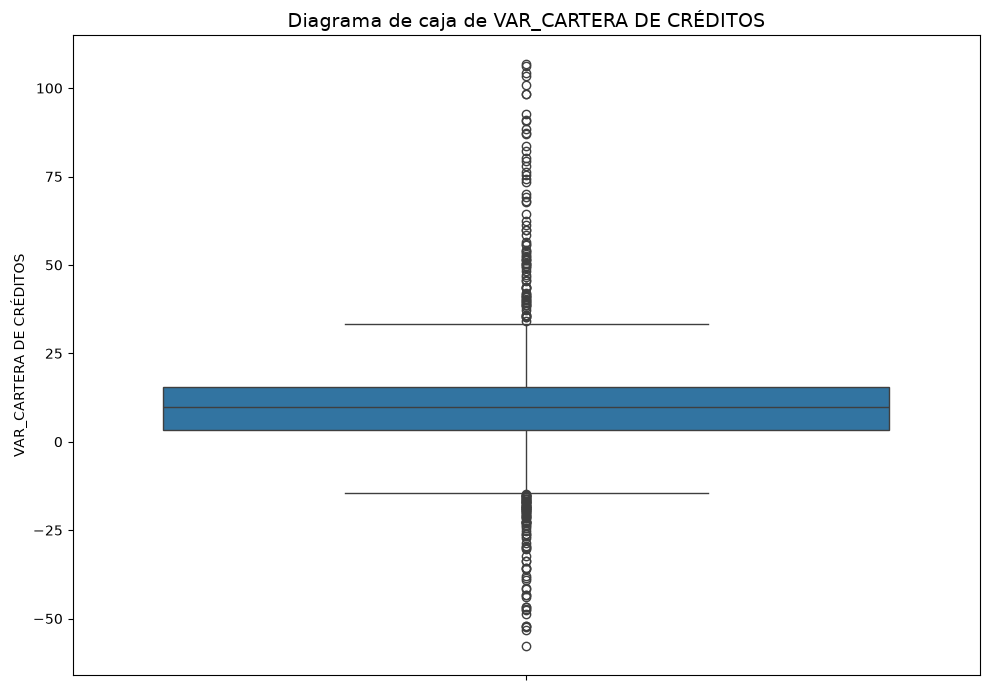

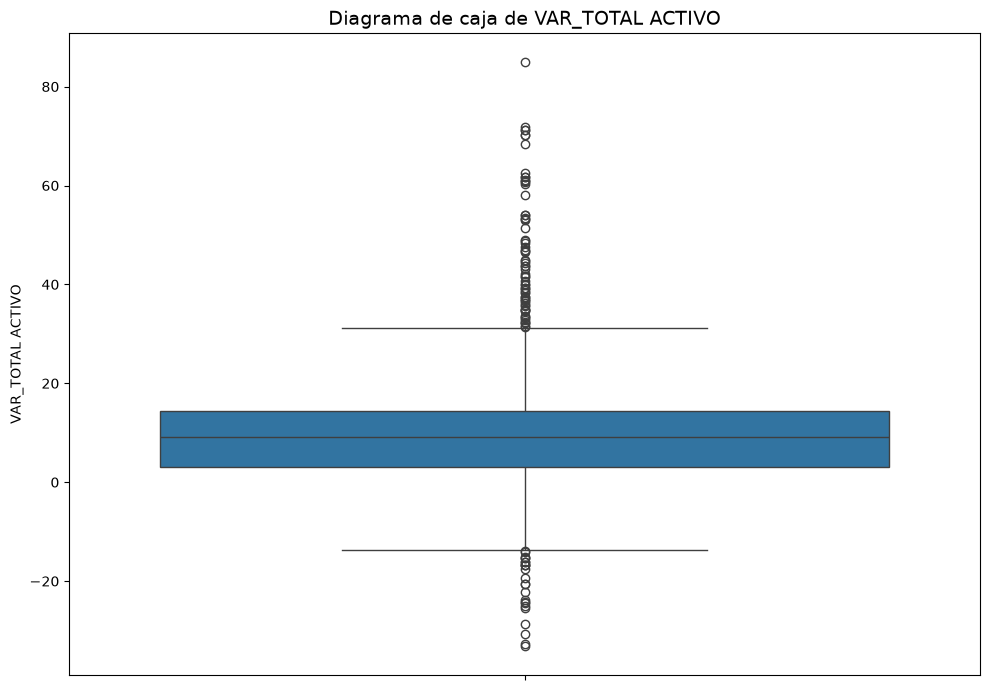

Guardado: graficas_EDA_indicadores_financieros\boxplot_VAR_Depósitos_a_la_vista.png
Guardado: graficas_EDA_indicadores_financieros\boxplot_VAR_Depósitos_a_plazo.png


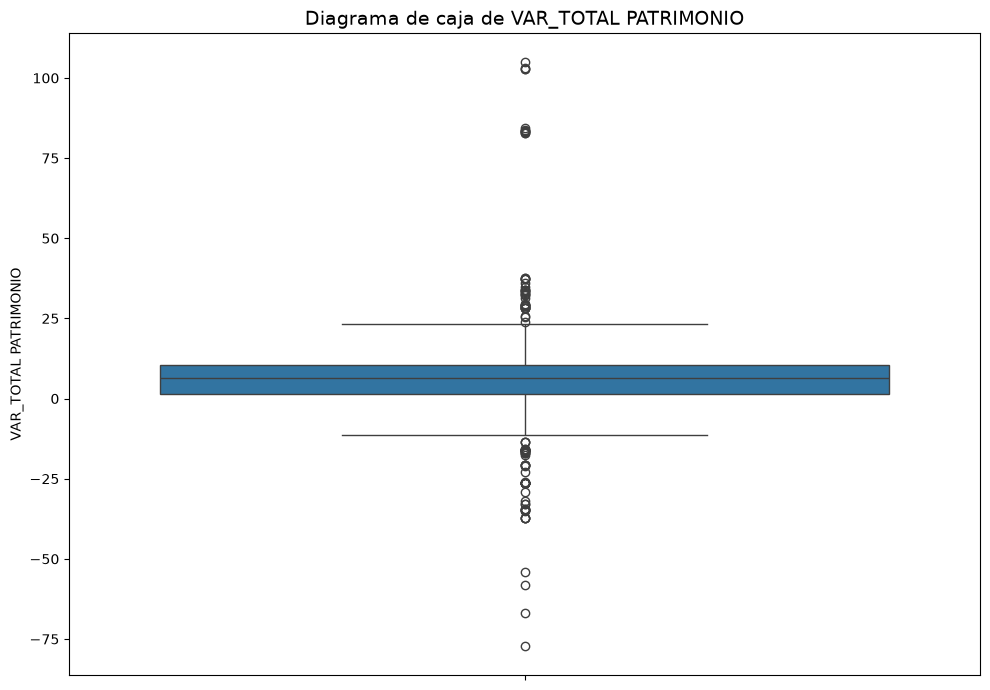

In [83]:
eda.generar_boxplots(base_final, indicadores_balance, indicadores_notebook=indicadores_notebook, carpeta="graficas_EDA_indicadores_financieros")

Los diagramas de caja evidencian una elevada dispersión de las variables de crecimiento interanual y una importante presencia de valores atípicos. En VAR_CARTERA DE CRÉDITOS, se observa una concentración considerable de atípicos por encima del límite superior, con valores que superan el 100%, así como observaciones inferiores a −50%, lo que refleja períodos de expansión y contracción muy pronunciados en determinadas entidades. En VAR_TOTAL ACTIVO, los atípicos superiores alcanzan aproximadamente 85%, mientras que los inferiores llegan alrededor de −33%, evidenciando también episodios de crecimiento y reducción significativos. Finalmente, VAR_TOTAL PATRIMONIO presenta una dispersión particularmente elevada, con valores superiores al 100% y observaciones inferiores a −75%. En conjunto, los resultados muestran que, aunque la mayor parte de las observaciones se concentra en rangos moderados de crecimiento, existen entidades y períodos con comportamientos financieros considerablemente más extremos. Estos valores serán conservados para las etapas posteriores, previa validación de su consistencia, debido a que pueden representar características reales de expansión o contracción y contribuir a la diferenciación de perfiles financieros mediante el PCA y el clustering.

In [84]:
tabla_atipicos = eda.detectar_atipicos_iqr(
    base_final,
    indicadores_balance
)

In [85]:
conteo_atipicos = pd.pivot_table(
    tabla_atipicos,
    index=["ENTIDAD", "INDICADOR"],
    columns="TIPO_ATIPICO",
    values="FECHA",
    aggfunc="count",
    fill_value=0
).reset_index()

# Total de atípicos
conteo_atipicos["TOTAL_ATIPICOS"] = (
    conteo_atipicos.get("Inferior", 0)
    + conteo_atipicos.get("Superior", 0)
)

# Ordenar de mayor a menor
conteo_atipicos = conteo_atipicos.sort_values(
    "TOTAL_ATIPICOS",
    ascending=False
).reset_index(drop=True)


In [90]:
# Número de valores no nulos por entidad e indicador
total_valores = (
    base_final
    .groupby("ENTIDAD")[indicadores_balance]
    .count()
    .reset_index()
    .melt(
        id_vars="ENTIDAD",
        var_name="INDICADOR",
        value_name="TOTAL_VALORES"
    )
)

# Unir con tabla de atípicos
atipicos_f = conteo_atipicos.merge(
    total_valores,
    on=["ENTIDAD", "INDICADOR"],
    how="left"
)

#Porcentaje de valores atípicos problemáticos
atipicos_f["PORC_ATIPICOS"] = (
    atipicos_f["TOTAL_ATIPICOS"]
    / atipicos_f["TOTAL_VALORES"]
    * 100
)

In [91]:
atipicos_f

,ENTIDAD,INDICADOR,Inferior,Superior,TOTAL_ATIPICOS,TOTAL_VALORES,PORC_ATIPICOS
0,BP D-MIRO S.A./BANCO ATLÁNTIDA S.A.,VAR_CARTERA DE CRÉDITOS,25,12,37,51,72.549020
1,BP BANCO COMERCIAL DE MANABI,VAR_Depósitos a plazo,0,36,36,51,70.588235
2,BP CAPITAL,VAR_CARTERA DE CRÉDITOS,6,27,33,51,64.705882
3,BP D-MIRO S.A./BANCO ATLÁNTIDA S.A.,VAR_TOTAL ACTIVO,15,18,33,51,64.705882
4,BP CITIBANK,VAR_Depósitos a plazo,16,13,29,51,56.862745
5,BP DINERS,VAR_Depósitos a la vista,0,26,26,51,50.980392
6,BP BANCO COMERCIAL DE MANABI,VAR_CARTERA DE CRÉDITOS,7,18,25,51,49.019608
7,BP FINCA S.A./BANCO AMIBANK S.A.,VAR_TOTAL PATRIMONIO,20,5,25,34,73.529412
8,BP COOPNACIONAL,VAR_CARTERA DE CRÉDITOS,24,0,24,51,47.058824
9,BP CAPITAL,VAR_TOTAL PATRIMONIO,12,12,24,51,47.058824


In [92]:
atipicos_f = atipicos_f.sort_values(
    "PORC_ATIPICOS",
    ascending=False
)

In [93]:
atipicos_f

,ENTIDAD,INDICADOR,Inferior,Superior,TOTAL_ATIPICOS,TOTAL_VALORES,PORC_ATIPICOS
7,BP FINCA S.A./BANCO AMIBANK S.A.,VAR_TOTAL PATRIMONIO,20,5,25,34,73.529412
0,BP D-MIRO S.A./BANCO ATLÁNTIDA S.A.,VAR_CARTERA DE CRÉDITOS,25,12,37,51,72.549020
1,BP BANCO COMERCIAL DE MANABI,VAR_Depósitos a plazo,0,36,36,51,70.588235
2,BP CAPITAL,VAR_CARTERA DE CRÉDITOS,6,27,33,51,64.705882
3,BP D-MIRO S.A./BANCO ATLÁNTIDA S.A.,VAR_TOTAL ACTIVO,15,18,33,51,64.705882
4,BP CITIBANK,VAR_Depósitos a plazo,16,13,29,51,56.862745
5,BP DINERS,VAR_Depósitos a la vista,0,26,26,51,50.980392
6,BP BANCO COMERCIAL DE MANABI,VAR_CARTERA DE CRÉDITOS,7,18,25,51,49.019608
8,BP COOPNACIONAL,VAR_CARTERA DE CRÉDITOS,24,0,24,51,47.058824
9,BP CAPITAL,VAR_TOTAL PATRIMONIO,12,12,24,51,47.058824


La detección de valores atípicos mediante el criterio de $1,5\times IQR$ evidencia que las observaciones extremas no se distribuyen de manera homogénea entre las entidades. Los mayores niveles de atipicidad se concentran en instituciones que presentan cambios estructurales o dinámicas de crecimiento diferenciadas. Por ejemplo, Banco Amibank registra una elevada frecuencia de atípicos inferiores en el crecimiento patrimonial, comportamiento consistente con la reducción de su patrimonio y el posterior proceso de liquidación. D-MIRO S.A./Banco Atlántida presenta numerosos atípicos tanto superiores como inferiores en cartera, activos, depósitos y patrimonio, coherentes con la fuerte reducción de cartera registrada en 2024 y la posterior transformación y expansión de la entidad. Por su parte, Banco Capital y Banco Comercial de Manabí presentan una concentración importante de atípicos superiores asociada con períodos de expansión de activos, cartera y captaciones. En entidades como Diners y Citibank, los valores atípicos deben interpretarse considerando su estructura particular de negocio y de fondeo, ya que tasas de crecimiento elevadas pueden estar asociadas a variaciones sobre bases relativamente pequeñas. En consecuencia, los resultados obtenidos presentan coherencia con las trayectorias observadas en el análisis temporal y los heatmaps, por lo que los valores atípicos identificados no serán eliminados automáticamente. Serán considerados observaciones potencialmente informativas sobre cambios estructurales y perfiles diferenciados de las entidades, previa validación de su consistencia con las fuentes originales.

## Análisis de Correlación

In [94]:
base_final.columns.to_list

<bound method IndexOpsMixin.tolist of Index(['MES', 'AÑO', 'ENTIDAD', 'SUFICIENCIA PATRIMONIAL',
       'INDICE DE CAPITALIZACION NETO: FK / FI',
       'ACTIVOS IMPRODUCTIVOS NETOS / TOTAL ACTIVOS',
       'ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS',
       'ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO',
       'MOROSIDAD DE LA CARTERA TOTAL', 'COBERTURA DE LA CARTERA REFINANCIADA',
       'COBERTURA DE LA CARTERA REESTRUCTURADA',
       'COBERTURA DE LA CARTERA PROBLEMÁTICA',
       'GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO PROMEDIO (3)',
       'GASTOS DE OPERACION  / MARGEN FINANCIERO',
       'GASTOS DE PERSONAL ESTIMADOS / ACTIVO PROMEDIO (3)',
       'RESULTADOS DEL EJERCICIO / PATRIMONIO PROMEDIO',
       'RESULTADOS DEL EJERCICIO / ACTIVO PROMEDIO',
       'CARTERA BRUTA / (DEPOSITOS A LA VISTA + DEPOSITOS A PLAZO)',
       'FONDOS DISPONIBLES / TOTAL DEPOSITOS A CORTO PLAZO',
       'CARTERA IMPRODUCTIVA / CARTERA BRUTA',
       'CARTERA VENCIDA / CARTERA BRUTA',
       'CARTERA QUE

In [95]:
columnas_excluir = [
    "MES",
    "AÑO",
    "ENTIDAD",
    "MES_NUM",
    "FECHA"
]

variables_correlacion = [
    col for col in base_final.columns
    if col not in columnas_excluir
]

df_corr = base_final[variables_correlacion]

print(f"Número de variables: {len(variables_correlacion)}")
print(variables_correlacion)

Número de variables: 28
['SUFICIENCIA PATRIMONIAL', 'INDICE DE CAPITALIZACION NETO: FK / FI', 'ACTIVOS IMPRODUCTIVOS NETOS / TOTAL ACTIVOS', 'ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS', 'ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO', 'MOROSIDAD DE LA CARTERA TOTAL', 'COBERTURA DE LA CARTERA REFINANCIADA', 'COBERTURA DE LA CARTERA REESTRUCTURADA', 'COBERTURA DE LA CARTERA PROBLEMÁTICA', 'GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO PROMEDIO (3)', 'GASTOS DE OPERACION  / MARGEN FINANCIERO', 'GASTOS DE PERSONAL ESTIMADOS / ACTIVO PROMEDIO (3)', 'RESULTADOS DEL EJERCICIO / PATRIMONIO PROMEDIO', 'RESULTADOS DEL EJERCICIO / ACTIVO PROMEDIO', 'CARTERA BRUTA / (DEPOSITOS A LA VISTA + DEPOSITOS A PLAZO)', 'FONDOS DISPONIBLES / TOTAL DEPOSITOS A CORTO PLAZO', 'CARTERA IMPRODUCTIVA / CARTERA BRUTA', 'CARTERA VENCIDA / CARTERA BRUTA', 'CARTERA QUE NO DEVENGA INTERESES / CARTERA BRUTA', 'CARTERA REFINANCIADA / CARTERA BRUTA', 'CARTERA REESTRUCTURADA / CARTERA BRUTA', 'VAR_FONDOS DISPONIBLES', 'VAR_INVERSIONES

In [96]:
corr = df_corr.corr(method="pearson")

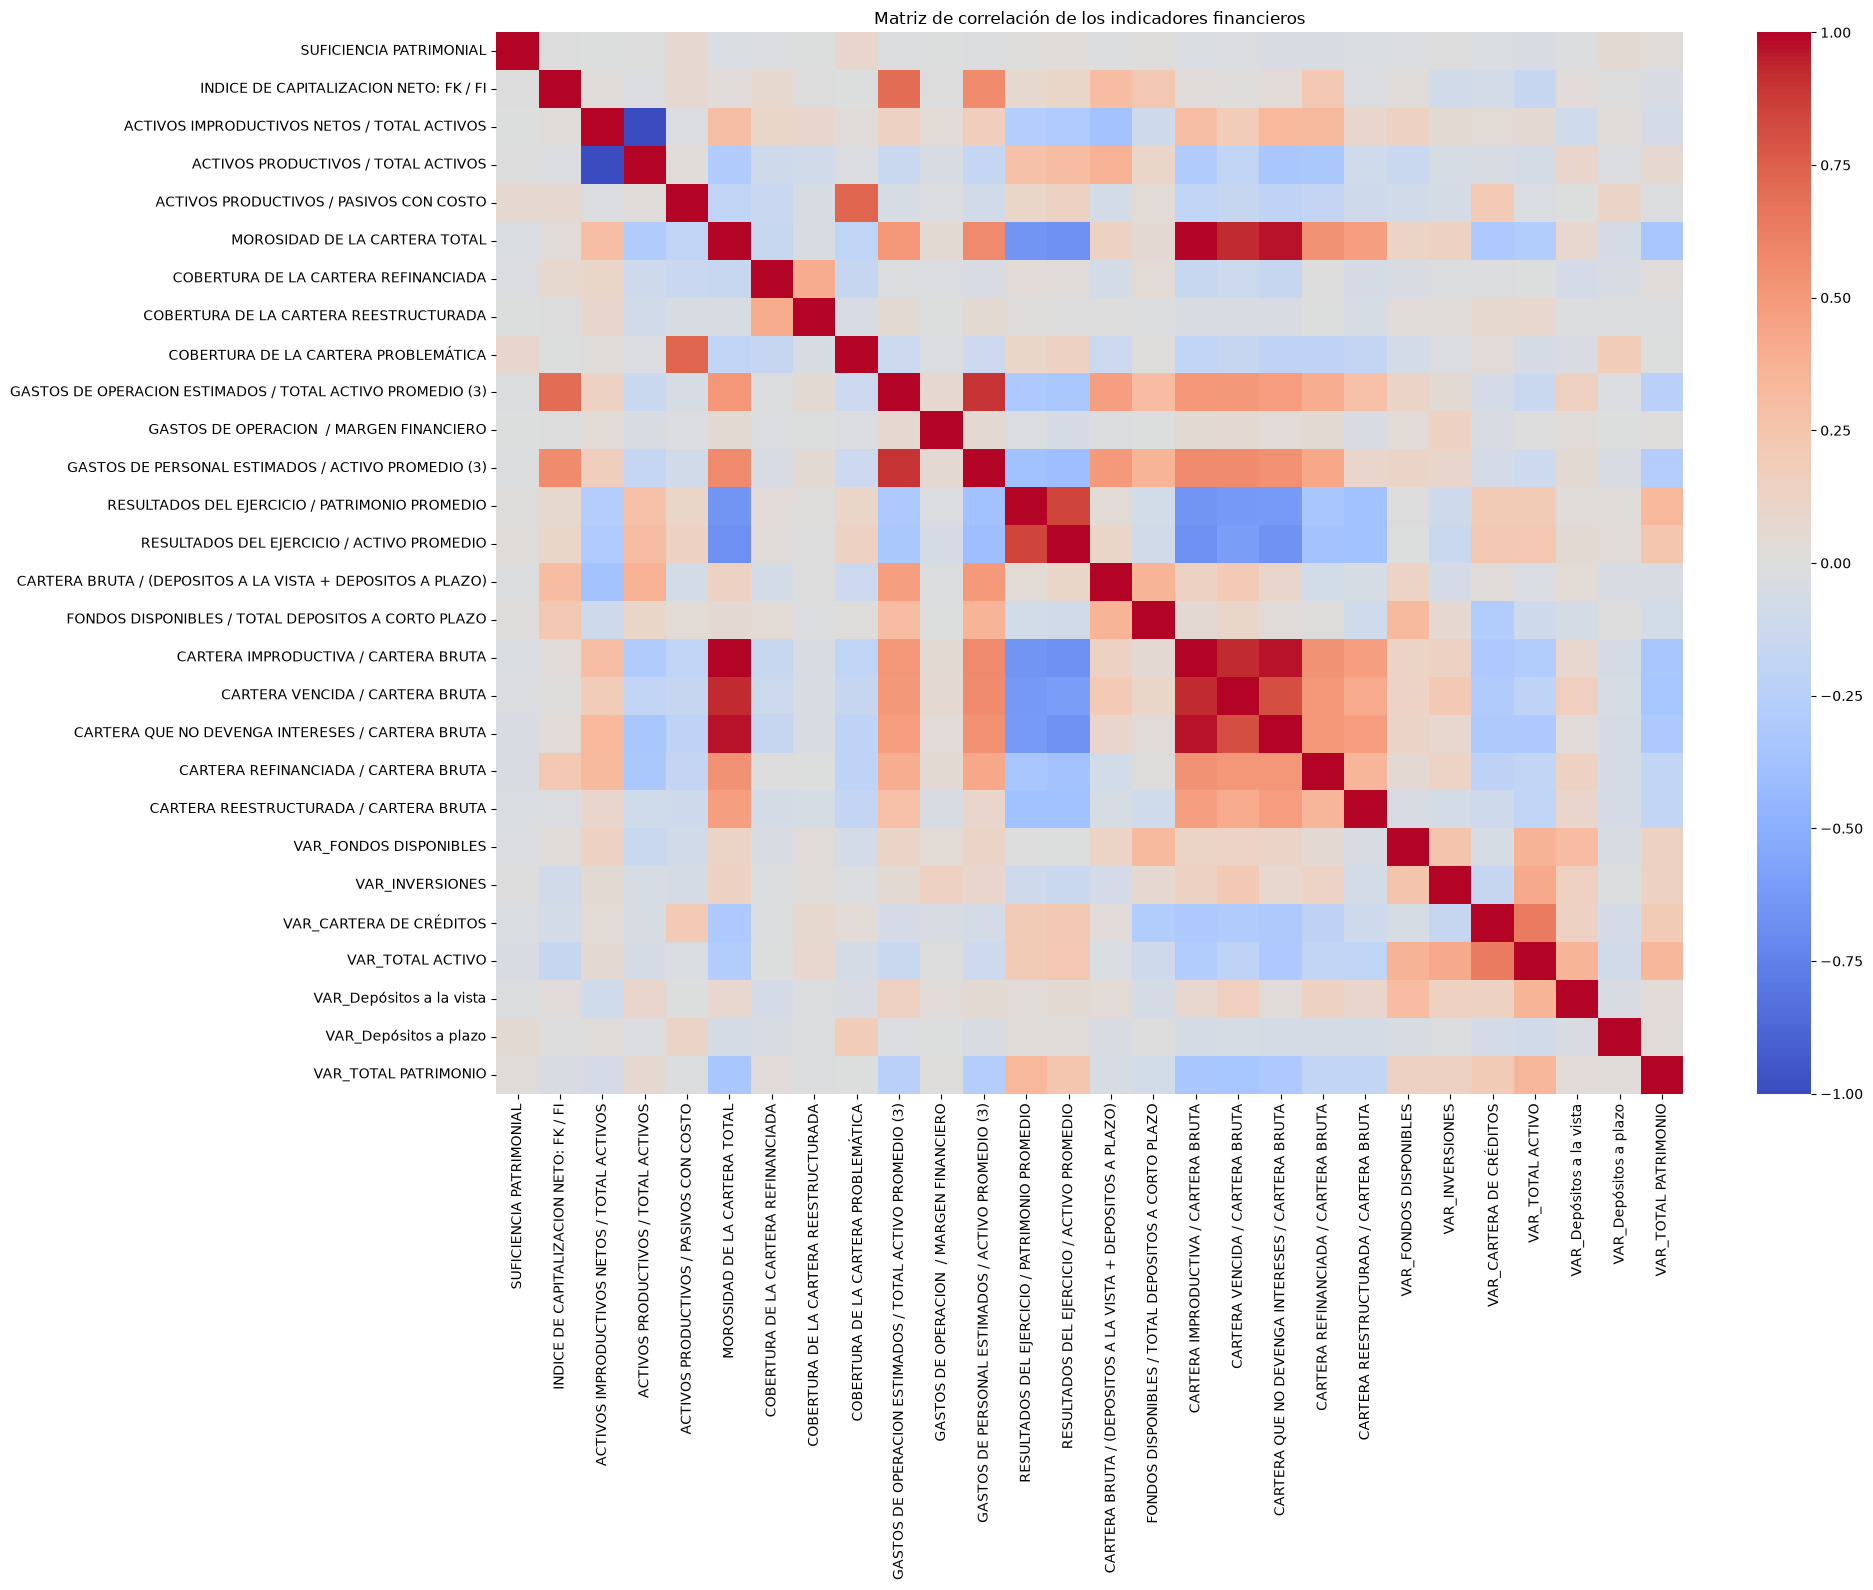

In [ ]:
plt.figure(figsize=(20, 16))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Matriz de correlación de los indicadores financieros")
plt.tight_layout()
plt.show()

In [98]:
# Tomar solo el triángulo superior
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

correlaciones = (
    corr.where(mask)
        .stack()
        .reset_index()
)

correlaciones.columns = ["VARIABLE_1", "VARIABLE_2", "CORRELACION"]

correlaciones["ABS_CORRELACION"] = (
    correlaciones["CORRELACION"].abs()
)

correlaciones = correlaciones.sort_values(
    "ABS_CORRELACION",
    ascending=False
)

correlaciones.head(20)

,VARIABLE_1,VARIABLE_2,CORRELACION,ABS_CORRELACION
156,MOROSIDAD DE LA CARTERA TOTAL,CARTERA IMPRODUCTIVA / CARTERA BRUTA,1.000000,1.000000
59,ACTIVOS IMPRODUCTIVOS NETOS / TOTAL ACTIVOS,ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS,-1.000000,1.000000
158,MOROSIDAD DE LA CARTERA TOTAL,CARTERA QUE NO DEVENGA INTERESES / CARTERA BRUTA,0.973171,0.973171
466,CARTERA IMPRODUCTIVA / CARTERA BRUTA,CARTERA QUE NO DEVENGA INTERESES / CARTERA BRUTA,0.973171,0.973171
465,CARTERA IMPRODUCTIVA / CARTERA BRUTA,CARTERA VENCIDA / CARTERA BRUTA,0.926678,0.926678
157,MOROSIDAD DE LA CARTERA TOTAL,CARTERA VENCIDA / CARTERA BRUTA,0.926678,0.926678
263,GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO P...,GASTOS DE PERSONAL ESTIMADOS / ACTIVO PROMEDIO...,0.902117,0.902117
349,RESULTADOS DEL EJERCICIO / PATRIMONIO PROMEDIO,RESULTADOS DEL EJERCICIO / ACTIVO PROMEDIO,0.844466,0.844466
494,CARTERA VENCIDA / CARTERA BRUTA,CARTERA QUE NO DEVENGA INTERESES / CARTERA BRUTA,0.815339,0.815339
120,ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO,COBERTURA DE LA CARTERA PROBLEMÁTICA,0.730123,0.730123


Se identificó una correlación perfecta $r=1,00$ entre MOROSIDAD DE LA CARTERA TOTAL y CARTERA IMPRODUCTIVA / CARTERA BRUTA. La revisión de la definición del indicador permitió determinar que ambas variables utilizan la misma expresión: cartera improductiva como numerador y cartera bruta como denominador, y aunque la morosidad mide q qué proporción de la cartera total presenta problemas de pago considerados como morosos, la segunda relación implica determinar la proporción de la cartera los créditos que ya no está generando normalmente ingresos financieros por intereses debido a su situación de deterioro o incumplimiento sobre el saldo de los créditos colocados por la entidad antes de descontar las provisiones para créditos incobrables, lo que significa la proporción de la cartera que tiene problemas de pago.
Por tanto, ambos indicadores representan el mismo concepto financiero y contienen información redundante. En consecuencia, se decidió excluir CARTERA IMPRODUCTIVA / CARTERA BRUTA del conjunto de variables que será utilizado en el análisis de reducción de dimensionalidad, conservando MOROSIDAD DE LA CARTERA TOTAL como indicador representativo de este fenómeno.


In [99]:
base_final = base_final.drop(columns=["CARTERA IMPRODUCTIVA / CARTERA BRUTA"])

Se identificó una correlación negativa perfecta $r=-1,00$ entre ACTIVOS IMPRODUCTIVOS NETOS / TOTAL ACTIVOS y ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS. Esta relación resulta razonable tanto desde el punto de vista matemático como financiero, debido a que ambos indicadores utilizan como denominador el total de activos y representan componentes complementarios de la estructura de activos de la entidad. 
Activos productivos / Total activos mide qué proporción de los activos de la entidad corresponde a activos productivos, es decir, activos que contribuyen a generar ingresos financieros.
Mientras que Activos improductivos netos / Total activos mide qué proporción de los activos corresponde a activos improductivos netos, es decir, aquellos activos que no generan el rendimiento financiero esperado, considerando el efecto de las provisiones correspondientes.

En consecuencia, cuando aumenta la proporción de activos productivos respecto del total de activos, disminuye proporcionalmente la participación de los activos improductivos netos, y viceversa. Por tanto, la correlación negativa perfecta indica que ambas variables contienen información esencialmente complementaria y redundante para el análisis multivariado. En consecuencia, se decidió excluir ACTIVOS IMPRODUCTIVOS NETOS / TOTAL ACTIVOS y conservar ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS, evitando incorporar dos variables que representan la misma dimensión de la estructura de activos con relación inversa perfecta.

In [100]:
base_final = base_final.drop(columns=["ACTIVOS IMPRODUCTIVOS NETOS / TOTAL ACTIVOS"])

Adicionalmente, se identificaron correlaciones elevadas entre la MOROSIDAD DE LA CARTERA TOTAL y los indicadores derivados de la composición de la cartera. En particular, se obtuvo una correlación de $r=0,973$ entre la morosidad de la cartera total y la proporción de CARTERA QUE NO DEVENGA INTERESES / CARTERA BRUTA, mientras que la relación con CARTERA VENCIDA / CARTERA BRUTA presentó una correlación de $r=0,927$. Asimismo, los indicadores derivados de cartera improductiva presentaron correlaciones de $r=0,973$ y $r=0,927$ con las proporciones de cartera que no devenga intereses y cartera vencida, respectivamente. 

Además, ya se había identificado que $$ \text{Cartera improductiva} = \text{Cartera vencida} + \text{Cartera que no devenga intereses} $$, y que la morosidad de cartera total está construida precisamente sobre la cartera improductiva respecto de la cartera bruta. Por eso, CARTERA IMPRODUCTIVA / CARTERA BRUTA es esencialmente la misma información que MOROSIDAD DE LA CARTERA TOTAL

Estas relaciones evidencian una elevada redundancia informativa entre las variables, debido a que la cartera improductiva está conformada por la cartera vencida y la cartera que no devenga intereses. Considerando además que la MOROSIDAD DE LA CARTERA TOTAL constituye el indicador oficial publicado por la Superintendencia de Bancos para representar el deterioro de la cartera total, se decidió conservar esta variable y excluir  CARTERA QUE NO DEVENGA INTERESES / CARTERA BRUTA y CARTERA VENCIDA / CARTERA BRUTA, con el propósito de reducir la redundancia entre variables antes de aplicar las técnicas de reducción de dimensionalidad.

In [102]:
a_eliminar=['CARTERA VENCIDA / CARTERA BRUTA',
       'CARTERA QUE NO DEVENGA INTERESES / CARTERA BRUTA']


base_final = base_final.drop(columns=a_eliminar)

En el análisis de correlaciones se identificaron dos relaciones elevadas que, pese a superar el umbral de \(r>0,90\) en el primer caso, no fueron consideradas suficientes para eliminar las variables involucradas. En primer lugar, GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO PROMEDIO y GASTOS DE PERSONAL ESTIMADOS / ACTIVO PROMEDIO presentaron una correlación de \(r=0,902\). Aunque esta relación es elevada y resulta coherente con que los gastos de personal constituyen un componente de los gastos de operación, ambos indicadores representan dimensiones diferentes de la eficiencia: el primero refleja la carga operativa global de la entidad, mientras que el segundo permite identificar específicamente el peso de los gastos de personal. Por ello, se conservaron ambas variables al considerar que aportan información complementaria.

En segundo lugar, los indicadores RESULTADOS DEL EJERCICIO / PATRIMONIO PROMEDIO (ROE) y RESULTADOS DEL EJERCICIO / ACTIVO PROMEDIO (ROA) presentaron una correlación de \(r=0,844\). Esta relación es consistente con el hecho de que ambos indicadores comparten el resultado del ejercicio como numerador y miden distintas perspectivas de la rentabilidad. Sin embargo, sus denominadores son diferentes: el ROE relaciona el resultado con el patrimonio, mientras que el ROA lo relaciona con los activos. En consecuencia, ambos indicadores pueden aportar información diferenciada sobre el desempeño financiero y la estructura de las entidades, por lo que no se consideraron variables redundantes y se mantuvieron para las etapas posteriores del análisis multivariado.

In [103]:
columnas_excluir = [
    "MES",
    "AÑO",
    "ENTIDAD",
    "MES_NUM",
    "FECHA"
]

variables_correlacion = [
    col for col in base_final.columns
    if col not in columnas_excluir
]

df_corr = base_final[variables_correlacion]

print(f"Número de variables: {len(variables_correlacion)}")
print(variables_correlacion)

Número de variables: 24
['SUFICIENCIA PATRIMONIAL', 'INDICE DE CAPITALIZACION NETO: FK / FI', 'ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS', 'ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO', 'MOROSIDAD DE LA CARTERA TOTAL', 'COBERTURA DE LA CARTERA REFINANCIADA', 'COBERTURA DE LA CARTERA REESTRUCTURADA', 'COBERTURA DE LA CARTERA PROBLEMÁTICA', 'GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO PROMEDIO (3)', 'GASTOS DE OPERACION  / MARGEN FINANCIERO', 'GASTOS DE PERSONAL ESTIMADOS / ACTIVO PROMEDIO (3)', 'RESULTADOS DEL EJERCICIO / PATRIMONIO PROMEDIO', 'RESULTADOS DEL EJERCICIO / ACTIVO PROMEDIO', 'CARTERA BRUTA / (DEPOSITOS A LA VISTA + DEPOSITOS A PLAZO)', 'FONDOS DISPONIBLES / TOTAL DEPOSITOS A CORTO PLAZO', 'CARTERA REFINANCIADA / CARTERA BRUTA', 'CARTERA REESTRUCTURADA / CARTERA BRUTA', 'VAR_FONDOS DISPONIBLES', 'VAR_INVERSIONES', 'VAR_CARTERA DE CRÉDITOS', 'VAR_TOTAL ACTIVO', 'VAR_Depósitos a la vista', 'VAR_Depósitos a plazo', 'VAR_TOTAL PATRIMONIO']


In [105]:
corr = df_corr.corr(method="pearson")

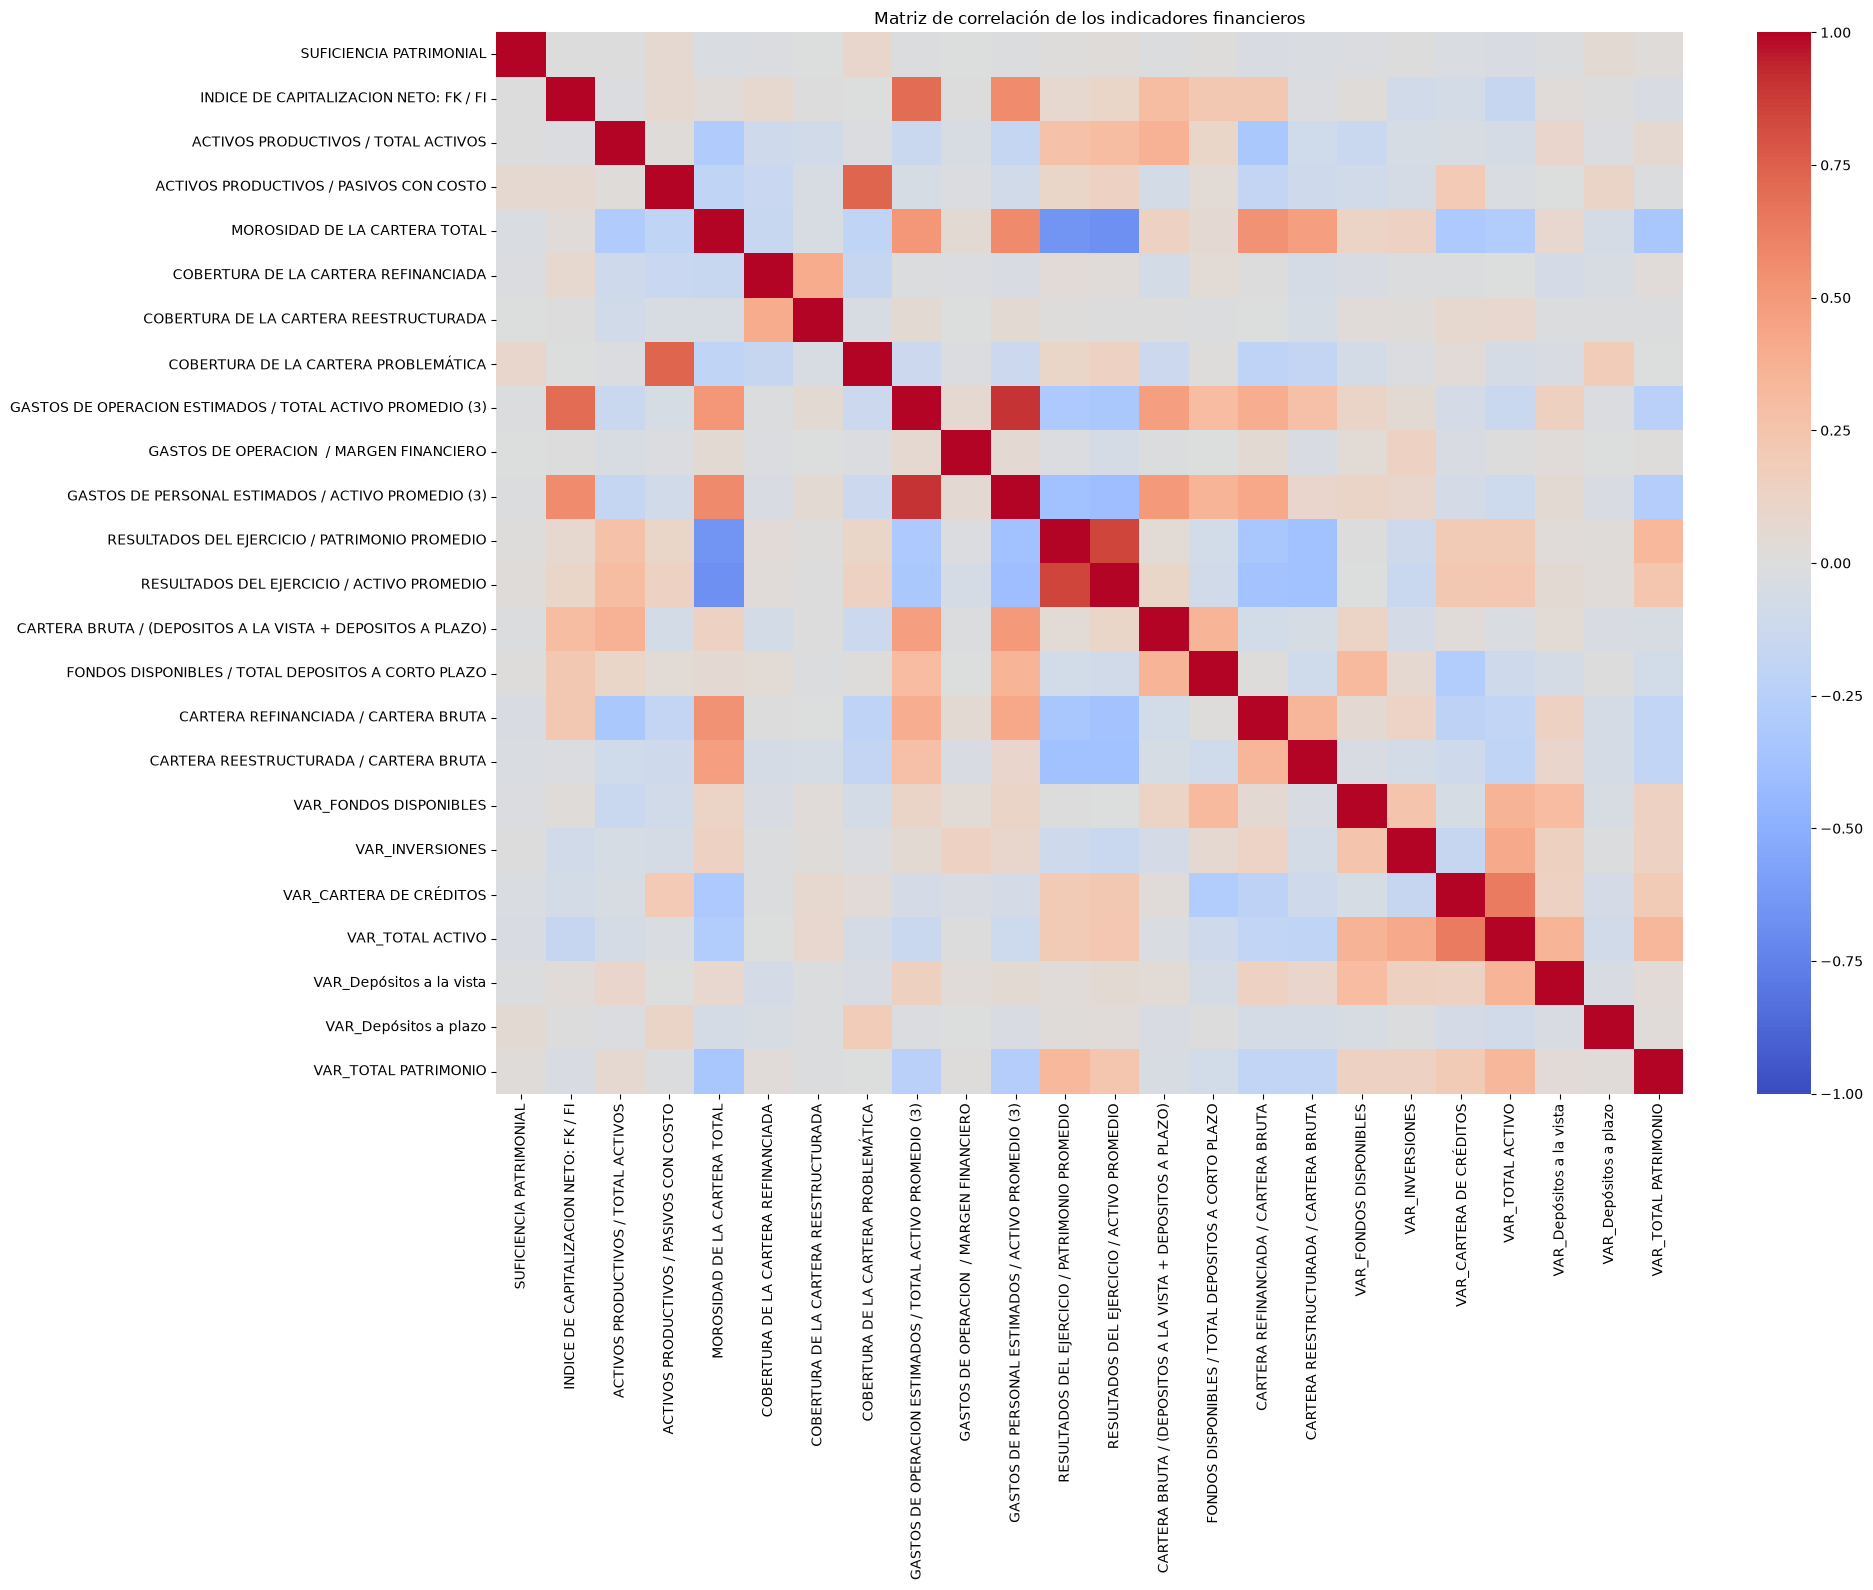

In [106]:
plt.figure(figsize=(20, 16))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Matriz de correlación de los indicadores financieros")
plt.tight_layout()
plt.show()

In [109]:
base_final.to_excel("../data_processed/base_pca.xlsx",index=False)